## Setup                                                                              

In [1]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
#import ipyparallel as ipp
import datetime

# scientific stack
import numpy as np
#import jax.numpy as jnp
import scipy
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import curve_fit
import pandas as pd

# cosmology
#import astropy
#import astropy.units as units
#from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
#import classy
#from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ
import warnings
#warnings.filterwarnings('ignore')
#import jax; jax.config.update('jax_platform_name', 'cpu')
#import desilike
#from desilike.theories.galaxy_clustering import StandardPowerSpectrumTemplate
#from desilike.likelihoods.base import BaseLikelihood
#from desilike.likelihoods.base import BaseGaussianLikelihood
#from desilike.likelihoods.base import ObservablesGaussianLikelihood
#from desilike.fisher import Fisher

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, HTML
#from tabulate import tabulate

# inference / sampling
#import cobaya
#from cobaya.run import run as cobaya_run
#from cobaya.likelihood import Likelihood
#from cobaya.model import get_model
#from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

import logging
import warnings

# Suppress Matplotlib font warning logs
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Or suppress warnings generally
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

In [2]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import project_fisher_matrix
from functions_and_classes import get_partial_derivative
from functions_and_classes import sample_fisher_with_uniform_priors
from functions_and_classes import plot_Fisher_from_matrices

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [3]:
# cosmologies and priors -- all values from DESI DR2 Chains, DESI+CMB or, if available, DESI+CMB+DESY5

# flat LCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04807
Omega_c = 0.2532
Omega_k = 0
w0 = -1
wa = 0
h = 0.6817
n_s = 0.9693
A_s = 2.122e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved LCDM
Omega_b = 0.04735
Omega_c = 0.2547
Omega_k = 0.00231
w0 = -1
wa = 0
h = 0.6850
n_s = 0.9649
A_s = 2.115e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat wCDM
Omega_b = 0.04929
Omega_c = 0.2591
Omega_k = 0
w0 = -0.9706
wa = 0
h = 0.6734
n_s = 0.9699
A_s = 2.127e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_wCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})


# flat w0wa
Omega_b = 0.04991
Omega_c = 0.2676
Omega_k = 0
w0 = -0.7521
wa = -0.8611
h = 0.6674
n_s = 0.9654
A_s = 2.094e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved w0wa
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# define prior
# all priors taken from Planck unless otherwise stated (https://arxiv.org/pdf/1303.5076)
uniform_prior = {
    'Omega_c': (0.1, 0.9), # not Planck prior given, prior self chosen
    'wa': (-3, 3),         # wider than Planck prior by 1 in each direction
    'w0': (-3, -0.3),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3),
    'm_nu': (0, 5)
}

## Data and Noise

In [ ]:
# DESI DES sky overlap: https://watermark02.silverchair.com/stad2221.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA1UwggNRBgkqhkiG9w0BBwagggNCMIIDPgIBADCCAzcGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMPF_1Rf3PlLw4g5VBAgEQgIIDCIlykzq-IzVjb7Q-kkK-E_5umppOPSrMHOM4UcfgCovcPTCkOTtlNtDEuRTFA8zh7iBGNGsDnd-8gGRpt2fMeYXMDfYdJol0EmAVU0jzC3QS09cUU7bsCWObaMC30q1RllRRoW2tDw7GSidmi6o3q16CC17S3E0jNNYCsN4V1_glxcQLPsOMlNPPvndES-6O6fcMLjmBkTVj5Lqxhp46NfXfdxchfyI0u2lk7KpnQr8MQ7TNZszs8sIL9ksFU-OatEjM9dTdQYZeatWHf8i2By5iBsjDC3kcJgunHdU486xBXXUNLxwte63Ri_ZH5L0Nc5wNxgVP4PueqeUZiVIE_Ws-V_QlzbzWRH5vQ_AczOlvpZCSBNyPdxQ0i0aSXEssjBTePJbpJ744tQgyw9rPheWDeEC-RzSx9thKoGpWl_39VNZkGlcO5WEA-u8S_dzA9B7b55qQnwpHHNX8NS_7zU8s17pbPJfnz7CoTVteiRR9kDfR3IthFsL92-mHtdzDb810c8T3JImSFRGEiUDaMNWjqgcIPWT38wjMZiR_p95oQ897WCLJmD88Ychm-PjGxtNSNU70f9495aOJ4ObOUvEi8gn_ZS6yosWd1bxdHkqgn1KTXY4dii7IuKHmnffcLiAVOytkEe0RuOdLmSsaKfX8HshbaKKrpsmXPcWar3anMykqxkPKvqQxCUVo9wDJq3SDd6evAfr0nBGBZo1bHepZ43VTJzi-2KLhHG2teDw_8yFLOU0lHDgJEYoTfpDvtLHhAklEUd5V4XmjIwN4KcDNt2CJoun9y_zmH-8pdP4Oc5h_XYcTBuvNa7lKYbh2js_SMwANW1cjrv2LeS7eqoLljb1XqsrgxowX61urarvsn2NX-xy2ctqiH0Wjvl3IS88_zzJ_kEdd46dztq6PXNWdpWeImvc_PD2G46eUMQUhOa69a2v1kL_BpCl4WUBQRifU7x3O7SSTyfyOIislu2aDkc-xnAwvdBYL2SFR2kKsXQHC5eELAUm5iVu1_ui6JBTtjeGDj7Jv

In [5]:
# BGS data

# 1. Define redshift array
z = np.linspace(0.0, 0.6, 600)

# Gaussian function
def gaussian_nz(z, mu, sigma):
  return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
      -0.5 * ((z - mu) / sigma) ** 2
  )


# 2. Compute the 1D n(z) distributions
z_eff_1, sigma_1 = 0.211, 0.06
z_eff_2, sigma_2 = 0.352, 0.05

nz_bgs1 = gaussian_nz(z, z_eff_1, sigma_1)
nz_bgs2 = gaussian_nz(z, z_eff_2, sigma_2)

# 3. Stack into 2-column arrays (Column 0: redshift z, Column 1: dN/dz)
bgs1_array = np.column_stack((z, nz_bgs1))
bgs2_array = np.column_stack((z, nz_bgs2))

# Check shapes (should be (600, 2))
print("BGS 1 array shape:", bgs1_array.shape)
print("BGS 2 array shape:", bgs2_array.shape)

import numpy as np

# Stack z, nz_bgs1, and nz_bgs2 as columns
bgs_combined_array = np.column_stack((z, nz_bgs1, nz_bgs2))

# Verify shape (should print (600, 3))
print("Combined array shape:", bgs_combined_array.shape)

BGS 1 array shape: (600, 2)
BGS 2 array shape: (600, 2)
Combined array shape: (600, 3)


In [6]:
# HSC and DES source data

# HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DES Source Data

DES_source_data = np.loadtxt("data/des_nz_gamma.txt")

DES_source_data = DES_source_data[7:]  # removes the first 7 values (headers)
DES_source_data = DES_source_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DES_source_z    = DES_source_data[:, 0]
DES_source_nz_a = DES_source_data[:, 1]
DES_source_nz_b = DES_source_data[:, 2]
DES_source_nz_c = DES_source_data[:, 3]
DES_source_nz_d = DES_source_data[:, 4]
#DES_source_nz_e = DES_source_data[:, 5]

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a, DES_source_nz_b, DES_source_nz_c, DES_source_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

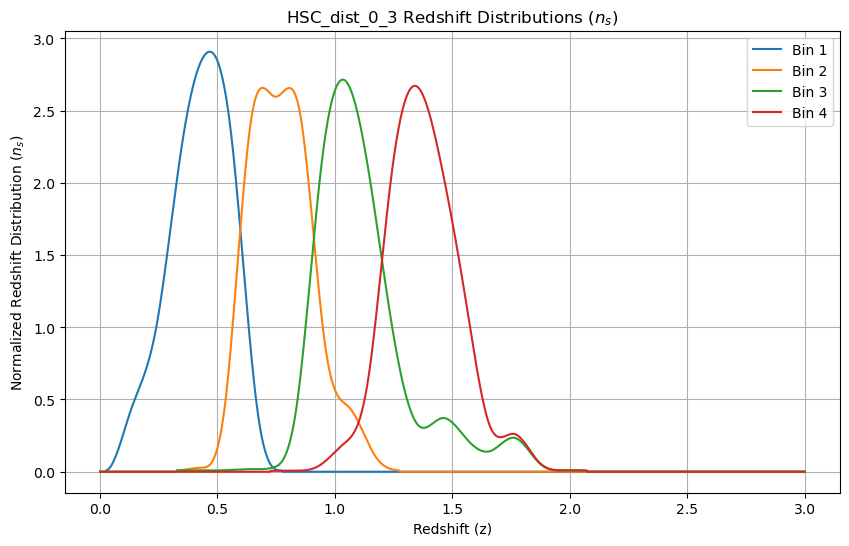

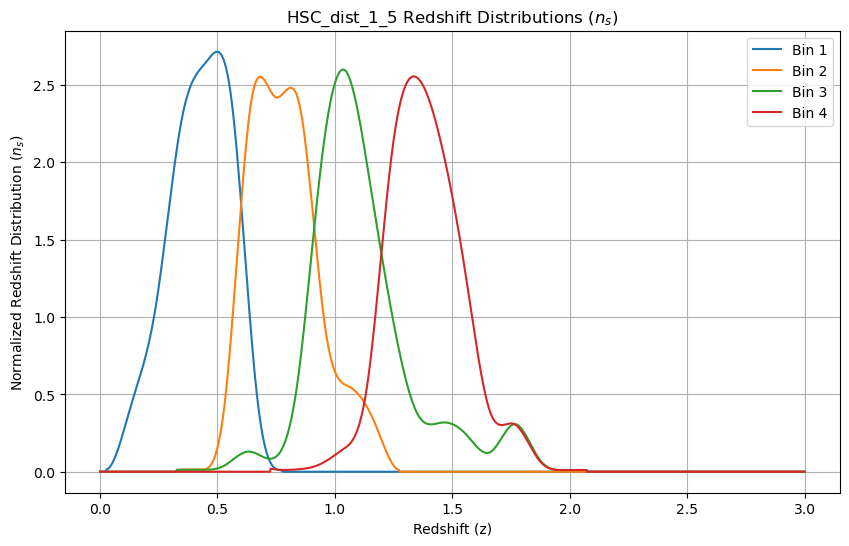

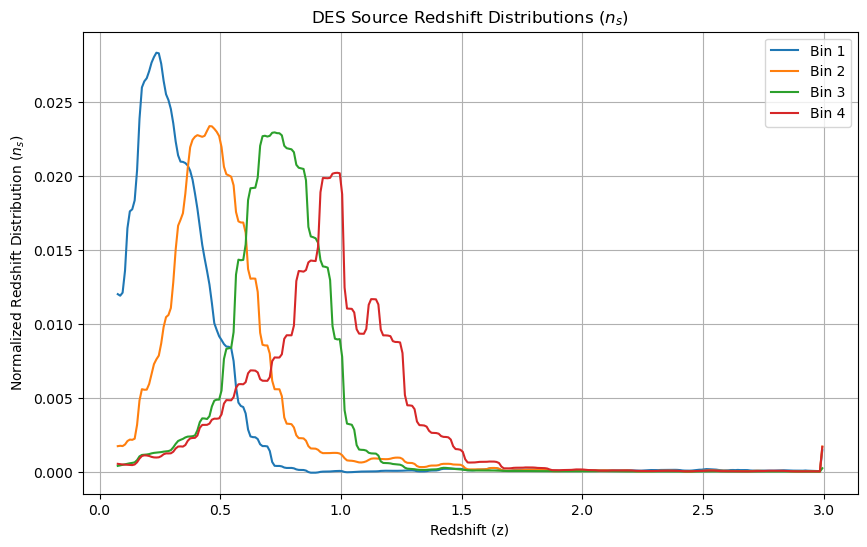

In [7]:
# graph HSC and DES source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DES_source_z, DES_source_nz_a, label='Bin 1')
plt.plot(DES_source_z, DES_source_nz_b, label='Bin 2')
plt.plot(DES_source_z, DES_source_nz_c, label='Bin 3')
plt.plot(DES_source_z, DES_source_nz_d, label='Bin 4')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DES Source Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

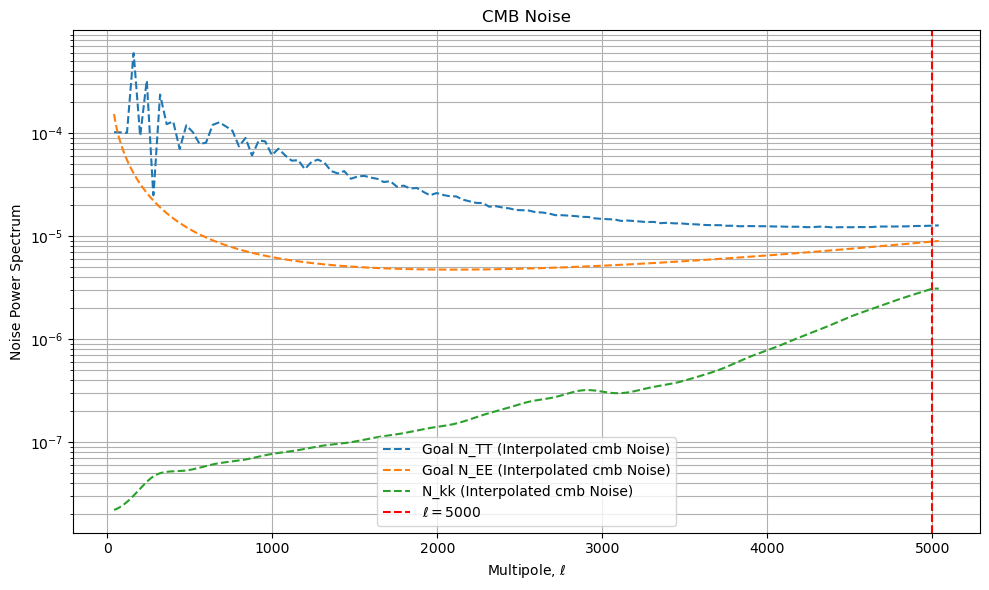

In [8]:
# build noise magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# LRG noise ref: slack from Simone, can't find the Github itself
# DES noise ref: https://arxiv.org/html/2511.04681v2
# HSC noise ref: https://arxiv.org/pdf/2507.01386
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
LRG_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree
LRG_n_bar_steradian = LRG_n_bar_deg2 * (180.0 / np.pi)**2
HSC_n_bar_arcmin2 = np.array([3.77, 5.07, 4.00, 2.12])
HSC_n_bar_deg2 = HSC_n_bar_arcmin2 * (60 ** 2)
HSC_n_bar_steradian = HSC_n_bar_deg2 * (180.0 / np.pi)**2
DES_n_bar_arcmin2 = np.array([5.59, 5.59, 5.59, 5.59])
DES_n_bar_deg2 = DES_n_bar_arcmin2 * (60 ** 2)
DES_n_bar_steradian = DES_n_bar_deg2 * (180.0 / np.pi)**2
BGS_shot_noise = [4.63e-7, 9.18e-7]

LRG_shape_noise = np.zeros_like(LRG_n_bar_steradian)
for i in range(len(LRG_shape_noise)):
    LRG_shape_noise[i] = sigma ** 2 / LRG_n_bar_steradian[i]

HSC_shape_noise = np.zeros_like(HSC_n_bar_steradian)
for i in range(len(HSC_shape_noise)):
    HSC_shape_noise[i] = sigma ** 2 / HSC_n_bar_steradian[i]

DES_shape_noise = np.zeros_like(DES_n_bar_steradian)
for i in range(len(DES_shape_noise)):
    DES_shape_noise[i] = sigma ** 2 / DES_n_bar_steradian[i]

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_goal_T_noise_data = np.loadtxt("data/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt")
SO_goal_T_noise_ells = SO_goal_T_noise_data[:, 0]
SO_goal_N_TT = SO_goal_T_noise_data[:, 1]
SO_goal_E_noise_data = np.loadtxt("data/SO_LAT_Nell_P_goal_fsky0p4_ILC_CMB_E.txt")
SO_goal_E_noise_ells = SO_goal_E_noise_data[:, 0]
SO_goal_N_EE = SO_goal_E_noise_data[:, 1]
SO_kk_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
SO_kk_noise_ells = SO_kk_noise_data[:, 0]
SO_N_kk = SO_kk_noise_data[:, 7]
ells_for_noise_interp = np.arange(40, 5000 + 40)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_goal_N_TT_func = interp1d(SO_goal_T_noise_ells, SO_goal_N_TT, bounds_error=False, fill_value=(SO_goal_N_TT[0], SO_goal_N_TT[-1]))
SO_goal_cmb_noise_TT = interpolated_goal_N_TT_func(ells_for_noise_interp)
interpolated_goal_N_EE_func = interp1d(SO_goal_E_noise_ells, SO_goal_N_EE, bounds_error=False, fill_value=(SO_goal_N_EE[0], SO_goal_N_EE[-1]))
SO_goal_cmb_noise_EE = interpolated_goal_N_EE_func(ells_for_noise_interp)
interpolated_N_kk_func = interp1d(SO_kk_noise_ells, SO_N_kk, bounds_error=False, fill_value=(SO_N_kk[0], SO_N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)

# plot cmb noise to see what it looks like
plt.figure(figsize=(10, 6))
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_TT, label='Goal N_TT (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_EE, label='Goal N_EE (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum')
plt.title('CMB Noise')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [9]:
# constraint on H0 for LCDM -- compare with SO paper

# Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\kappa_{c}\kappa_{c}}, C_\ell^{\kappa_{c}g}, C_\ell^{\kappa_{c}\kappa_{g}}, C_\ell^{\kappa_{g}\kappa_{g}}, C_\ell^{\kappa_{g}g}, C_\ell^{gg}]$$

This vector consists of:
* **cmb lensing convergence power spectrum:** $C_\ell^{\kappa_{c}\kappa_{c}}$
* **Galaxy lensing–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}\kappa_{g}}$ (cmb lensing - galaxy lensing)
* **Lens galaxies–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}g}$ (cmb lensing - galaxy number density)
* **Galaxy lensing convergence auto/cross-spectrum:** $C_\ell^{\kappa_{g}\kappa_{g}}$
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\kappa_{g}}$ (galaxy - galaxy lensing)
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)

Note: In all the code written and used before 06/26/2026 $\kappa_{c}$ is written as $\phi$, $\kappa_{c}$ is listed as $l$, and $g$ is listed as $g$. I originally expected to be working with lensing potential, and changing the labels generated some bugs, so I left it as it was for a while.

If we have **a** lens bins and **b** source bins we have 1 cmb, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-cmb, and b source-cmb spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [ ]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin w/primaries...")

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
l_min = 40
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        flat_LCDM_cosmology,
        bgs_combined_array,
        HSC_dist_0_3,
        f_sky=f_sky,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=BGS_shot_noise,
        shape_noise_source=HSC_shape_noise,
        cmb_noise_kk=SO_cmb_noise_kk,
        cmb_noise_TT=SO_goal_cmb_noise_TT,
        cmb_noise_EE=SO_goal_cmb_noise_EE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL', 'EE', 'TT', 'TE'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_LRP_Photo_HSC_est_BGS_data_vector.npy'
covariance_filename = 'cobaya_data/flat_LCDM_LRP_Photo_HSC_est_BGS_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# Fishers

## Geometry vs Power Spectrum Test

### Flat w0waCDM

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3189\pm 0.0052$ | $\Omega_m = 0.319^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3190\pm 0.0053$ | $\Omega_m = 0.319^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0048$ | $h = 0.6674^{+0.0093}_{-0.0093}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0048$ | $h = 0.6674^{+0.0094}_{-0.0094}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.042$ | $w_0 = -0.752^{+0.083}_{-0.083}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.042$ | $w_0 = -0.752^{+0.083}_{-0.083}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.33}_{-0.33}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.33}_{-0.33}$ |
| --- | --- | --- | --- |

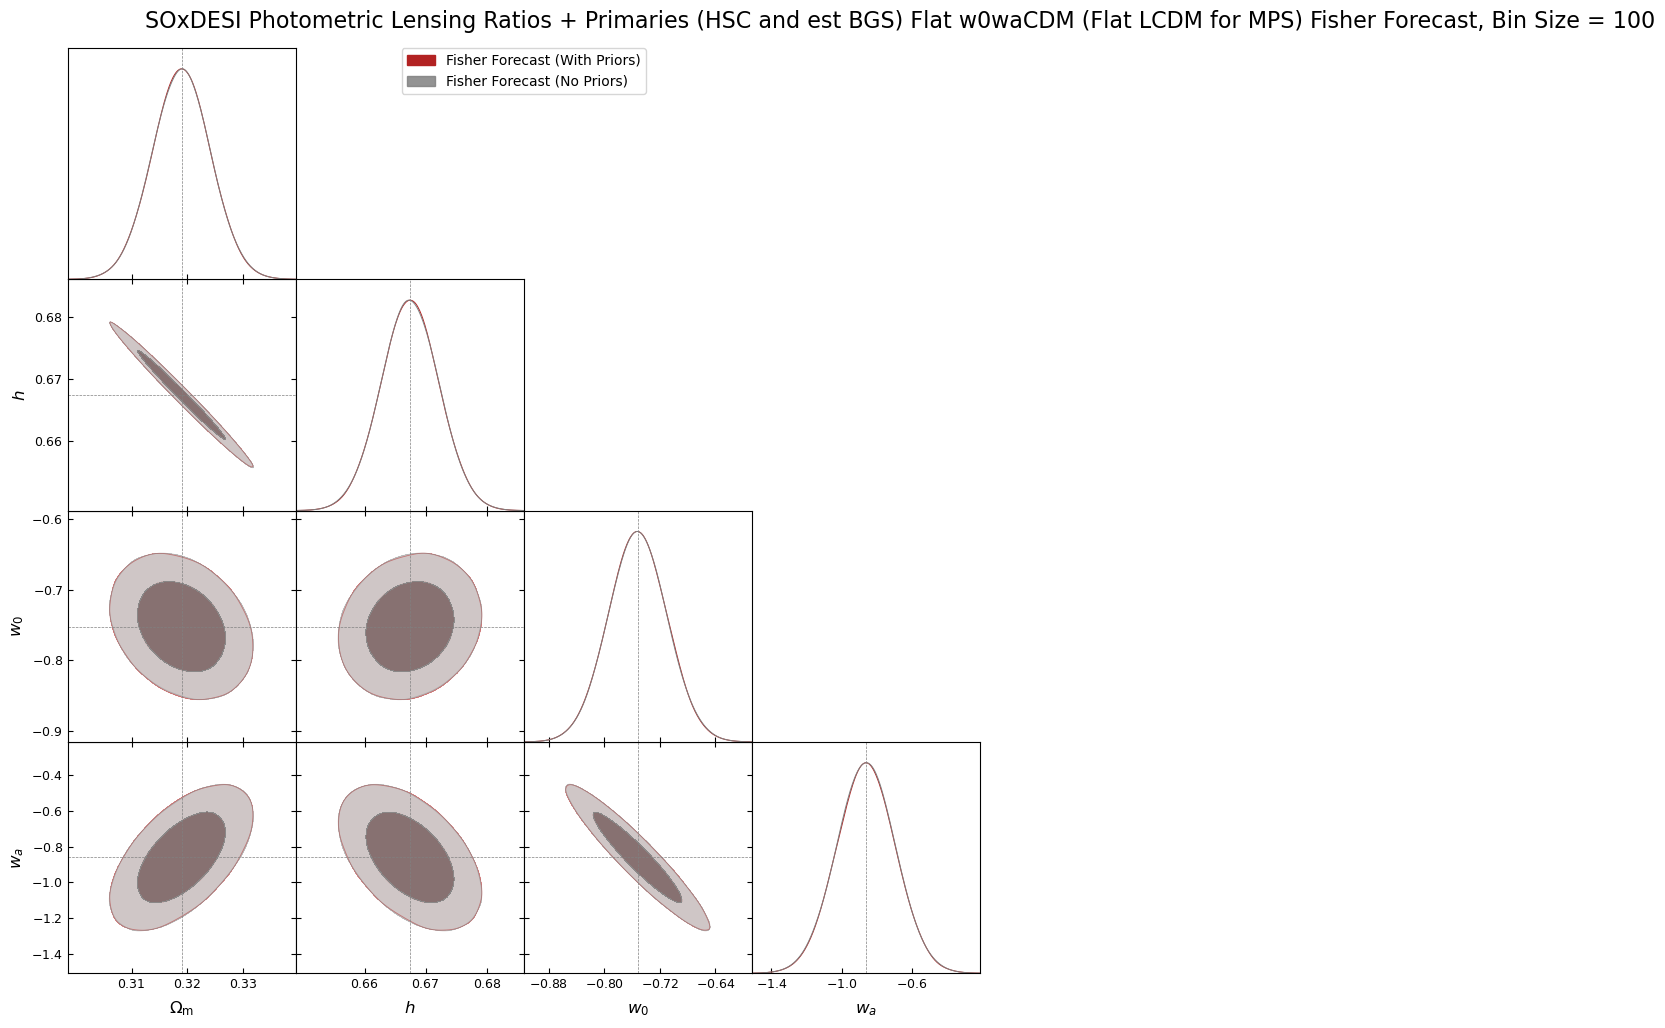

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00071$ | $\Omega_{b} = 0.0499^{+0.0014}_{-0.0014}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00072$ | $\Omega_{b} = 0.0499^{+0.0014}_{-0.0014}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0045$ | $\Omega_{c} = 0.2676^{+0.0089}_{-0.0089}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0046$ | $\Omega_{c} = 0.2676^{+0.0089}_{-0.0090}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0048$ | $h = 0.6674^{+0.0093}_{-0.0093}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0048$ | $h = 0.6674^{+0.0094}_{-0.0093}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.042$ | $w_0 = -0.752^{+0.083}_{-0.083}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.042$ | $w_0 = -0.752^{+0.083}_{-0.083}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.33}_{-0.33}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.33}_{-0.33}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0084}_{-0.0084}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0085}_{-0.0085}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0047}_{-0.0047}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0047}_{-0.0047}$ |
| --- | --- | --- | --- |

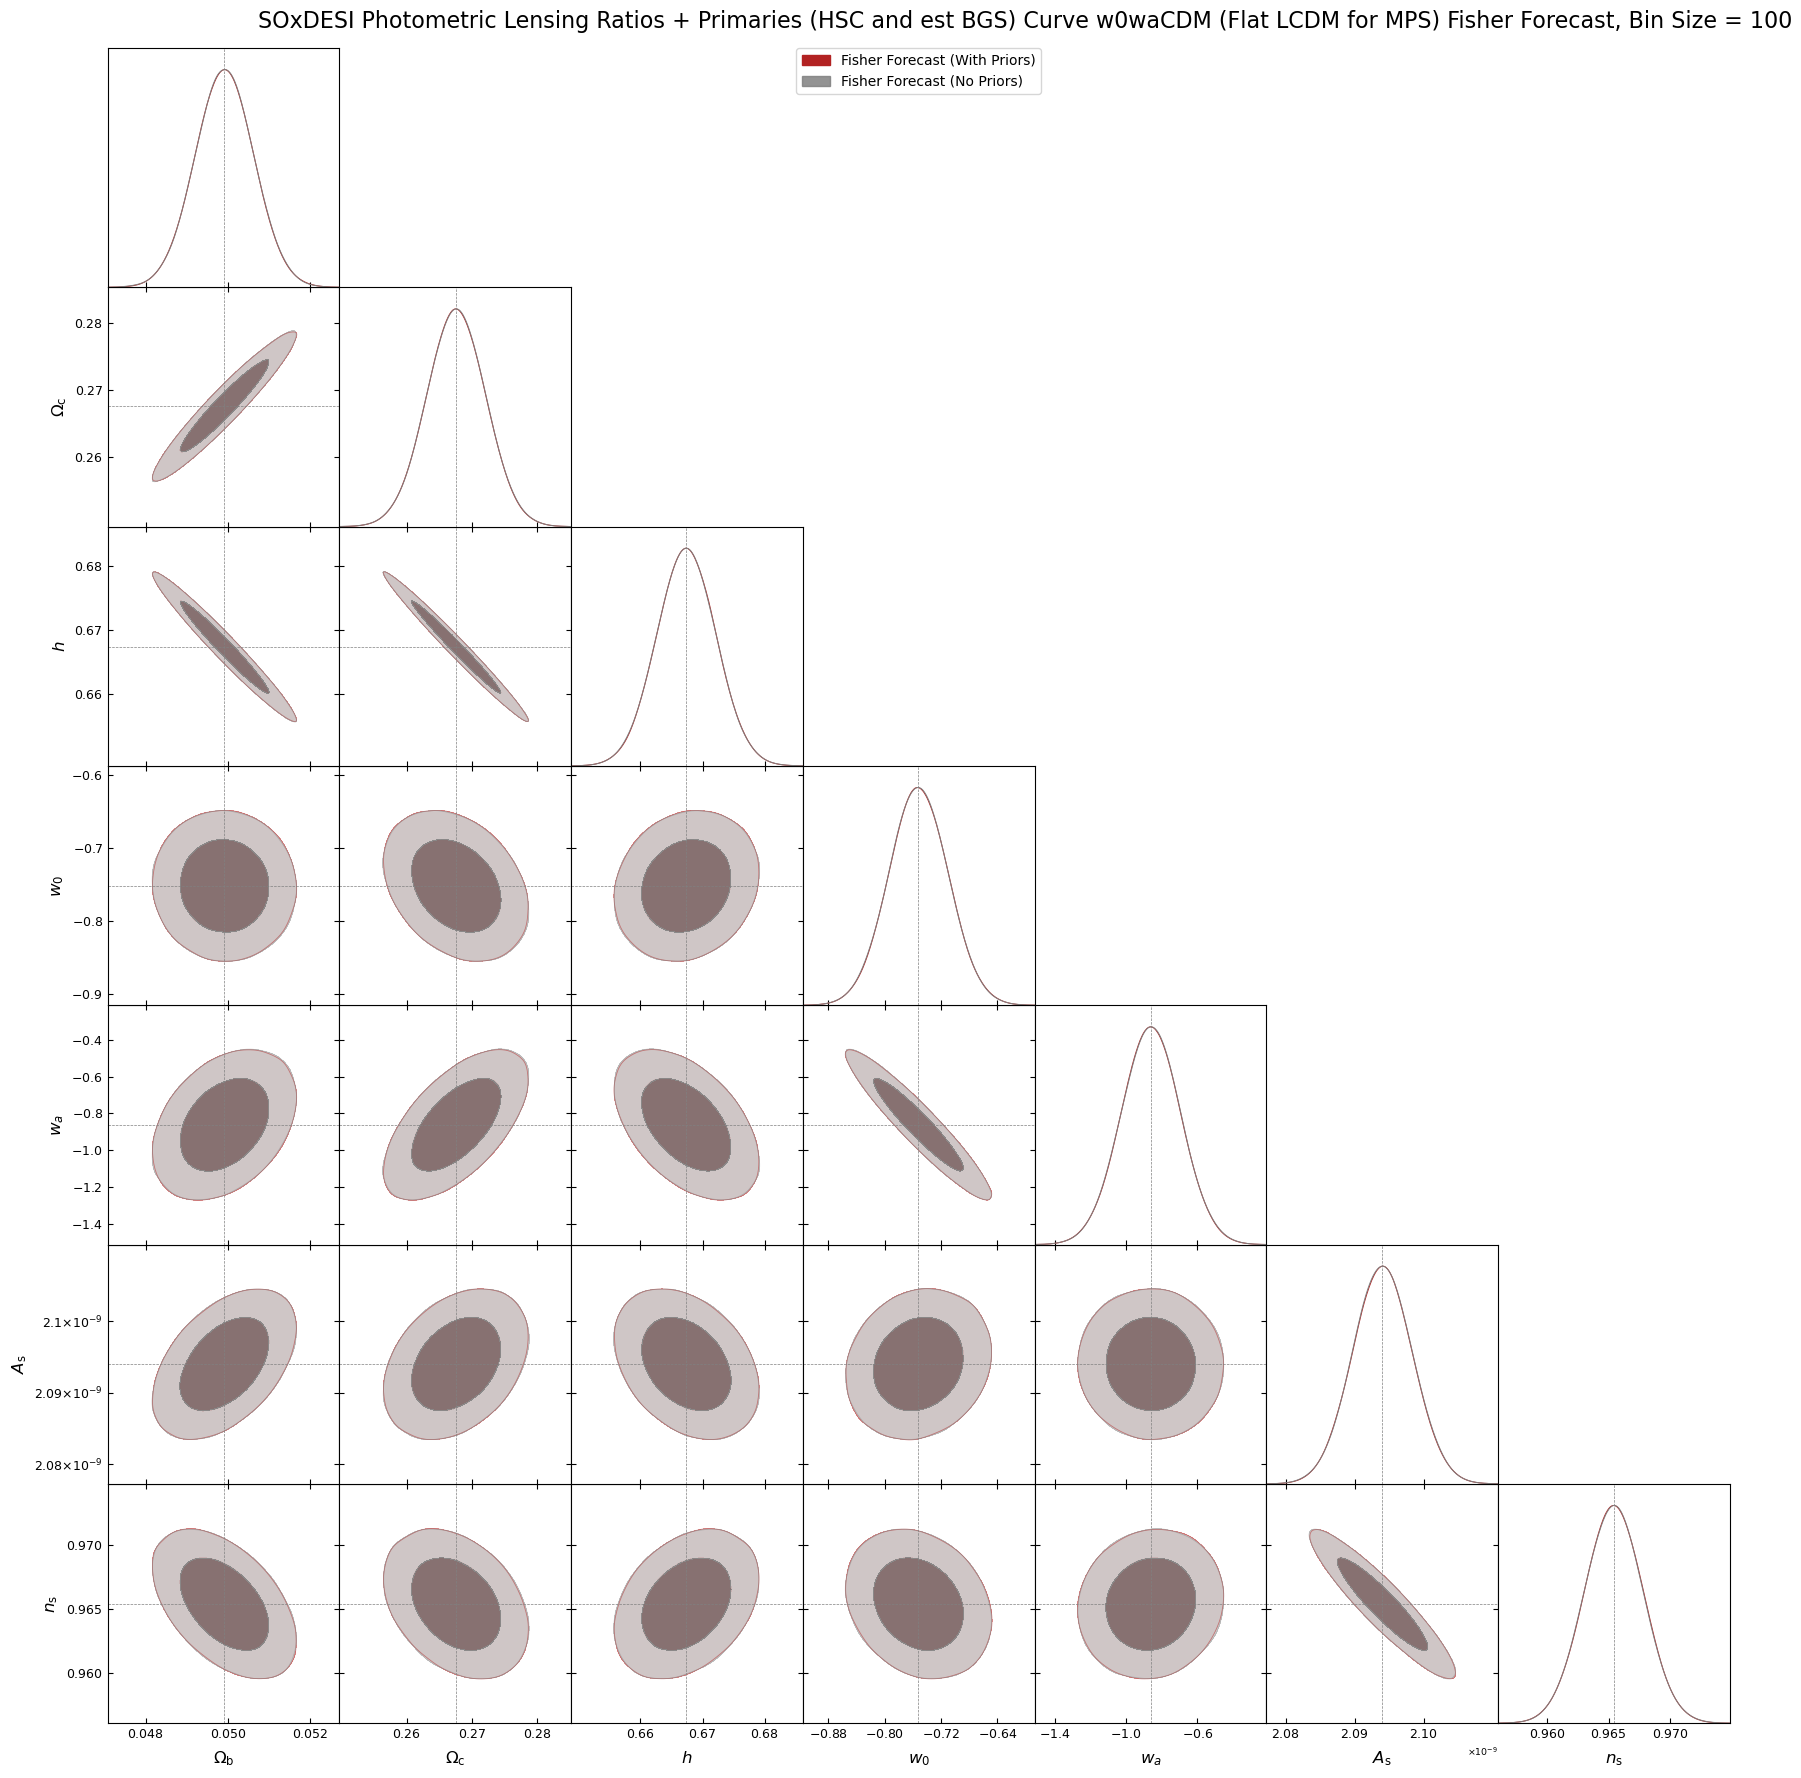

total_time:  0:03:26.656906


In [14]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Flat w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3190\pm 0.0055$ | $\Omega_m = 0.319^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3190\pm 0.0055$ | $\Omega_m = 0.319^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.041$ | $w_0 = -0.752^{+0.080}_{-0.080}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.041$ | $w_0 = -0.752^{+0.080}_{-0.080}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
| --- | --- | --- | --- |

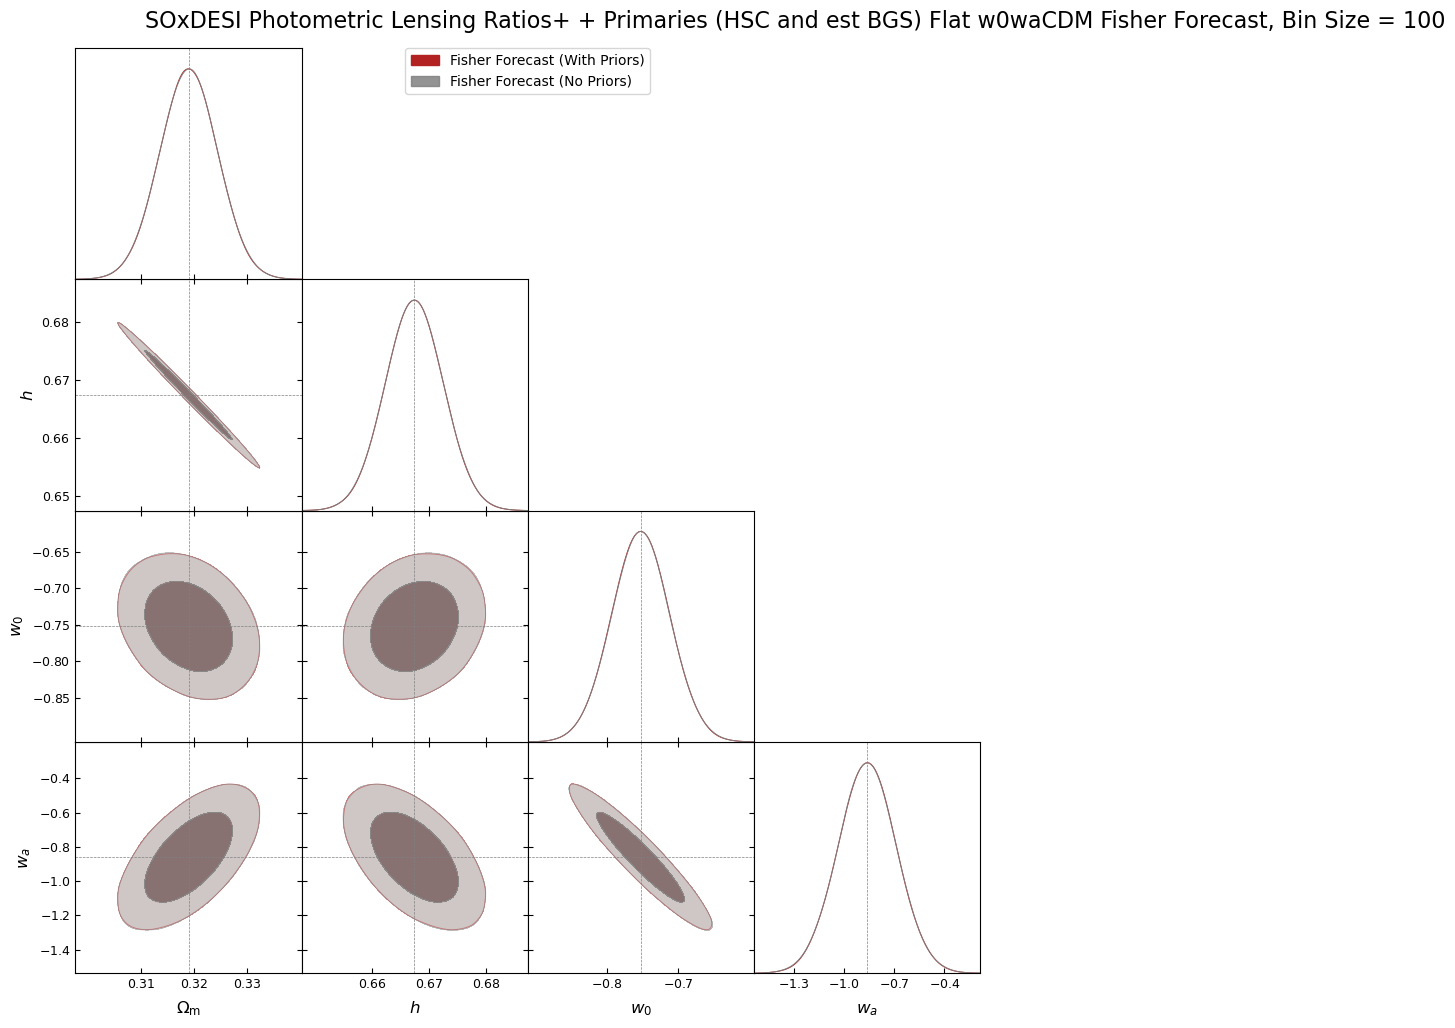

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00076$ | $\Omega_{b} = 0.0499^{+0.0015}_{-0.0015}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00076$ | $\Omega_{b} = 0.0499^{+0.0015}_{-0.0015}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0047$ | $\Omega_{c} = 0.2676^{+0.0093}_{-0.0093}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0047$ | $\Omega_{c} = 0.2676^{+0.0093}_{-0.0092}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.041$ | $w_0 = -0.752^{+0.080}_{-0.080}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.041$ | $w_0 = -0.752^{+0.080}_{-0.080}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0084}_{-0.0085}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0084}_{-0.0085}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0047}_{-0.0047}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0047}_{-0.0047}$ |
| --- | --- | --- | --- |

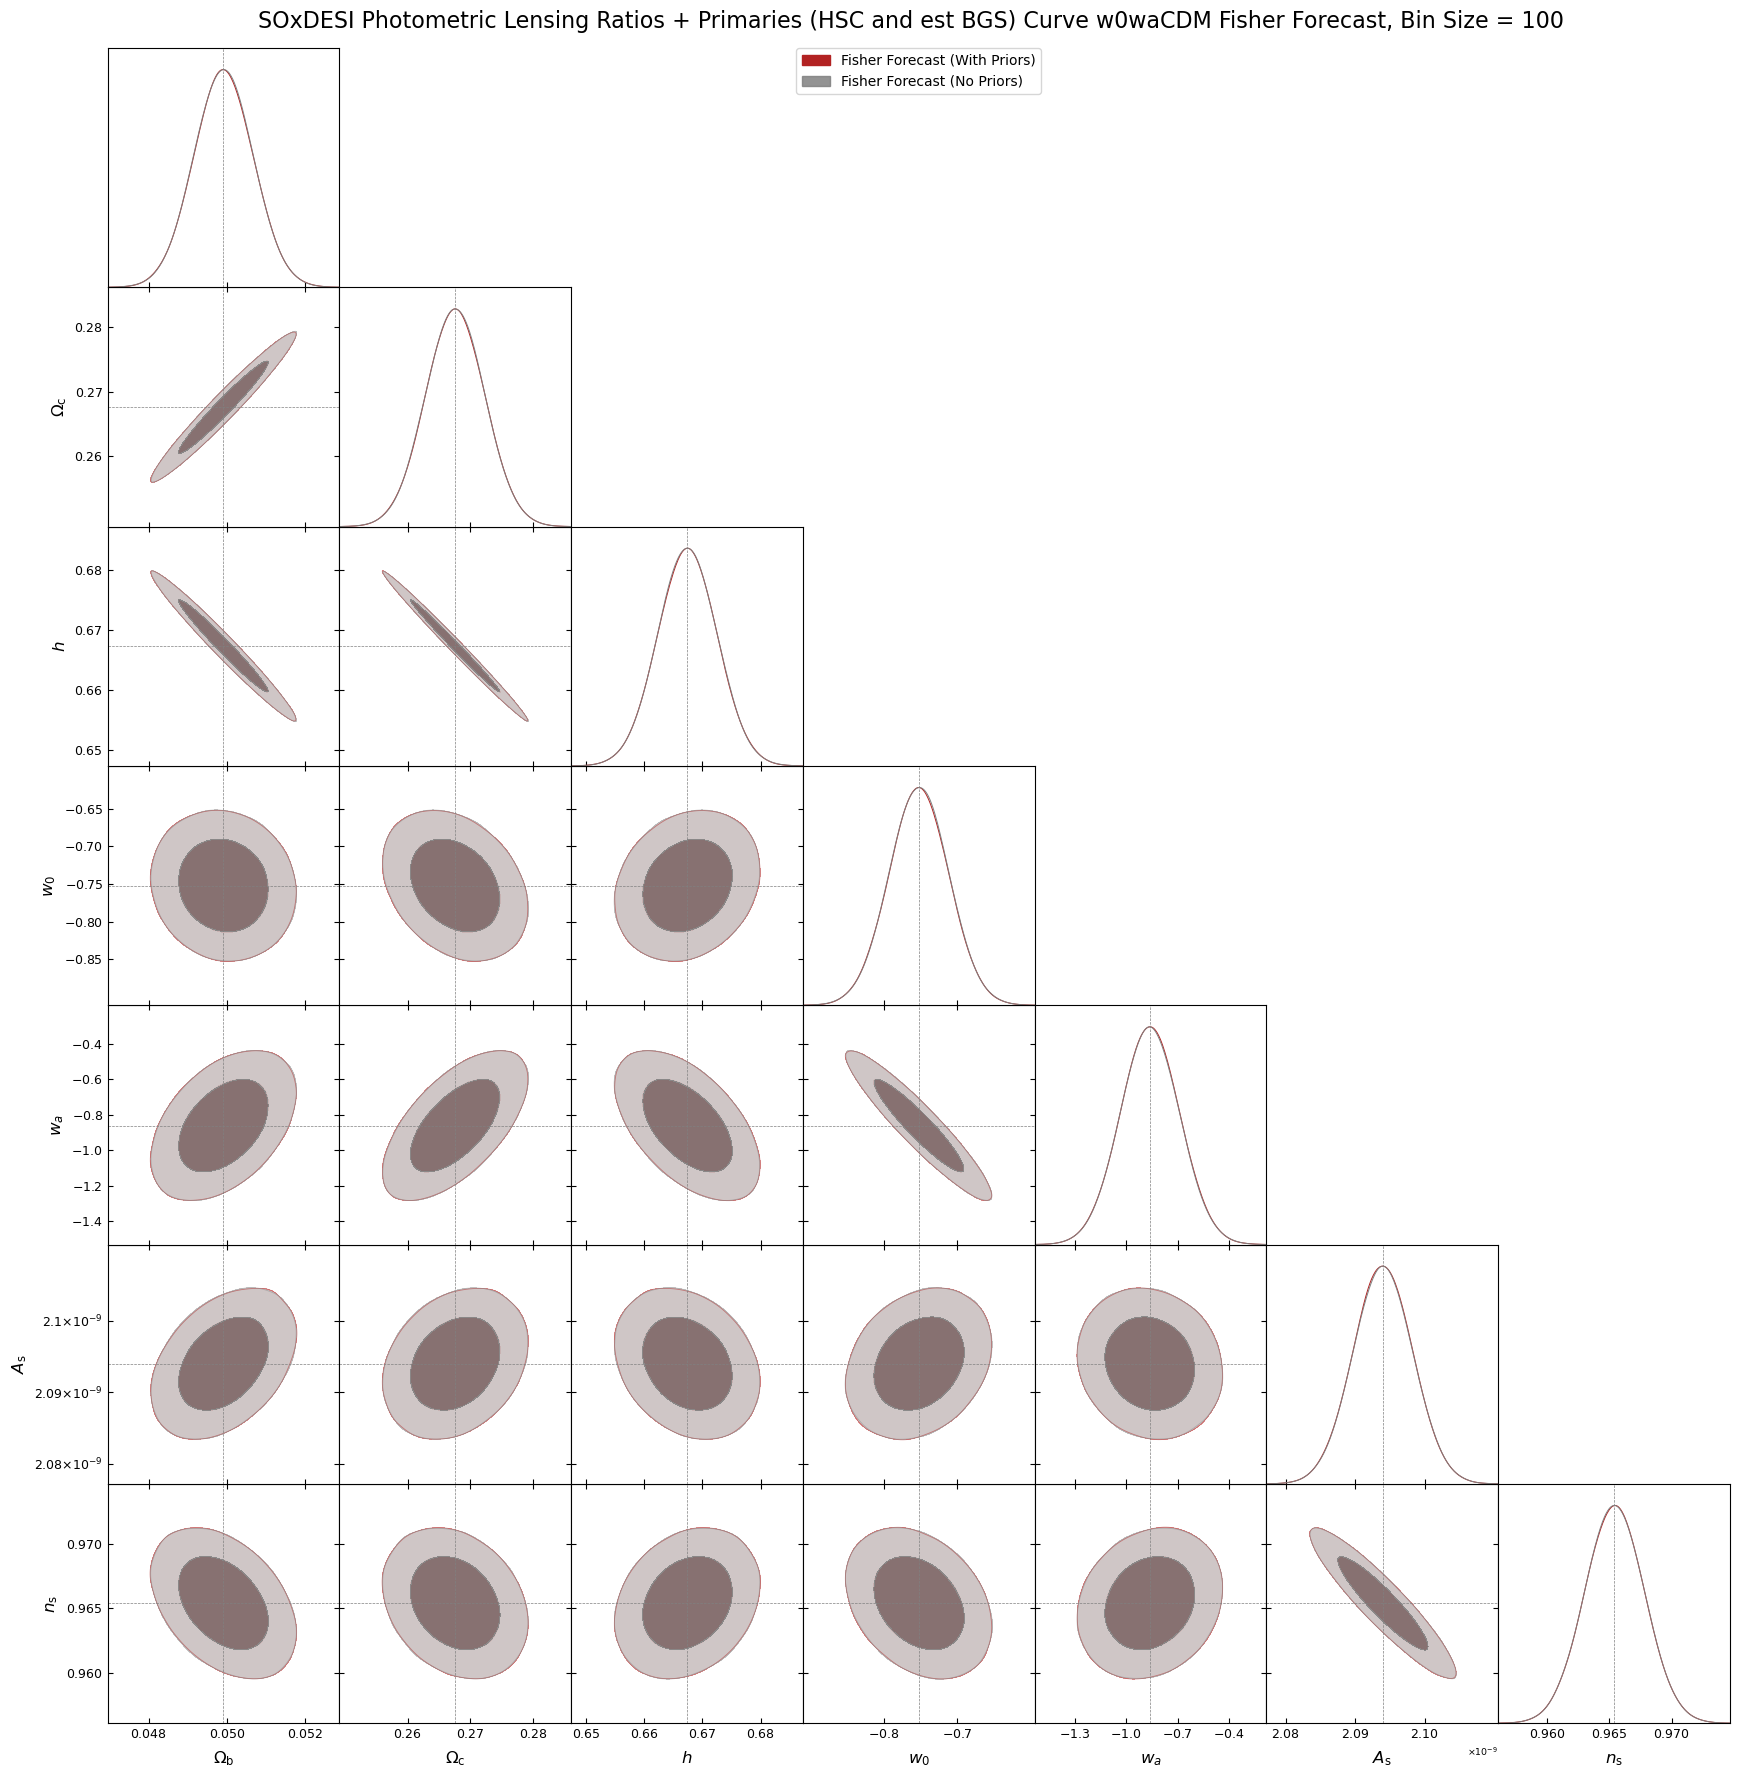

total_time:  0:03:31.803486


In [15]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios+ + Primaries (HSC and est BGS) Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.324\pm 0.059$ | $\Omega_m = 0.32^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.364$ | $\Omega_m = \Omega_\mathrm{m} < 0.481$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.67^{+0.25}_{-0.16}$ | $h = 0.67^{+0.32}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 2.1$ | $h = 0.7^{+4.1}_{-4.1}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.06^{+0.64}_{-0.28}$ | $w_0 = -1.06^{+0.77}_{-0.90}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.8\pm 1.2$ | $w_0 = -0.8^{+2.4}_{-2.4}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.4^{+2.4}_{-1.6}$ | $w_a = 0.4^{+2.5}_{-3.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.9\pm 6.7$ | $w_a = -1^{+13}_{-13}$ |
| --- | --- | --- | --- |

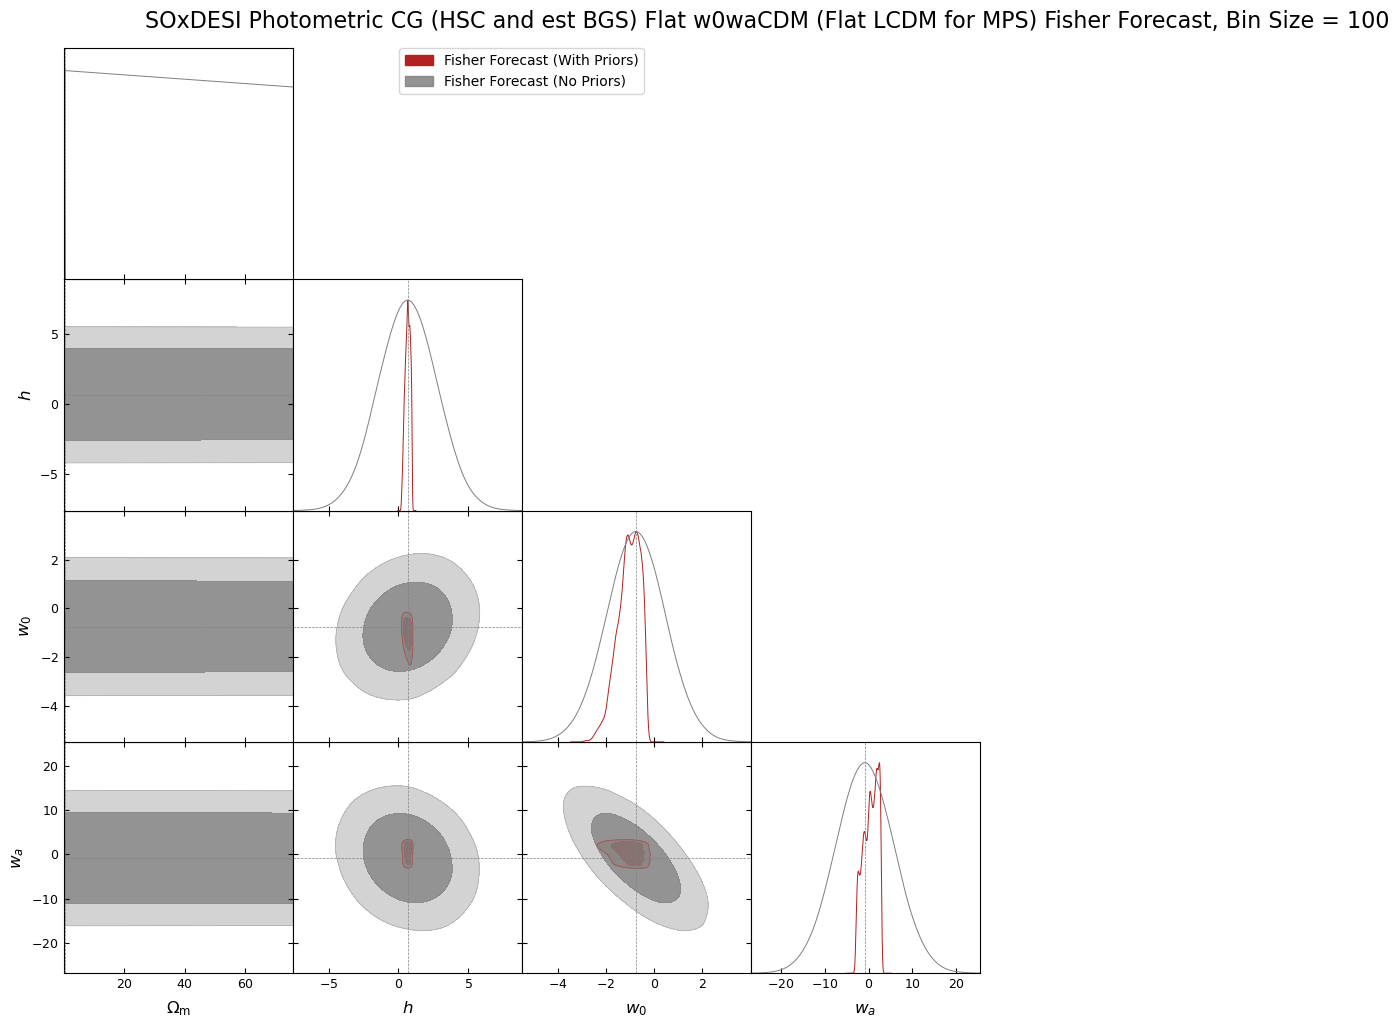

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.073^{+0.026}_{-0.056}$ | $\Omega_{b} = 0.073^{+0.077}_{-0.064}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.05\pm 0.36$ | $\Omega_{b} = 0.05^{+0.70}_{-0.71}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.246\pm 0.063$ | $\Omega_{c} = 0.25^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.27\pm 0.35$ | $\Omega_{c} = 0.27^{+0.69}_{-0.69}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.67^{+0.23}_{-0.17}$ | $h = 0.67^{+0.32}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 2.1$ | $h = 0.7^{+4.1}_{-4.1}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.05^{+0.64}_{-0.30}$ | $w_0 = -1.05^{+0.77}_{-0.94}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.8\pm 1.2$ | $w_0 = -0.8^{+2.4}_{-2.4}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.3^{+2.4}_{-1.4}$ | $w_a = 0.3^{+2.5}_{-3.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.9\pm 6.7$ | $w_a = -1^{+13}_{-13}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.78^{+0.51}_{-1.1}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.8^{+1.6}_{-1.3}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1\pm 5.7\,\right)\cdot 10^{-9}$ | $A_s = \left(\,0.2^{+1.1}_{-1.1}\,\right)\cdot 10^{-8}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 1.007^{+0.066}_{-0.046}$ | $n_s = 1.007^{+0.087}_{-0.092}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.96\pm 0.43$ | $n_s = 0.96^{+0.83}_{-0.83}$ |
| --- | --- | --- | --- |

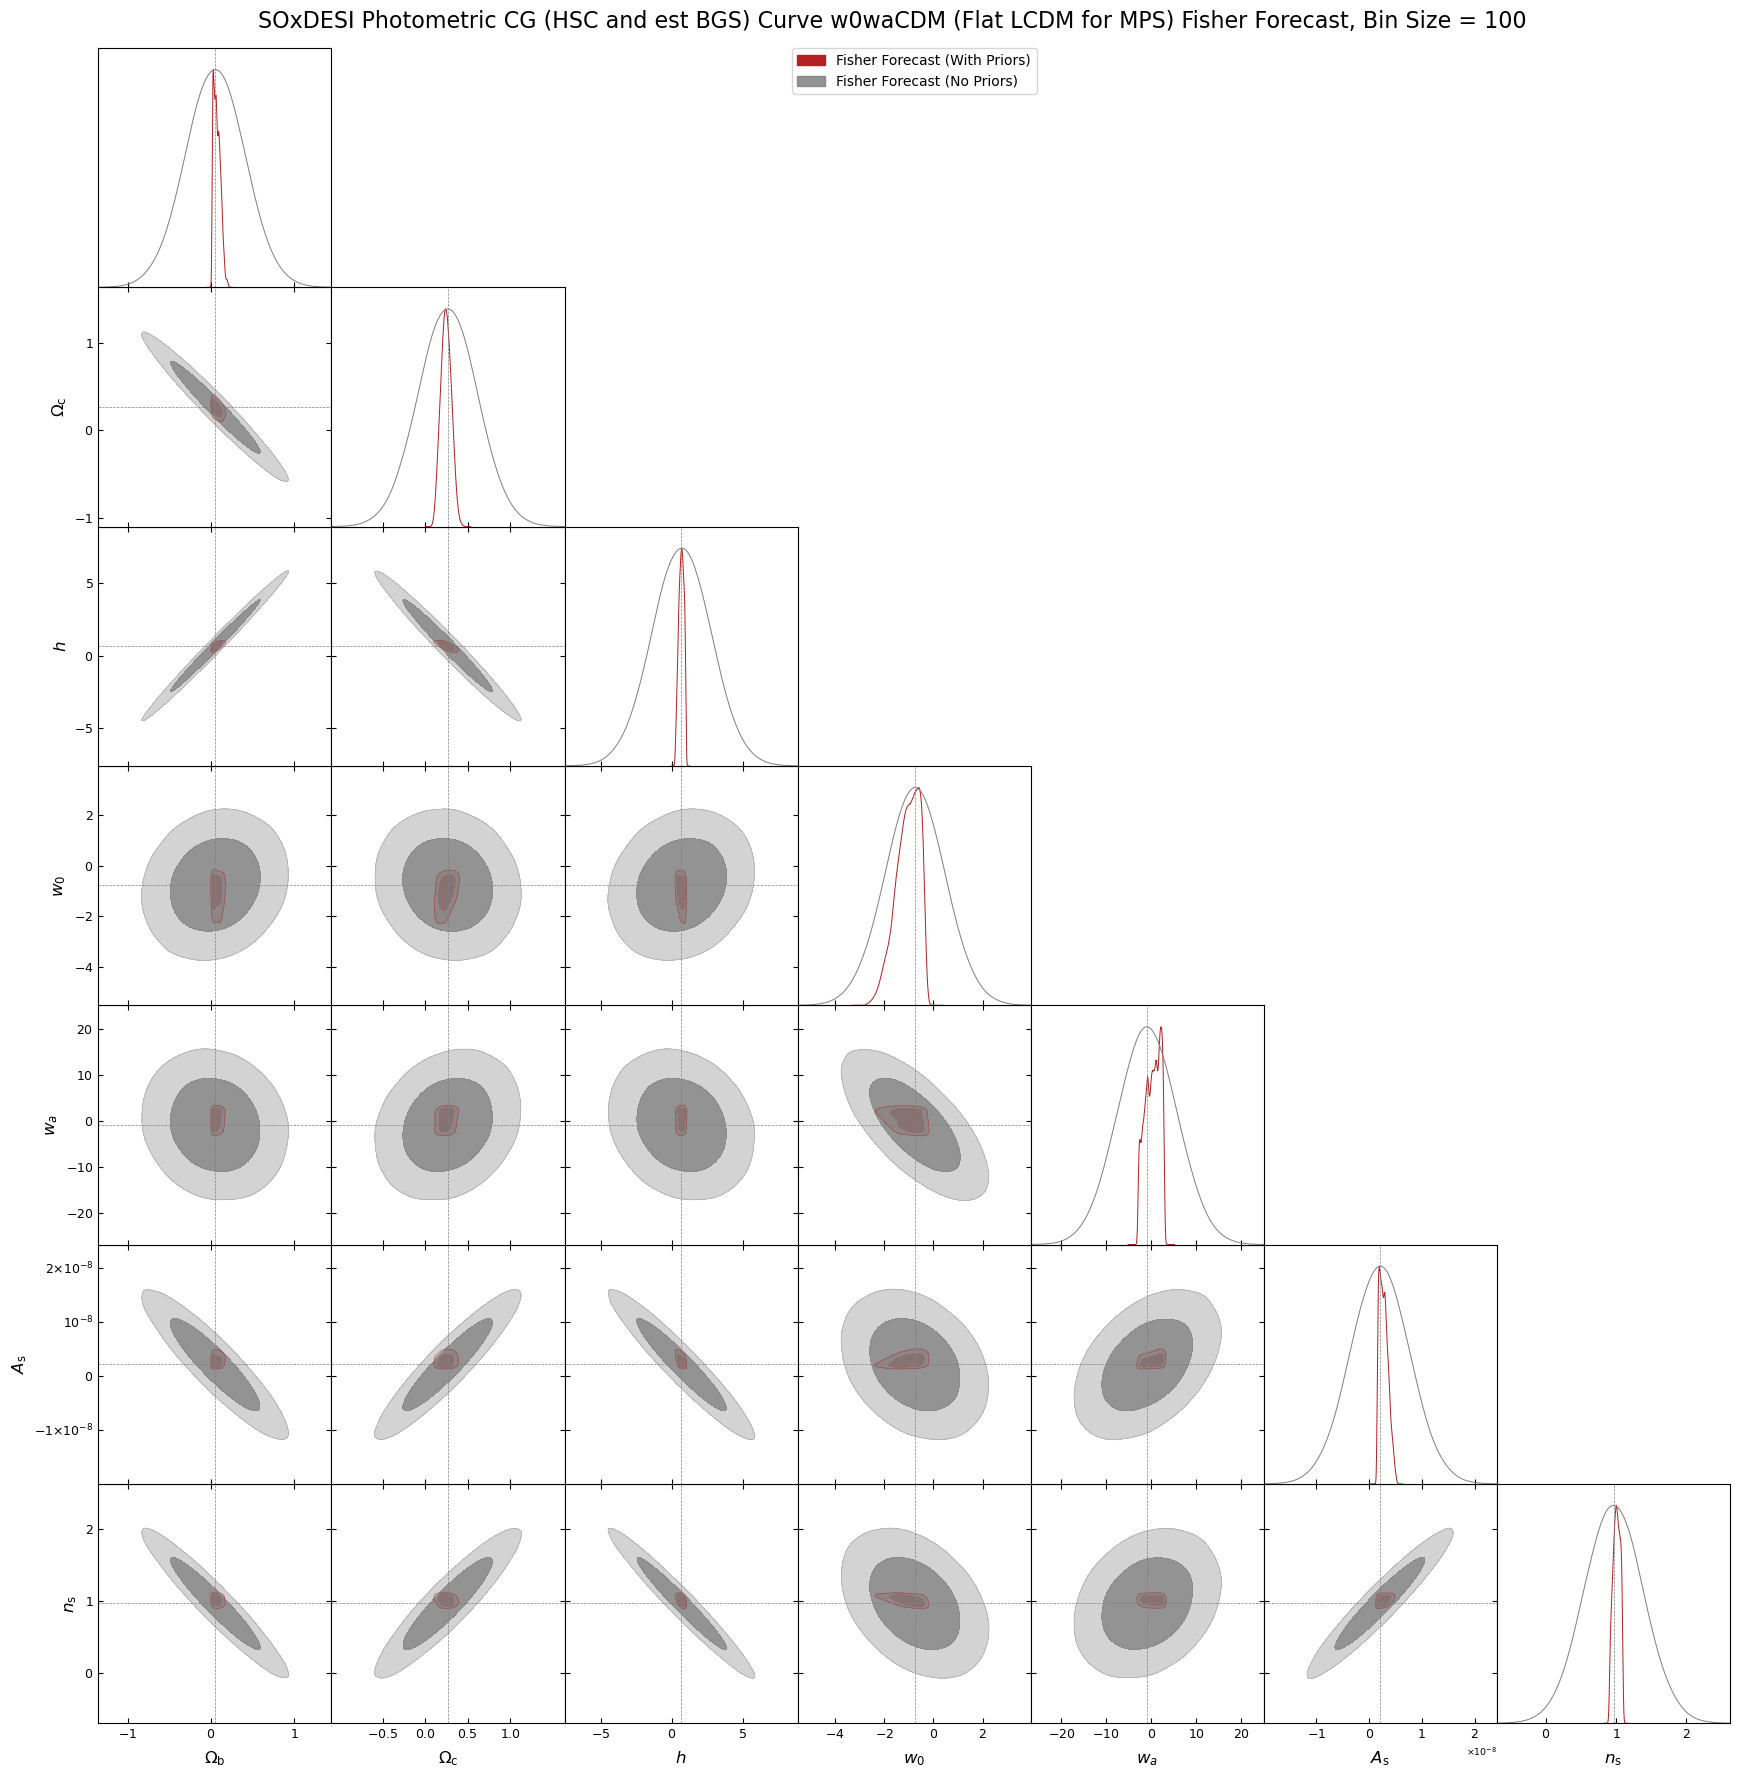

total_time:  0:03:26.222048


In [16]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CG (HSC and est BGS) Flat w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CG (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.322\pm 0.061$ | $\Omega_m = 0.32^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.363$ | $\Omega_m = \Omega_\mathrm{m} < 0.478$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.67^{+0.23}_{-0.15}$ | $h = 0.67^{+0.31}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 2.0$ | $h = 0.7^{+3.8}_{-3.8}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.05^{+0.65}_{-0.30}$ | $w_0 = -1.05^{+0.76}_{-0.93}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.7\pm 1.1$ | $w_0 = -0.7^{+2.2}_{-2.2}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.3^{+2.5}_{-1.3}$ | $w_a = 0.3^{+2.6}_{-3.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.9\pm 6.5$ | $w_a = -1^{+13}_{-13}$ |
| --- | --- | --- | --- |

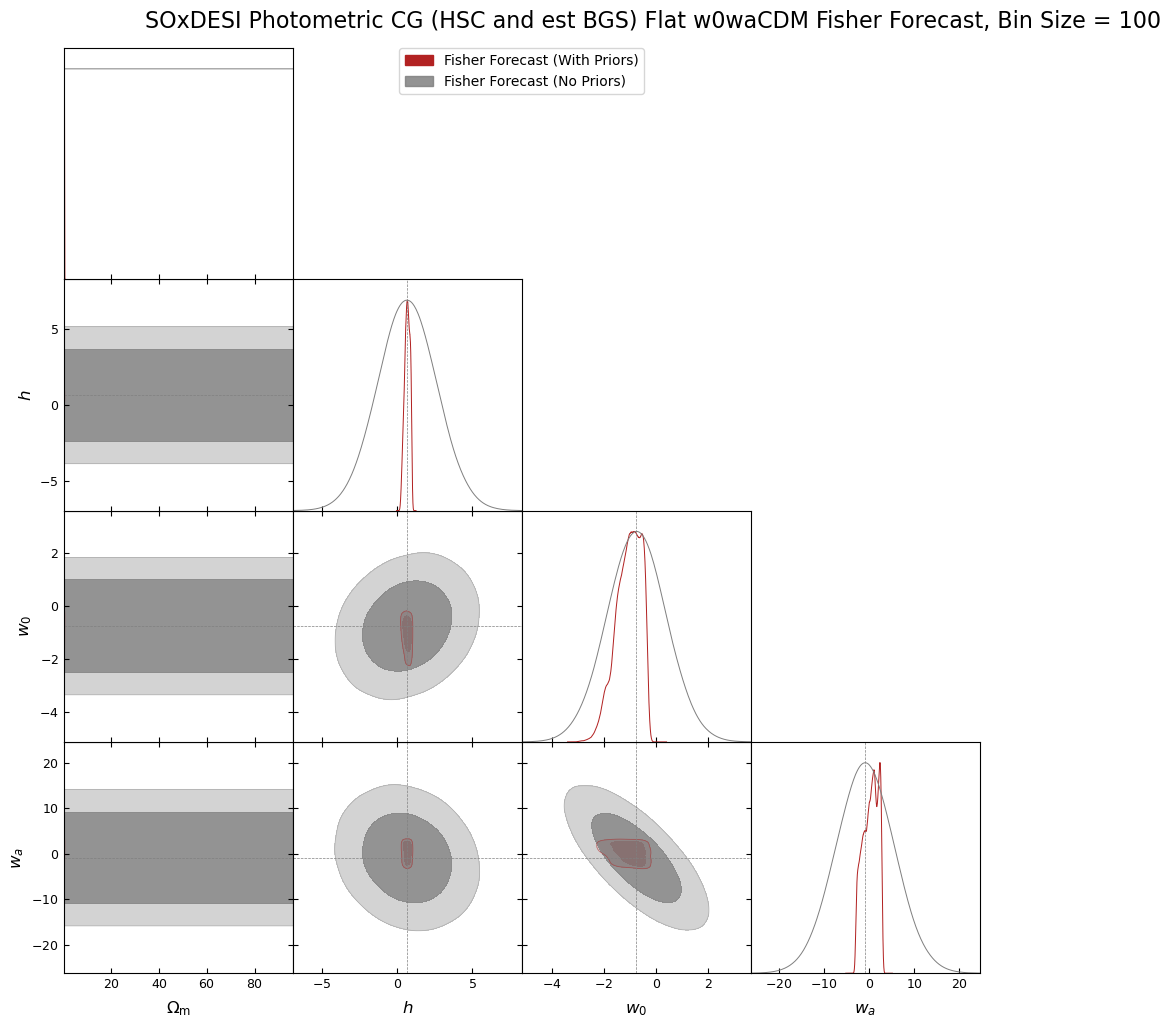

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.077^{+0.024}_{-0.060}$ | $\Omega_{b} = 0.077^{+0.081}_{-0.067}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.05\pm 0.37$ | $\Omega_{b} = 0.05^{+0.73}_{-0.73}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.245^{+0.062}_{-0.072}$ | $\Omega_{c} = 0.25^{+0.13}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.27\pm 0.36$ | $\Omega_{c} = 0.27^{+0.71}_{-0.71}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.67^{+0.22}_{-0.16}$ | $h = 0.67^{+0.32}_{-0.33}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 2.0$ | $h = 0.7^{+3.9}_{-3.9}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.04^{+0.63}_{-0.28}$ | $w_0 = -1.04^{+0.74}_{-0.89}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.8\pm 1.1$ | $w_0 = -0.8^{+2.2}_{-2.2}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.3^{+2.4}_{-1.1}$ | $w_a = 0.3^{+2.6}_{-3.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 6.5$ | $w_a = -1^{+13}_{-13}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.70^{+0.49}_{-0.98}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.7^{+1.5}_{-1.2}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1\pm 4.7\,\right)\cdot 10^{-9}$ | $A_s = \left(\,0.21^{+0.92}_{-0.92}\,\right)\cdot 10^{-8}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 1.005^{+0.062}_{-0.050}$ | $n_s = 1.005^{+0.088}_{-0.091}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.96\pm 0.42$ | $n_s = 0.96^{+0.82}_{-0.83}$ |
| --- | --- | --- | --- |

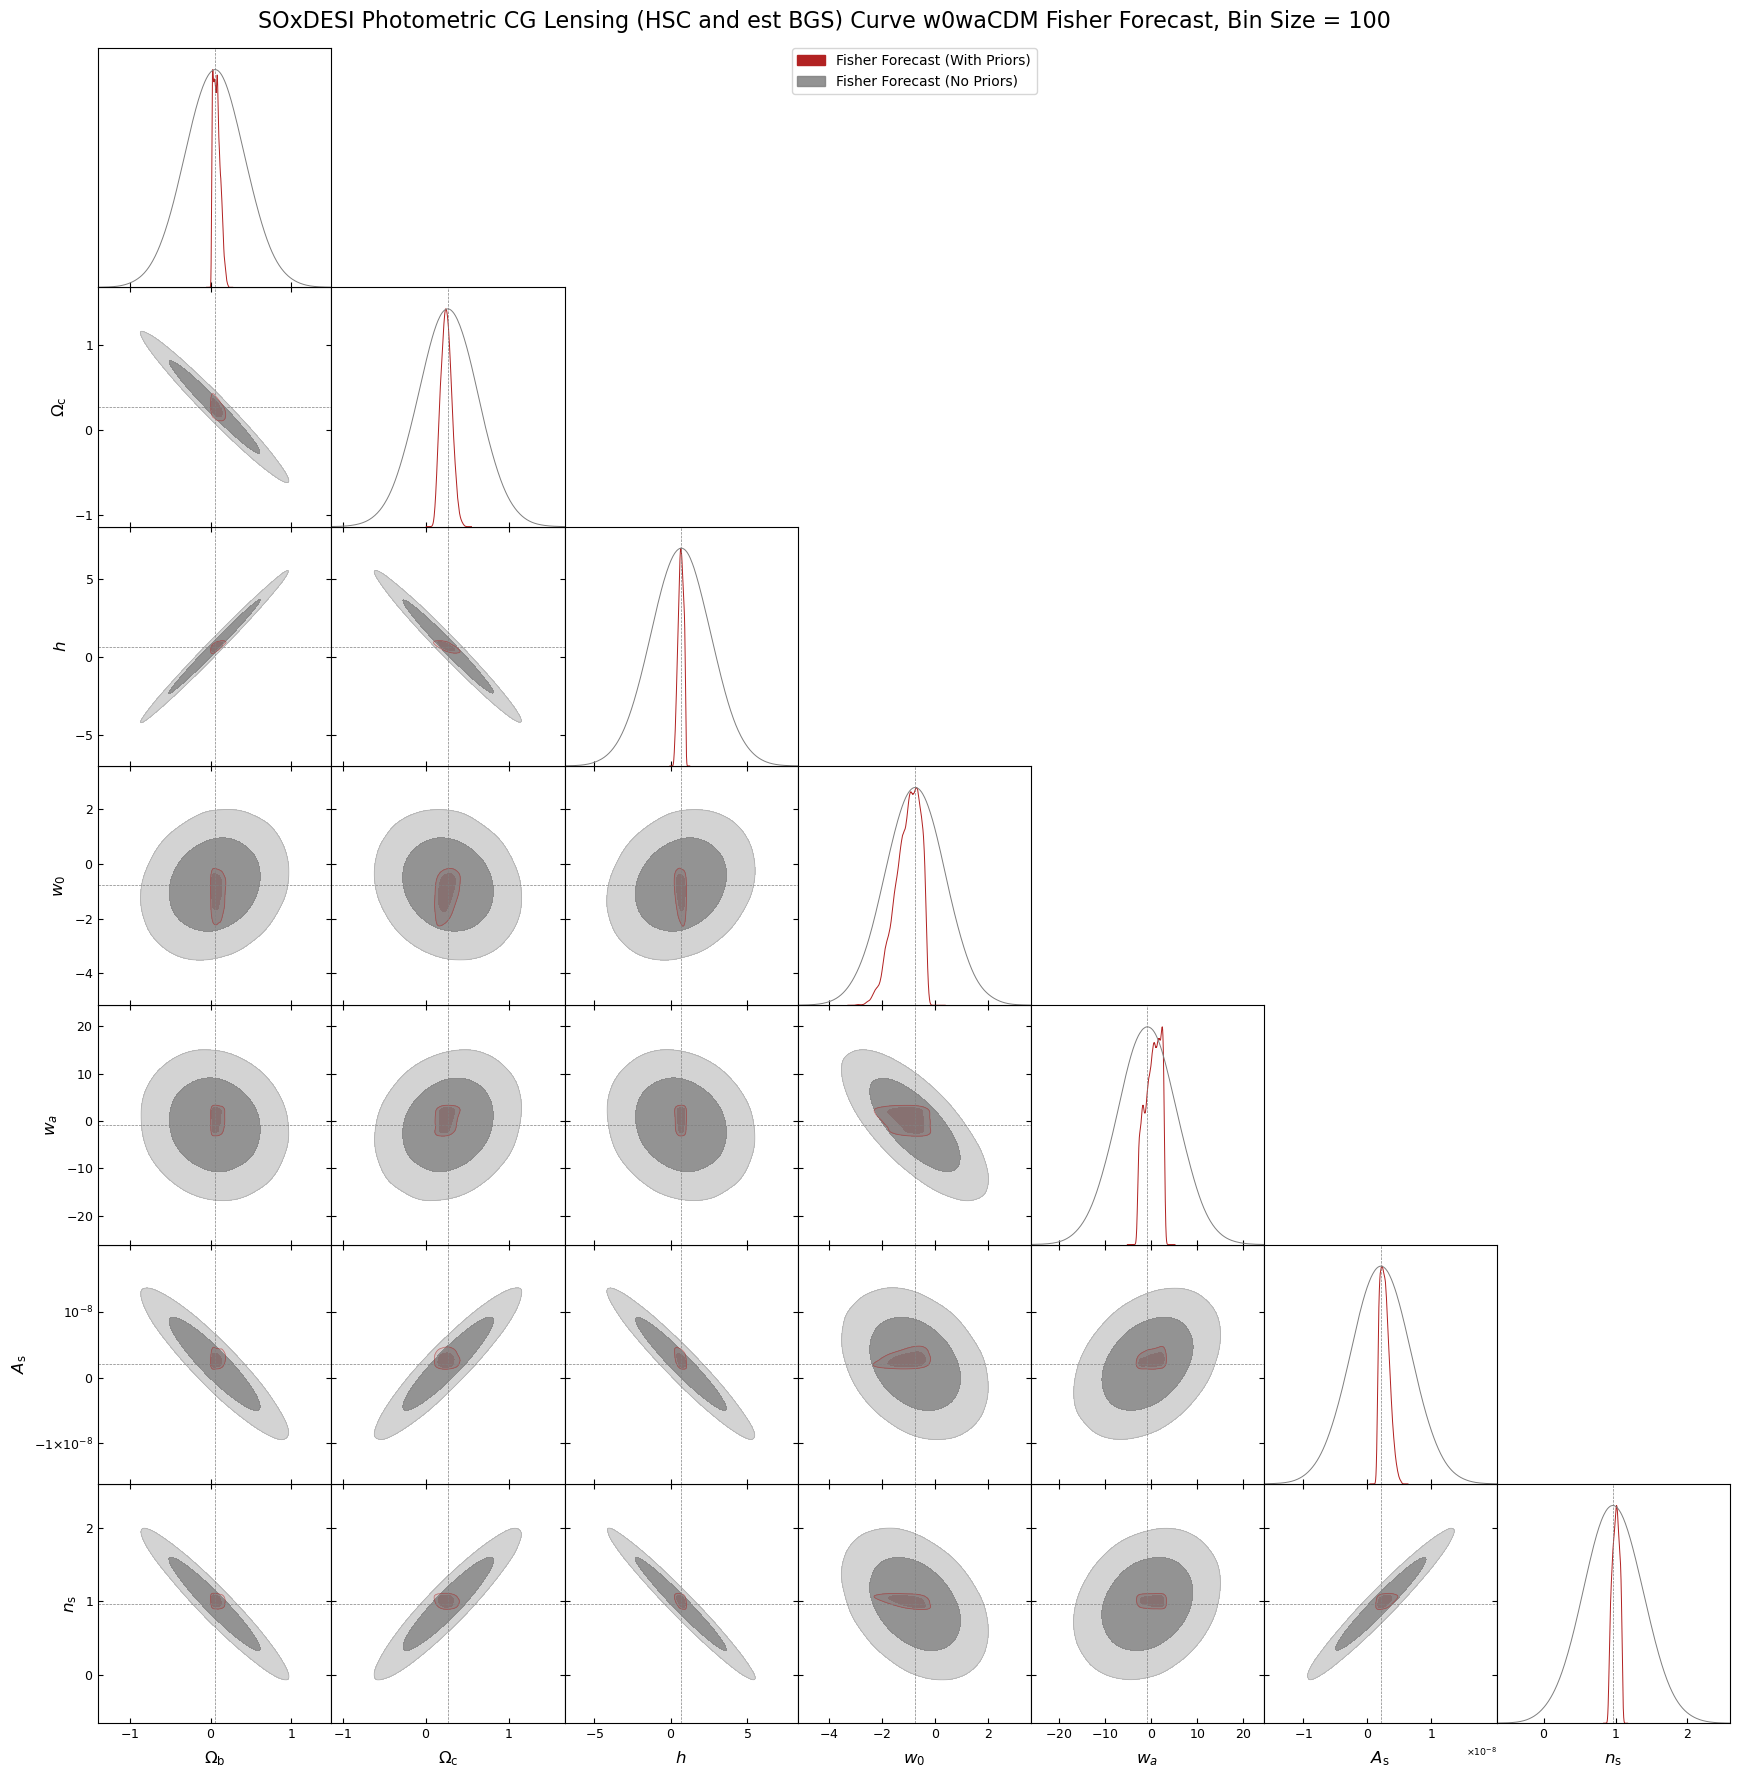

total_time:  0:03:28.873466


In [17]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CG (HSC and est BGS) Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CG Lensing (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.40^{+0.13}_{-0.16}$ | $\Omega_m = 0.40^{+0.28}_{-0.26}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.654$ | $\Omega_m = \Omega_\mathrm{m} < 1.49$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.55^{+0.18}_{-0.27}$ | $h = 0.55^{+0.41}_{-0.36}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 1.3$ | $h = 0.7^{+2.5}_{-2.5}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.25^{+0.84}_{-0.47}$ | $w_0 = -1.2^{+1.0}_{-1.2}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.7\pm 8.6$ | $w_0 = -1^{+17}_{-17}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.7^{+1.9}_{-1.0}$ | $w_a = 0.7^{+2.4}_{-3.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -1\pm 22$ | $w_a = -1^{+43}_{-43}$ |
| --- | --- | --- | --- |

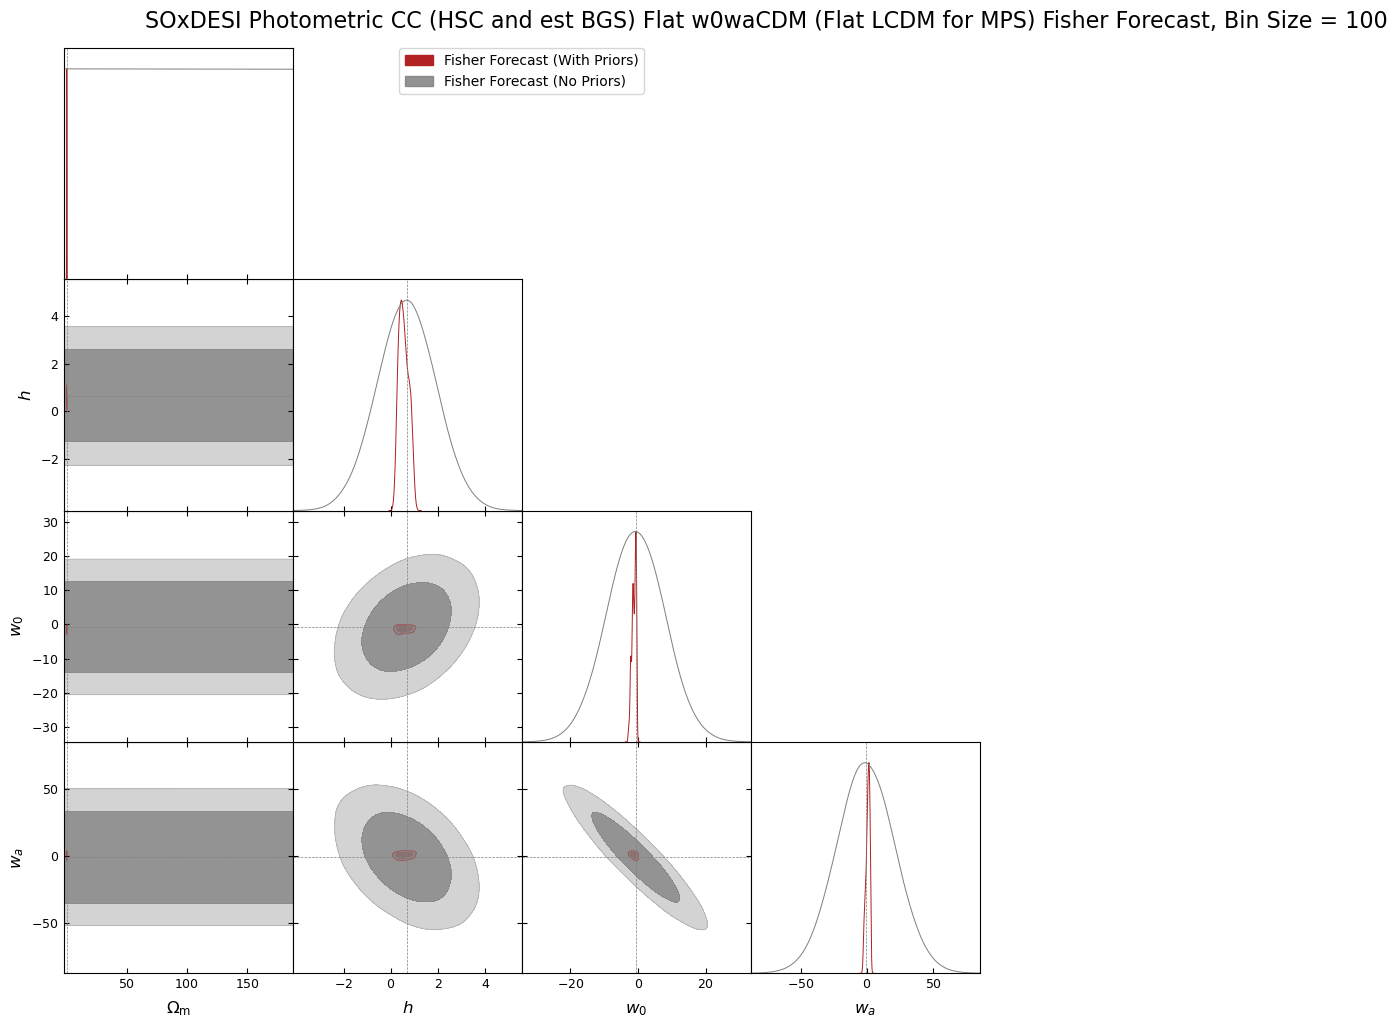

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.065^{+0.024}_{-0.045}$ | $\Omega_{b} = 0.065^{+0.075}_{-0.058}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.05\pm 0.17$ | $\Omega_{b} = 0.05^{+0.33}_{-0.33}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.32\pm 0.11$ | $\Omega_{c} = 0.32^{+0.22}_{-0.21}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.27\pm 0.53$ | $\Omega_{c} = 0.3^{+1.0}_{-1.0}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.55^{+0.21}_{-0.25}$ | $h = 0.55^{+0.39}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 1.3$ | $h = 0.7^{+2.4}_{-2.5}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.24^{+0.91}_{-0.34}$ | $w_0 = -1.2^{+1.0}_{-1.4}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.7\pm 8.6$ | $w_0 = -1^{+17}_{-17}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.7^{+2.1}_{-1.1}$ | $w_a = 0.7^{+2.4}_{-3.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -1\pm 22$ | $w_a = -1^{+43}_{-43}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.33^{+0.45}_{-0.63}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.33^{+1.0}_{-0.92}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1\pm 5.3\,\right)\cdot 10^{-9}$ | $A_s = \left(\,0.2^{+1.0}_{-1.0}\,\right)\cdot 10^{-8}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.995\pm 0.052$ | $n_s = 0.995^{+0.091}_{-0.088}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.96\pm 0.57$ | $n_s = 0.96^{+1.1}_{-1.1}$ |
| --- | --- | --- | --- |

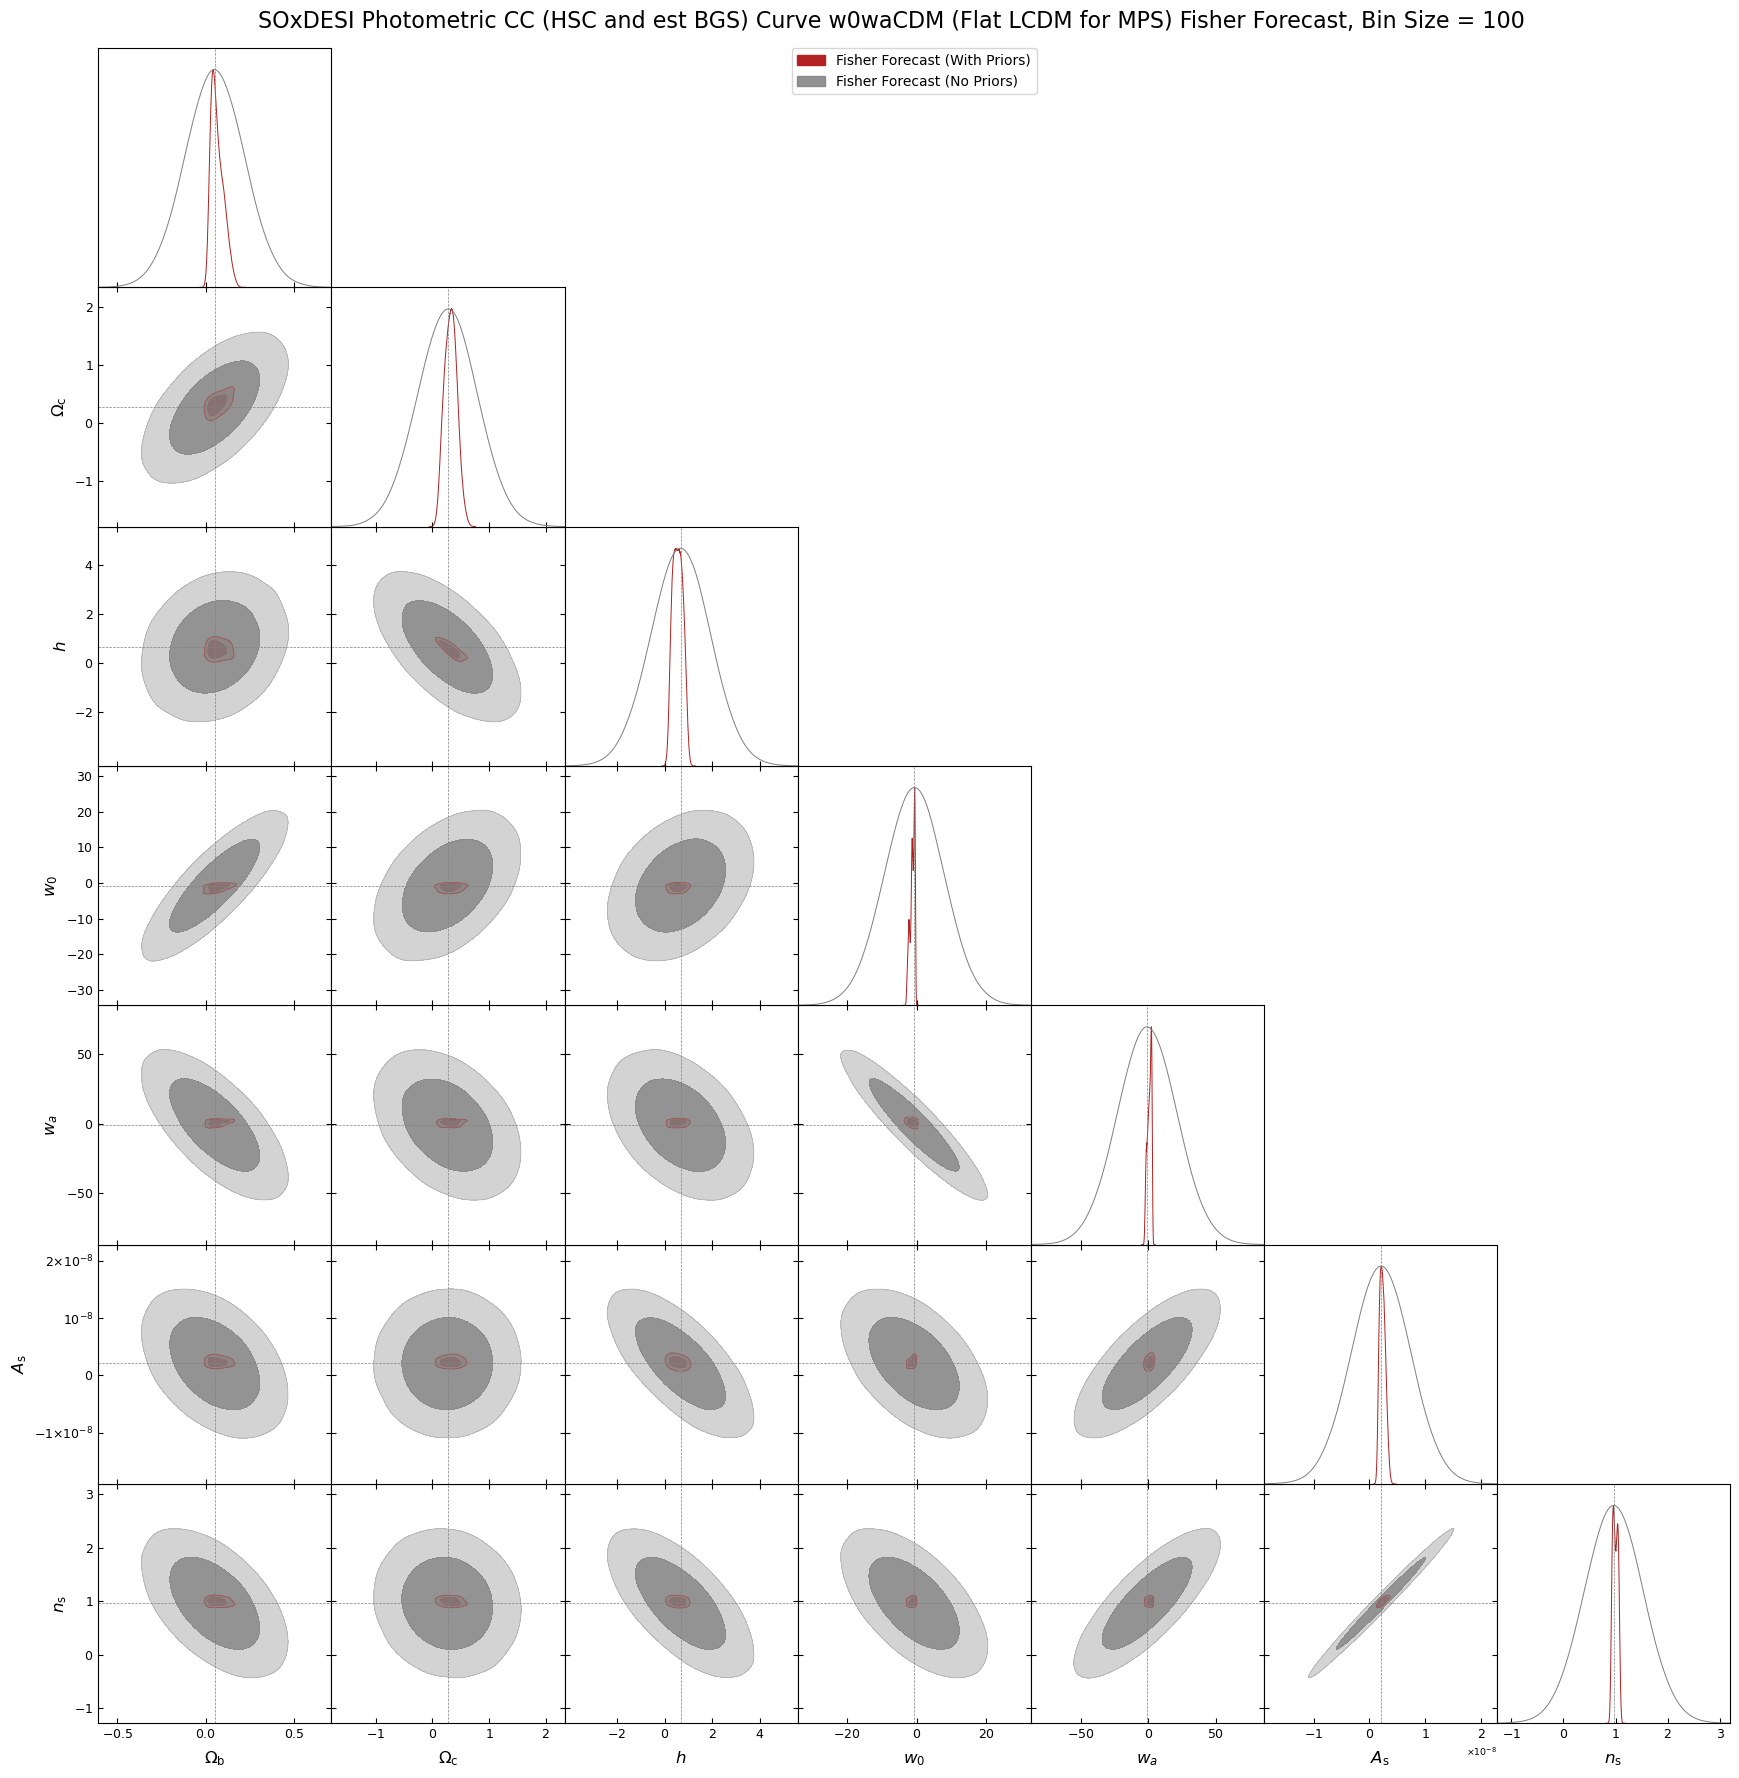

total_time:  0:03:23.655292


In [18]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CC'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CC (HSC and est BGS) Flat w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CC (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.40^{+0.15}_{-0.20}$ | $\Omega_m = 0.40^{+0.32}_{-0.29}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.833$ | $\Omega_m = \Omega_\mathrm{m} < 2.12$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.52^{+0.23}_{-0.29}$ | $h = 0.52^{+0.37}_{-0.35}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 1.6$ | $h = 0.7^{+3.2}_{-3.2}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.46\pm 0.70$ | $w_0 = -1.5^{+1.4}_{-1.4}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1\pm 13$ | $w_0 = -1^{+25}_{-25}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.5^{+2.1}_{-1.5}$ | $w_a = 0.5^{+2.8}_{-3.3}$ |
|  | Fisher Forecast (No Priors) | $w_a = -1\pm 36$ | $w_a = -1^{+71}_{-71}$ |
| --- | --- | --- | --- |

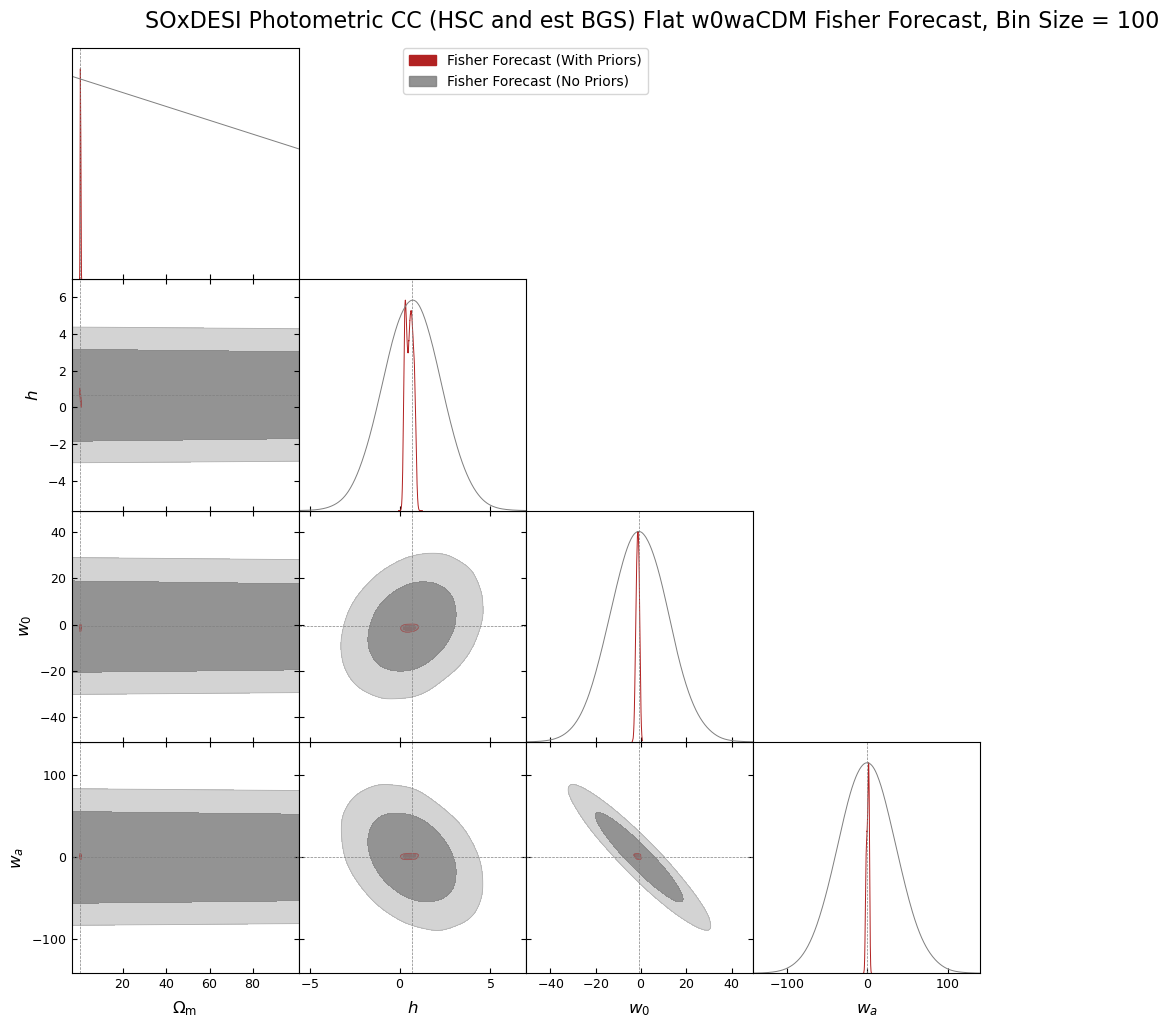

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.066^{+0.032}_{-0.040}$ | $\Omega_{b} = 0.066^{+0.074}_{-0.066}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.05\pm 0.23$ | $\Omega_{b} = 0.05^{+0.45}_{-0.45}$ |
| --- | --- | --- | --- |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.34\pm 0.12$ | $\Omega_{c} = 0.34^{+0.25}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.27\pm 0.86$ | $\Omega_{c} = 0.3^{+1.7}_{-1.7}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.53^{+0.24}_{-0.27}$ | $h = 0.53^{+0.41}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $h = 0.7\pm 1.6$ | $h = 0.7^{+3.2}_{-3.2}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.31^{+1.0}_{-0.51}$ | $w_0 = -1.3^{+1.1}_{-1.4}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1\pm 13$ | $w_0 = -1^{+25}_{-25}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.7^{+2.0}_{-1.3}$ | $w_a = 0.7^{+2.7}_{-3.3}$ |
|  | Fisher Forecast (No Priors) | $w_a = -1\pm 36$ | $w_a = -1^{+71}_{-71}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.21^{+0.41}_{-0.54}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.21^{+0.94}_{-0.83}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1\pm 5.1\,\right)\cdot 10^{-9}$ | $A_s = \left(\,0.2^{+1.0}_{-1.0}\,\right)\cdot 10^{-8}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.999\pm 0.054$ | $n_s = 0.999^{+0.093}_{-0.097}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.96\pm 0.62$ | $n_s = 0.96^{+1.2}_{-1.2}$ |
| --- | --- | --- | --- |

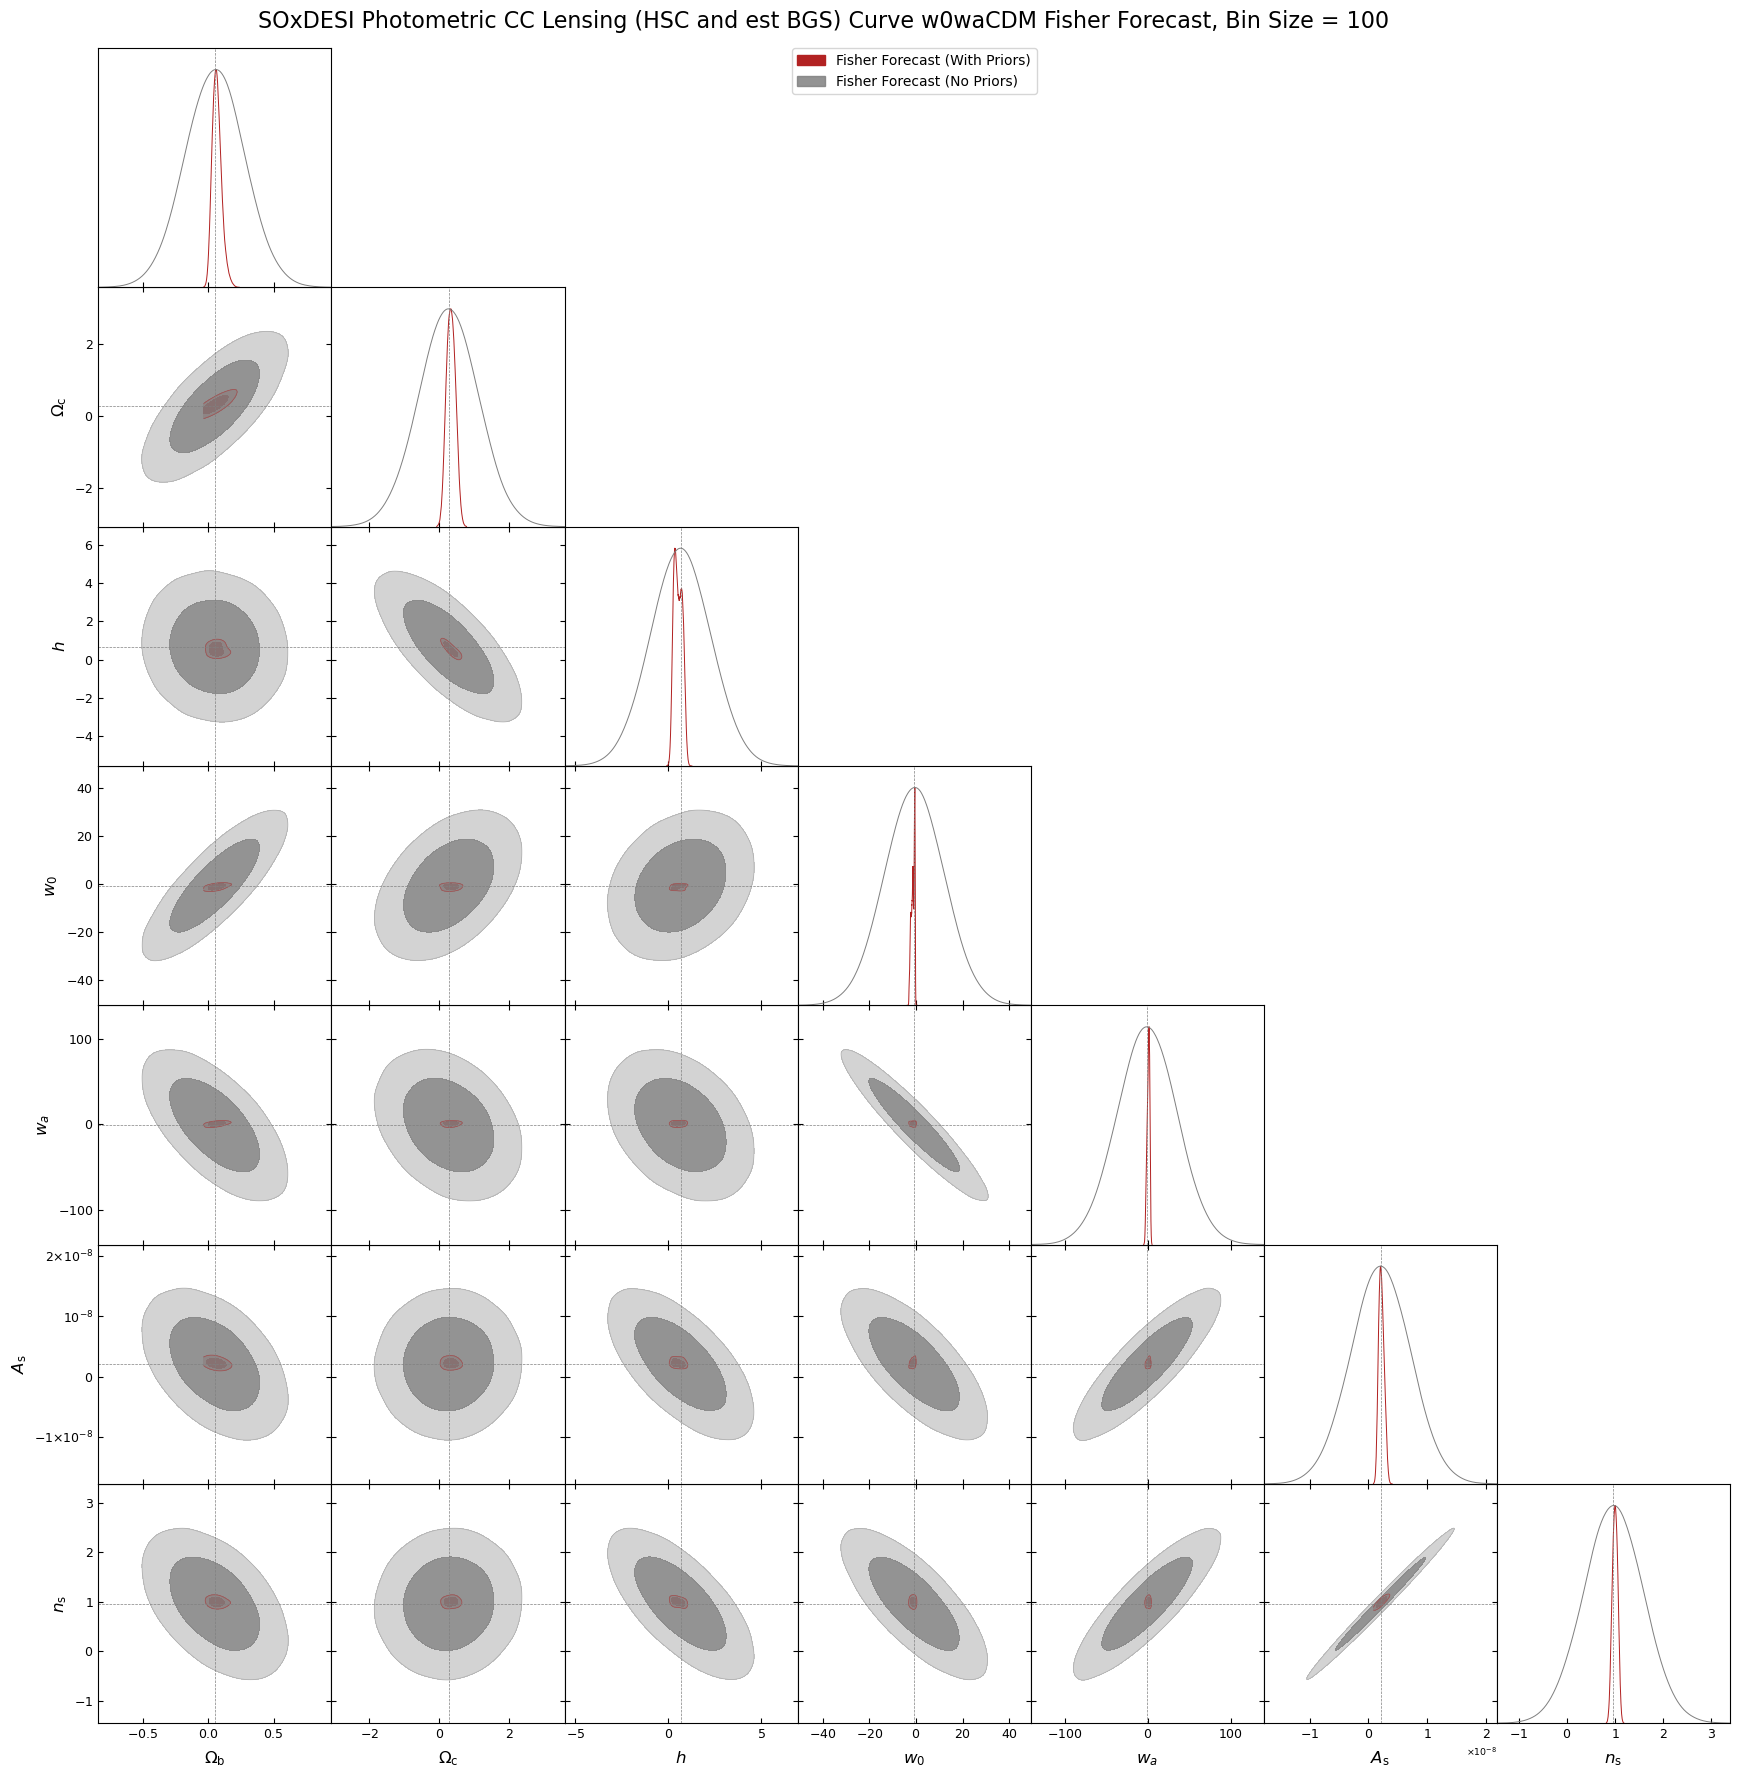

total_time:  0:03:26.837428


In [19]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CC'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'Omega_c', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CC (HSC and est BGS) Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric CC Lensing (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat LCDM -- FULLY FIXED P(k)

#### Lensing Ratios

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3027\pm 0.0033$ | $\Omega_m = 0.3027^{+0.0064}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3027\pm 0.0033$ | $\Omega_m = 0.3027^{+0.0064}_{-0.0064}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0044$ | $h = 0.6817^{+0.0087}_{-0.0087}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0044$ | $h = 0.6817^{+0.0087}_{-0.0087}$ |
| --- | --- | --- | --- |

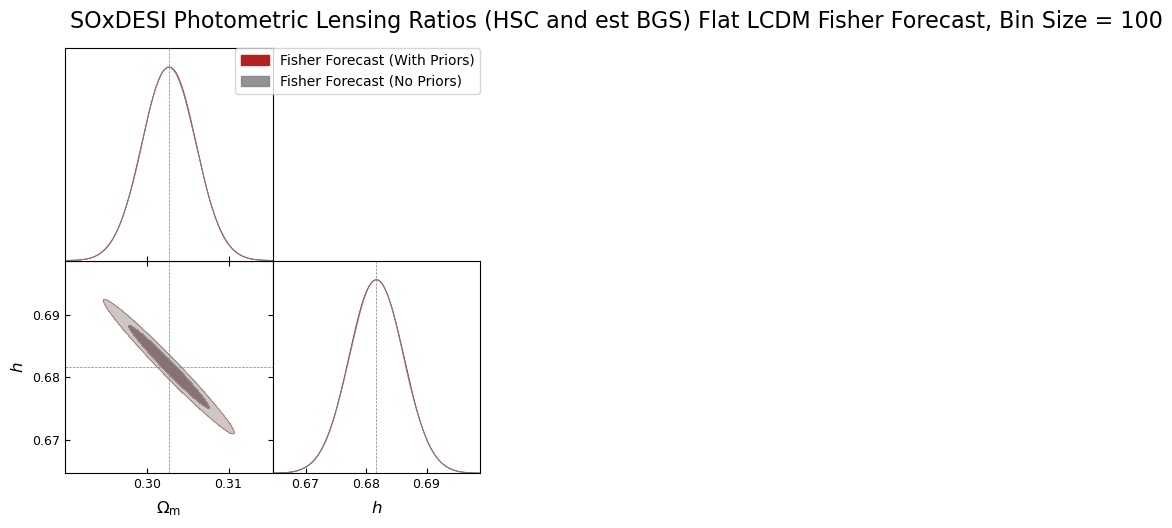

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_(lrg_and_est_bgs)_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100_--_all_sampled_params_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.0481\pm 0.0033$ | $\Omega_{b} = 0.0481^{+0.0064}_{-0.0064}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.0481\pm 0.0033$ | $\Omega_{b} = 0.0481^{+0.0064}_{-0.0064}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0044$ | $h = 0.6817^{+0.0087}_{-0.0087}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0044$ | $h = 0.6817^{+0.0087}_{-0.0086}$ |
| --- | --- | --- | --- |

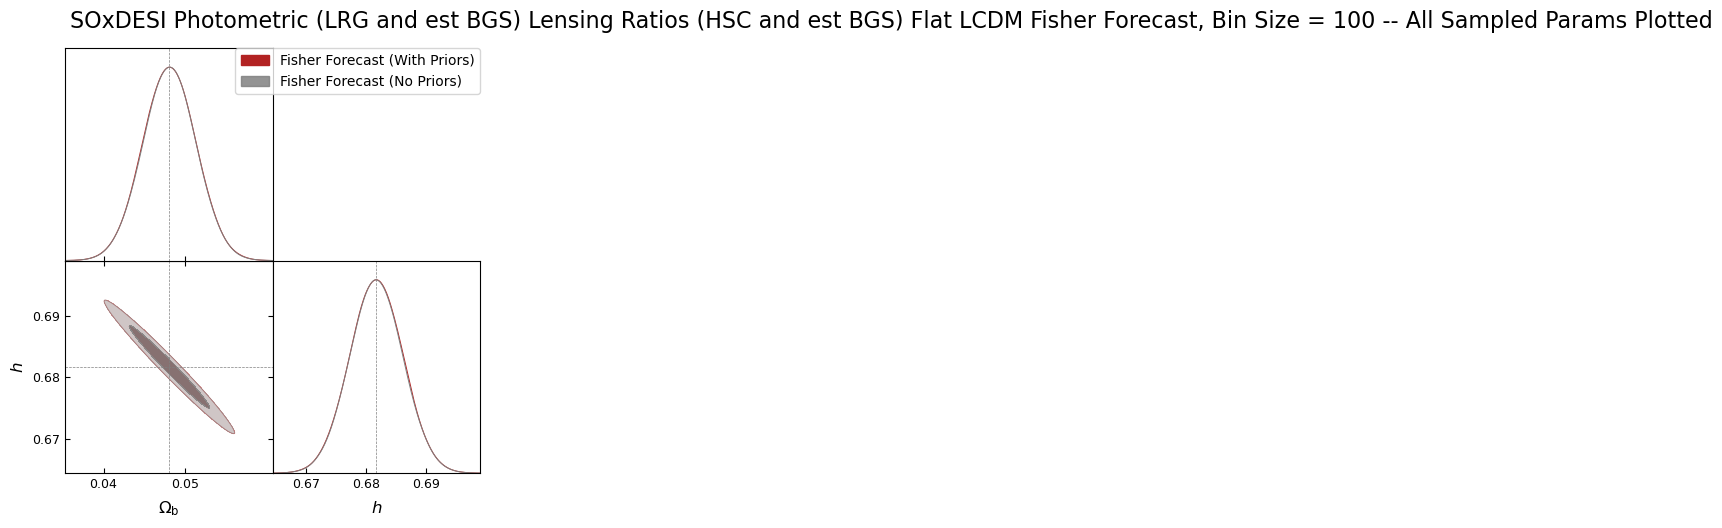

total_time:  0:00:26.828094


In [13]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    matter_power_cosmology = flat_LCDM_cosmology,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)


# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False,
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (LRG and est BGS) Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100 -- All Sampled Params Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3027\pm 0.0032$ | $\Omega_m = 0.3027^{+0.0063}_{-0.0063}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3027\pm 0.0032$ | $\Omega_m = 0.3027^{+0.0062}_{-0.0062}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0043$ | $h = 0.6817^{+0.0084}_{-0.0084}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0043$ | $h = 0.6817^{+0.0084}_{-0.0084}$ |
| --- | --- | --- | --- |

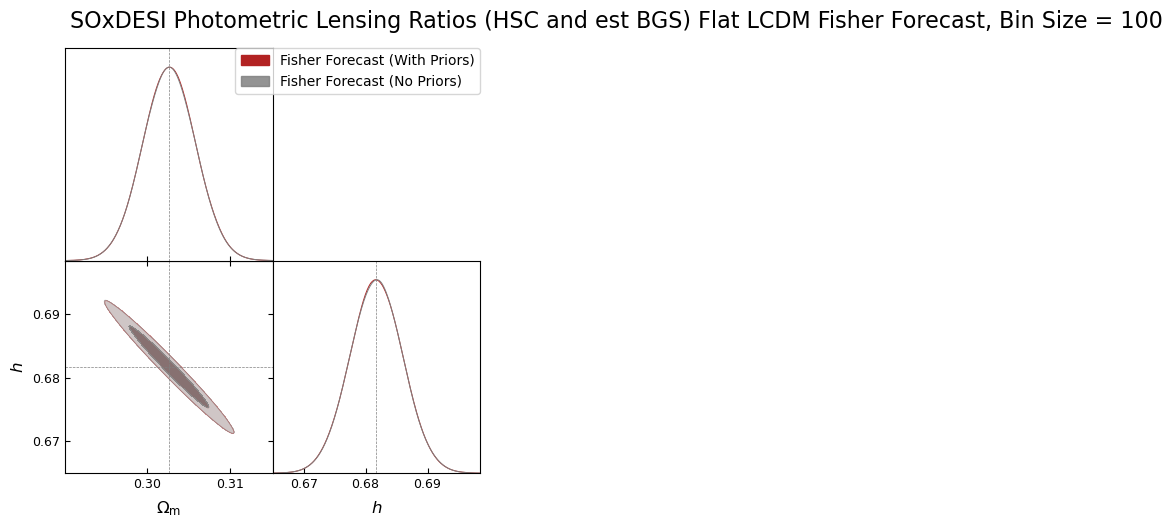

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_(lrg_and_est_bgs)_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100_--_all_sampled_params_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.0481\pm 0.0032$ | $\Omega_{b} = 0.0481^{+0.0062}_{-0.0062}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.0481\pm 0.0032$ | $\Omega_{b} = 0.0481^{+0.0062}_{-0.0062}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0043$ | $h = 0.6817^{+0.0084}_{-0.0084}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0043$ | $h = 0.6817^{+0.0084}_{-0.0085}$ |
| --- | --- | --- | --- |

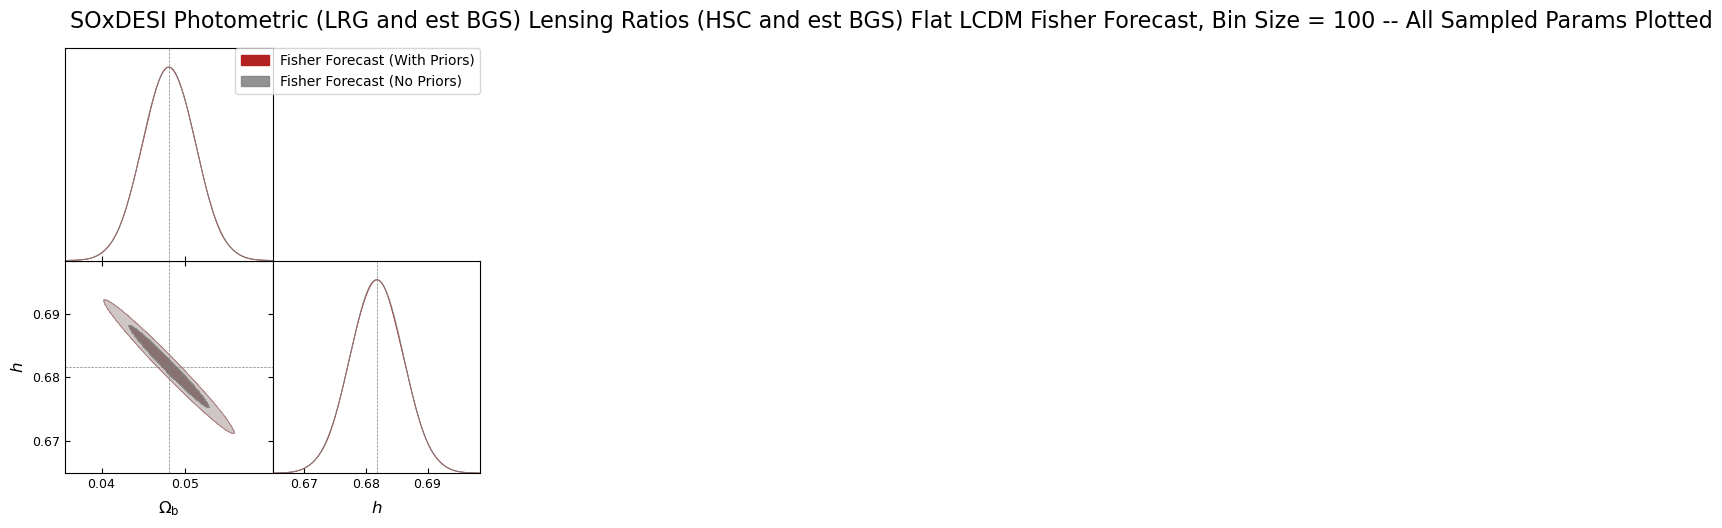

total_time:  0:00:29.451585


In [14]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    matter_power_cosmology = curved_w0waCDM_cosmology,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)


# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False,
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (LRG and est BGS) Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100 -- All Sampled Params Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3027\pm 0.0033$ | $\Omega_m = 0.3027^{+0.0065}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3027\pm 0.0033$ | $\Omega_m = 0.3027^{+0.0065}_{-0.0065}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0045$ | $h = 0.6817^{+0.0088}_{-0.0087}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0045$ | $h = 0.6817^{+0.0088}_{-0.0088}$ |
| --- | --- | --- | --- |

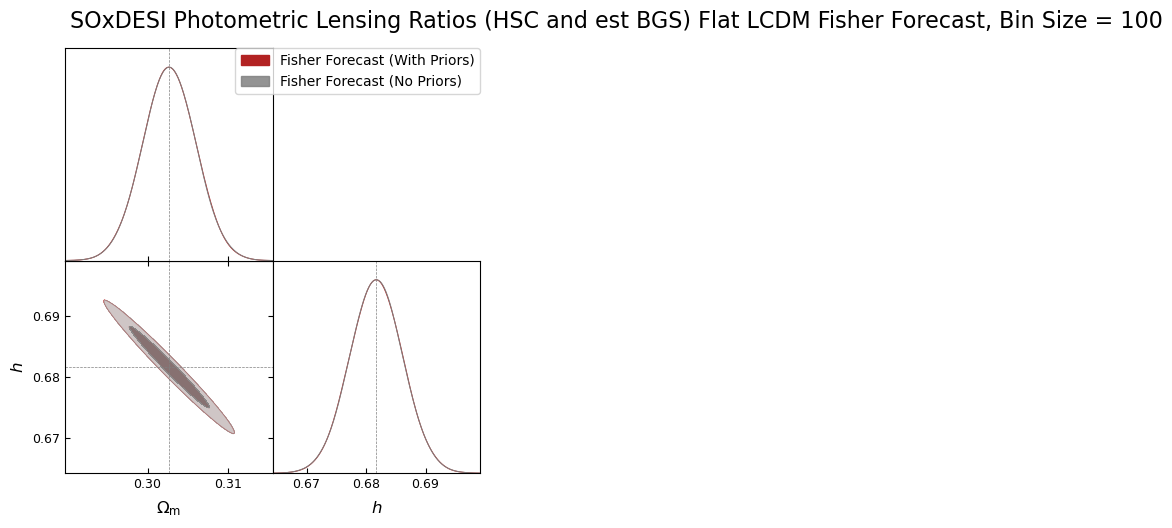

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_(lrg_and_est_bgs)_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_100_--_all_sampled_params_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.0481\pm 0.0033$ | $\Omega_{b} = 0.0481^{+0.0064}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.0481\pm 0.0033$ | $\Omega_{b} = 0.0481^{+0.0064}_{-0.0064}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0044$ | $h = 0.6817^{+0.0087}_{-0.0087}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0045$ | $h = 0.6817^{+0.0087}_{-0.0087}$ |
| --- | --- | --- | --- |

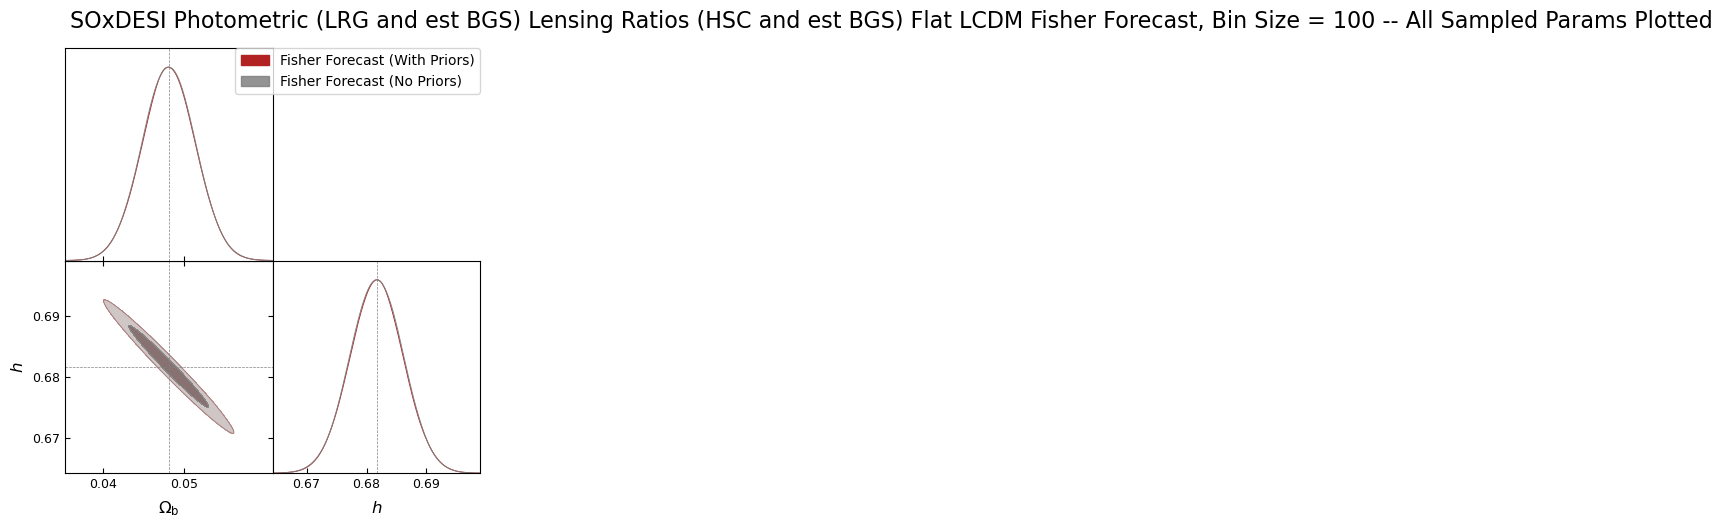

total_time:  0:00:29.216836


In [15]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    matter_power_cosmology = flat_wCDM_cosmology,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)


# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False,
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (LRG and est BGS) Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 100 -- All Sampled Params Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3023\pm 0.0087$ | $\Omega_m = 0.302^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.308$ | $\Omega_m = \Omega_\mathrm{m} < 0.319$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.68^{+0.13}_{-0.15}$ | $h = 0.68^{+0.26}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $h = 0.68\pm 0.23$ | $h = 0.68^{+0.46}_{-0.46}$ |
| --- | --- | --- | --- |

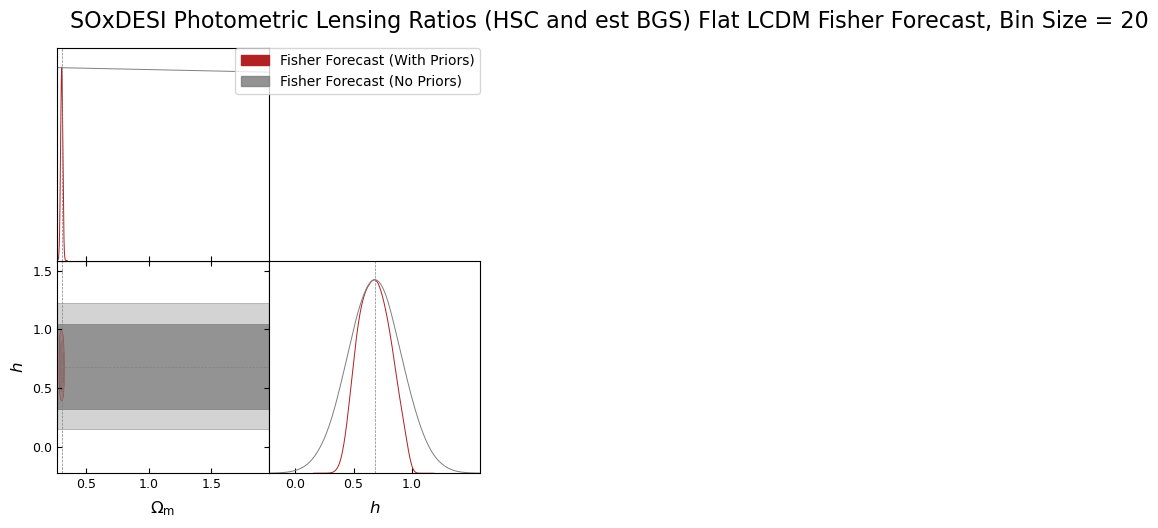

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Plot successfully saved to: plots/Fisher Forecasts/soxdesi_photometric_(lrg_and_est_bgs)_lensing_ratios_(hsc_and_est_bgs)_flat_lcdm_fisher_forecast_bin_size_=_20_--_all_sampled_params_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.250^{+0.030}_{-0.020}$ | $\Omega_{c} = 0.250^{+0.043}_{-0.048}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.253\pm 0.038$ | $\Omega_{c} = 0.253^{+0.074}_{-0.074}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.050^{+0.017}_{-0.032}$ | $\Omega_{b} = 0.050^{+0.043}_{-0.039}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.048\pm 0.039$ | $\Omega_{b} = 0.048^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.68^{+0.13}_{-0.15}$ | $h = 0.68^{+0.26}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $h = 0.68\pm 0.23$ | $h = 0.68^{+0.46}_{-0.46}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.19^{+0.27}_{-0.59}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.19^{+0.77}_{-0.70}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.12\pm 0.68\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1^{+1.3}_{-1.3}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.972^{+0.025}_{-0.036}$ | $n_s = 0.972^{+0.055}_{-0.052}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.969\pm 0.050$ | $n_s = 0.969^{+0.097}_{-0.097}$ |
| --- | --- | --- | --- |

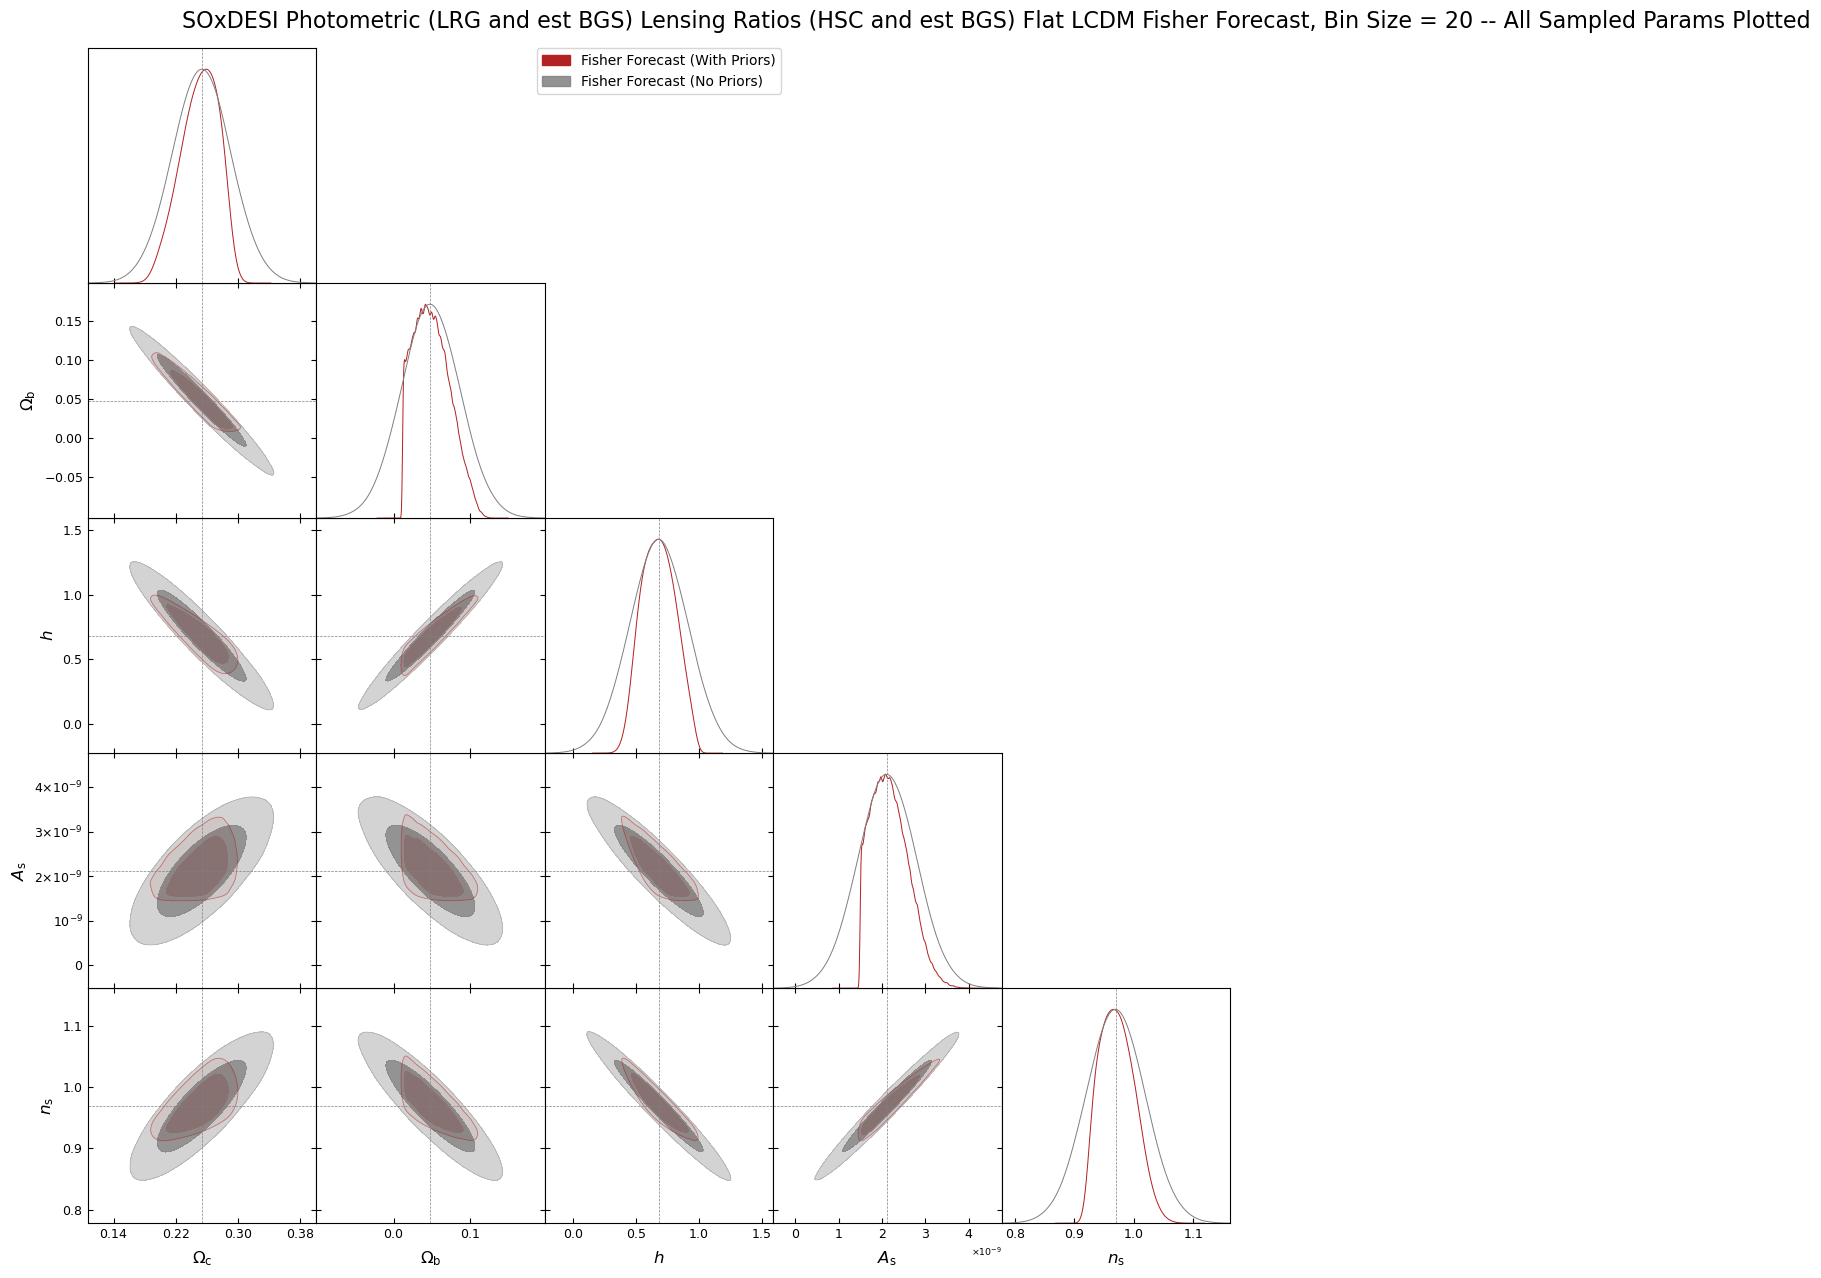

total_time:  0:02:06.145720


In [12]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    matter_power_cosmology = None,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_Photo_BGS_HSC_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_Photo_BGS_HSC_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False,
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (LRG and est BGS) Lensing Ratios (HSC and est BGS) Flat LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Params Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat w0waCDM -- FULLY FIXED P(k)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00021$ | $\Omega_{b} = 0.04991^{+0.00041}_{-0.00041}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00021$ | $\Omega_{b} = 0.04991^{+0.00041}_{-0.00041}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.66740\pm 0.00081$ | $h = 0.6674^{+0.0016}_{-0.0016}$ |
|  | Fisher Forecast (No Priors) | $h = 0.66740\pm 0.00081$ | $h = 0.6674^{+0.0016}_{-0.0016}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.089}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.39}_{-0.39}$ |
| --- | --- | --- | --- |

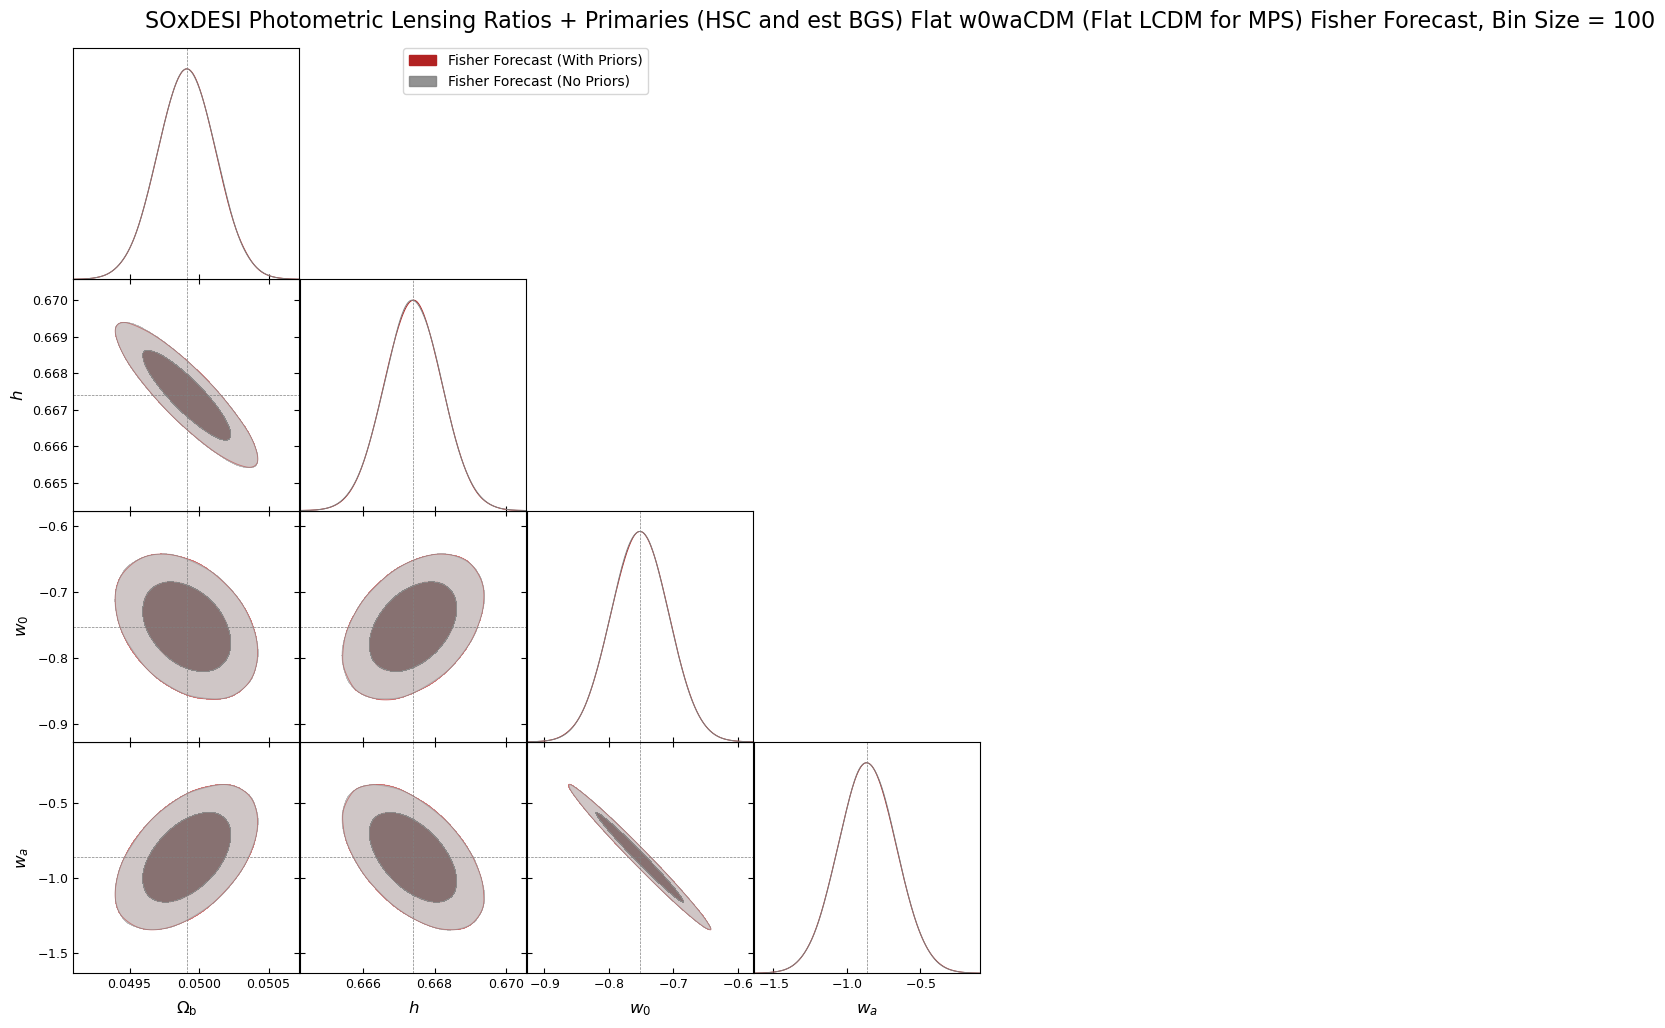

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00021$ | $\Omega_{b} = 0.04991^{+0.00041}_{-0.00041}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00021$ | $\Omega_{b} = 0.04991^{+0.00041}_{-0.00041}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.66740\pm 0.00081$ | $h = 0.6674^{+0.0016}_{-0.0016}$ |
|  | Fisher Forecast (No Priors) | $h = 0.66740\pm 0.00081$ | $h = 0.6674^{+0.0016}_{-0.0016}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.089}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.39}_{-0.38}$ |
| --- | --- | --- | --- |

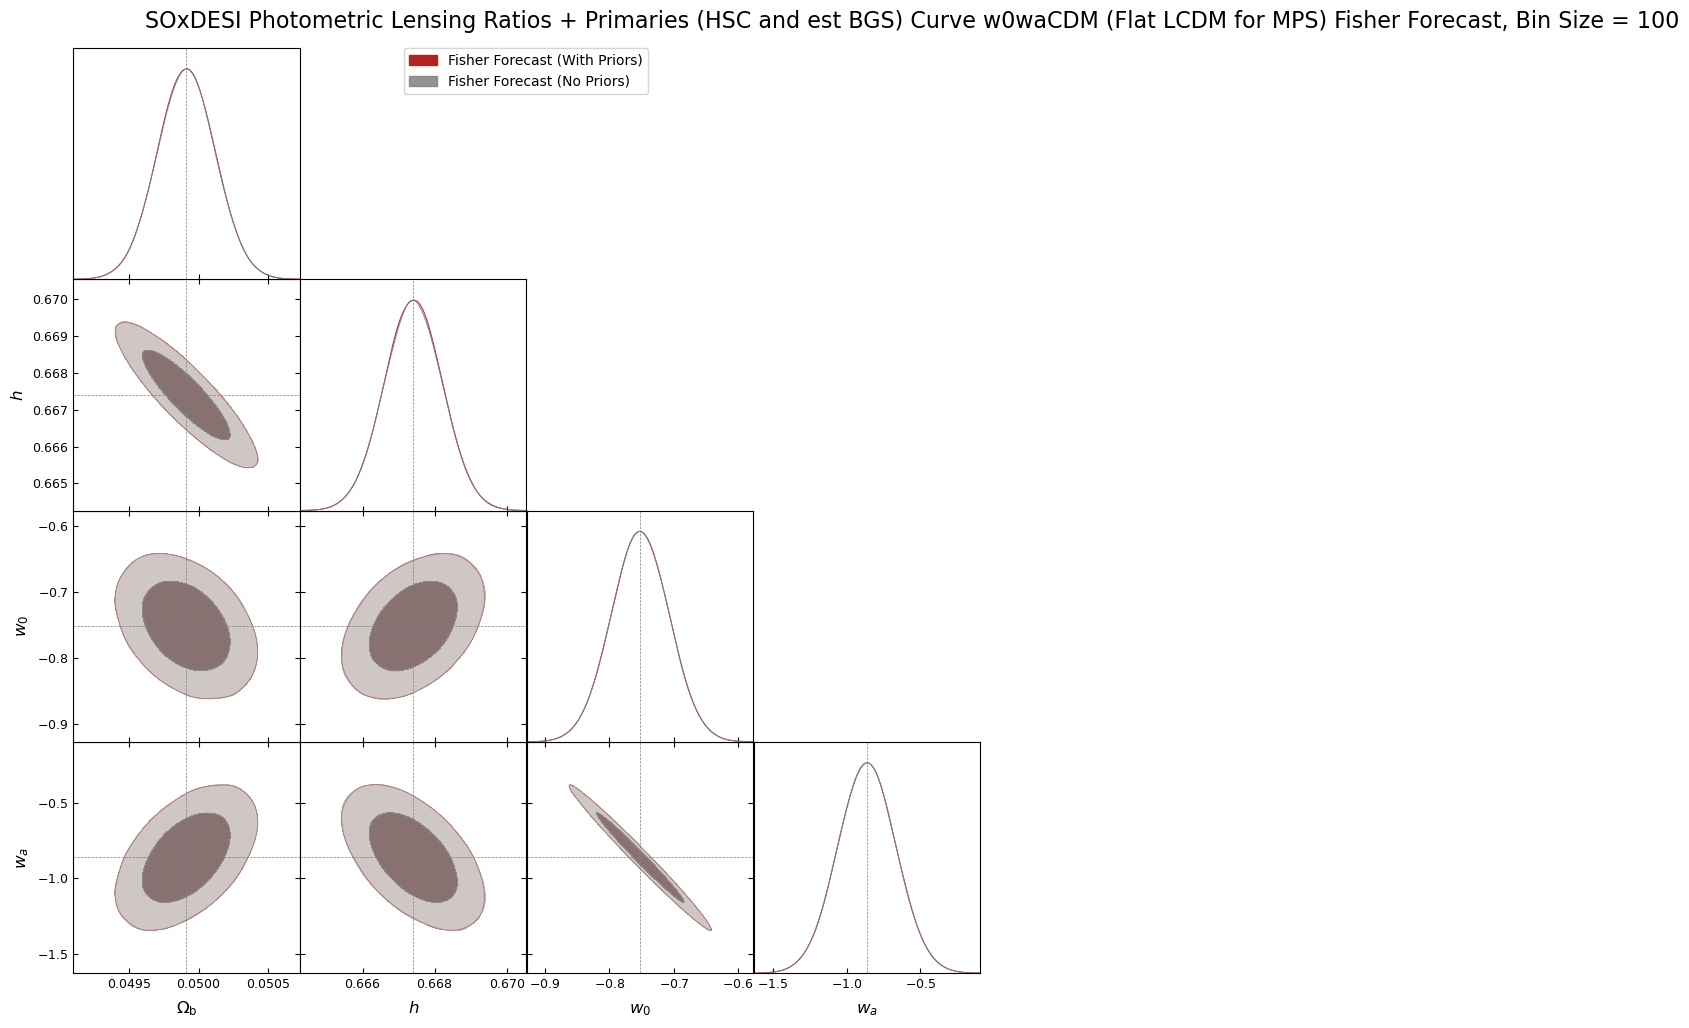

total_time:  0:01:41.449976


In [25]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Flat w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00014$ | $\Omega_{b} = 0.04991^{+0.00027}_{-0.00028}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00014$ | $\Omega_{b} = 0.04991^{+0.00027}_{-0.00028}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.66740\pm 0.00062$ | $h = 0.6674^{+0.0012}_{-0.0012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.66740\pm 0.00061$ | $h = 0.6674^{+0.0012}_{-0.0012}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.035$ | $w_0 = -0.752^{+0.069}_{-0.069}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.035$ | $w_0 = -0.752^{+0.069}_{-0.069}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.12$ | $w_a = -0.86^{+0.24}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.12$ | $w_a = -0.86^{+0.24}_{-0.24}$ |
| --- | --- | --- | --- |

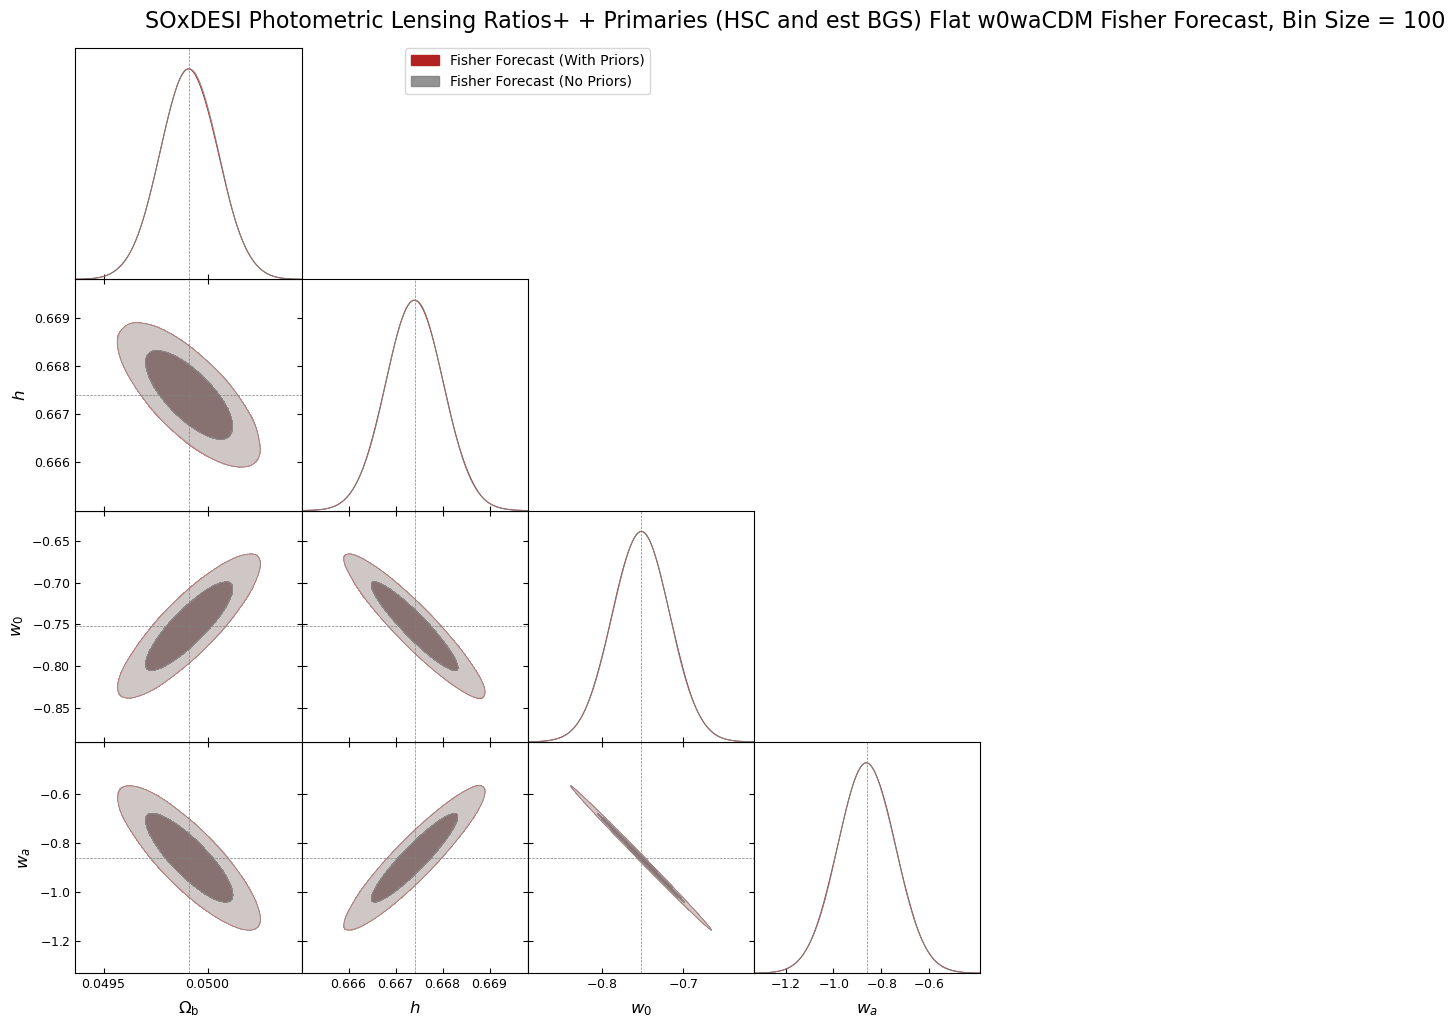

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00014$ | $\Omega_{b} = 0.04991^{+0.00027}_{-0.00027}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00014$ | $\Omega_{b} = 0.04991^{+0.00027}_{-0.00027}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.66740\pm 0.00061$ | $h = 0.6674^{+0.0012}_{-0.0012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.66740\pm 0.00061$ | $h = 0.6674^{+0.0012}_{-0.0012}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.035$ | $w_0 = -0.752^{+0.069}_{-0.069}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.035$ | $w_0 = -0.752^{+0.070}_{-0.069}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.12$ | $w_a = -0.86^{+0.24}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.12$ | $w_a = -0.86^{+0.24}_{-0.24}$ |
| --- | --- | --- | --- |

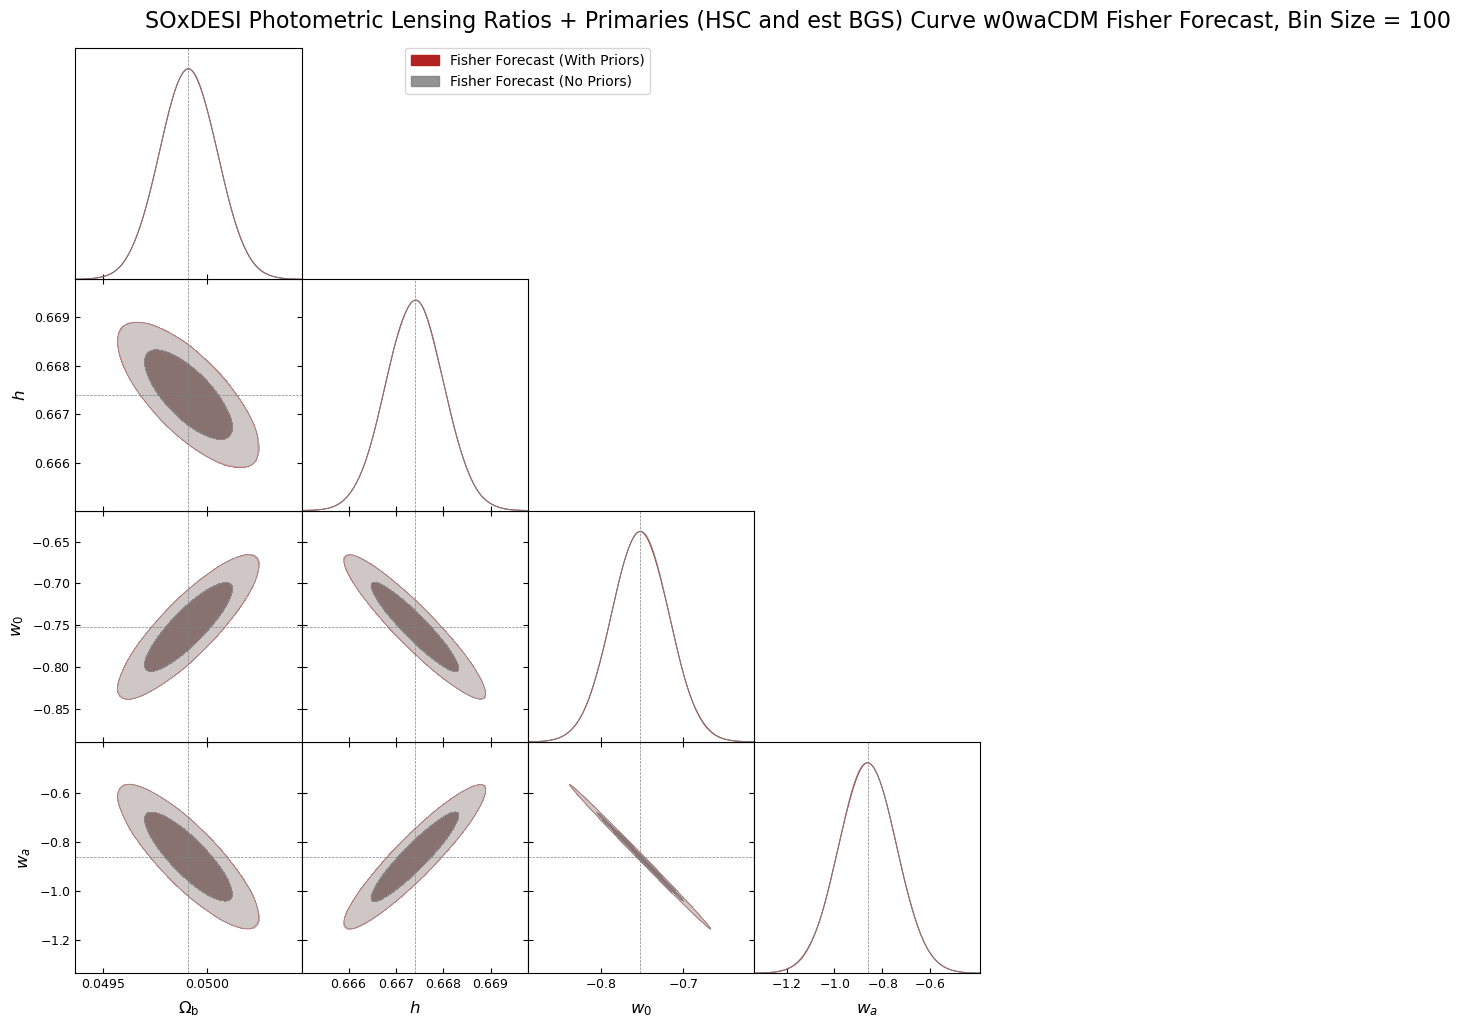

total_time:  0:02:09.086445


In [27]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios+ + Primaries (HSC and est BGS) Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Curved w0waCDM -- FULLY FIXED P(k)

#### Lensing Ratios

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.049^{+0.013}_{-0.011}$ | $\Omega_{b} = 0.049^{+0.022}_{-0.024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.013$ | $\Omega_{b} = 0.050^{+0.025}_{-0.025}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.669^{+0.011}_{-0.013}$ | $h = 0.669^{+0.024}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.013$ | $h = 0.668^{+0.025}_{-0.025}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.002\pm 0.052$ | $\Omega_k = 0.00^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.054$ | $\Omega_k = 0.00^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.23}_{-0.20}$ | $w_0 = -0.78^{+0.39}_{-0.40}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.76\pm 0.23$ | $w_0 = -0.76^{+0.44}_{-0.45}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.7^{+1.0}_{-1.2}$ | $w_a = -0.7^{+2.0}_{-2.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 1.2$ | $w_a = -0.8^{+2.3}_{-2.3}$ |
| --- | --- | --- | --- |

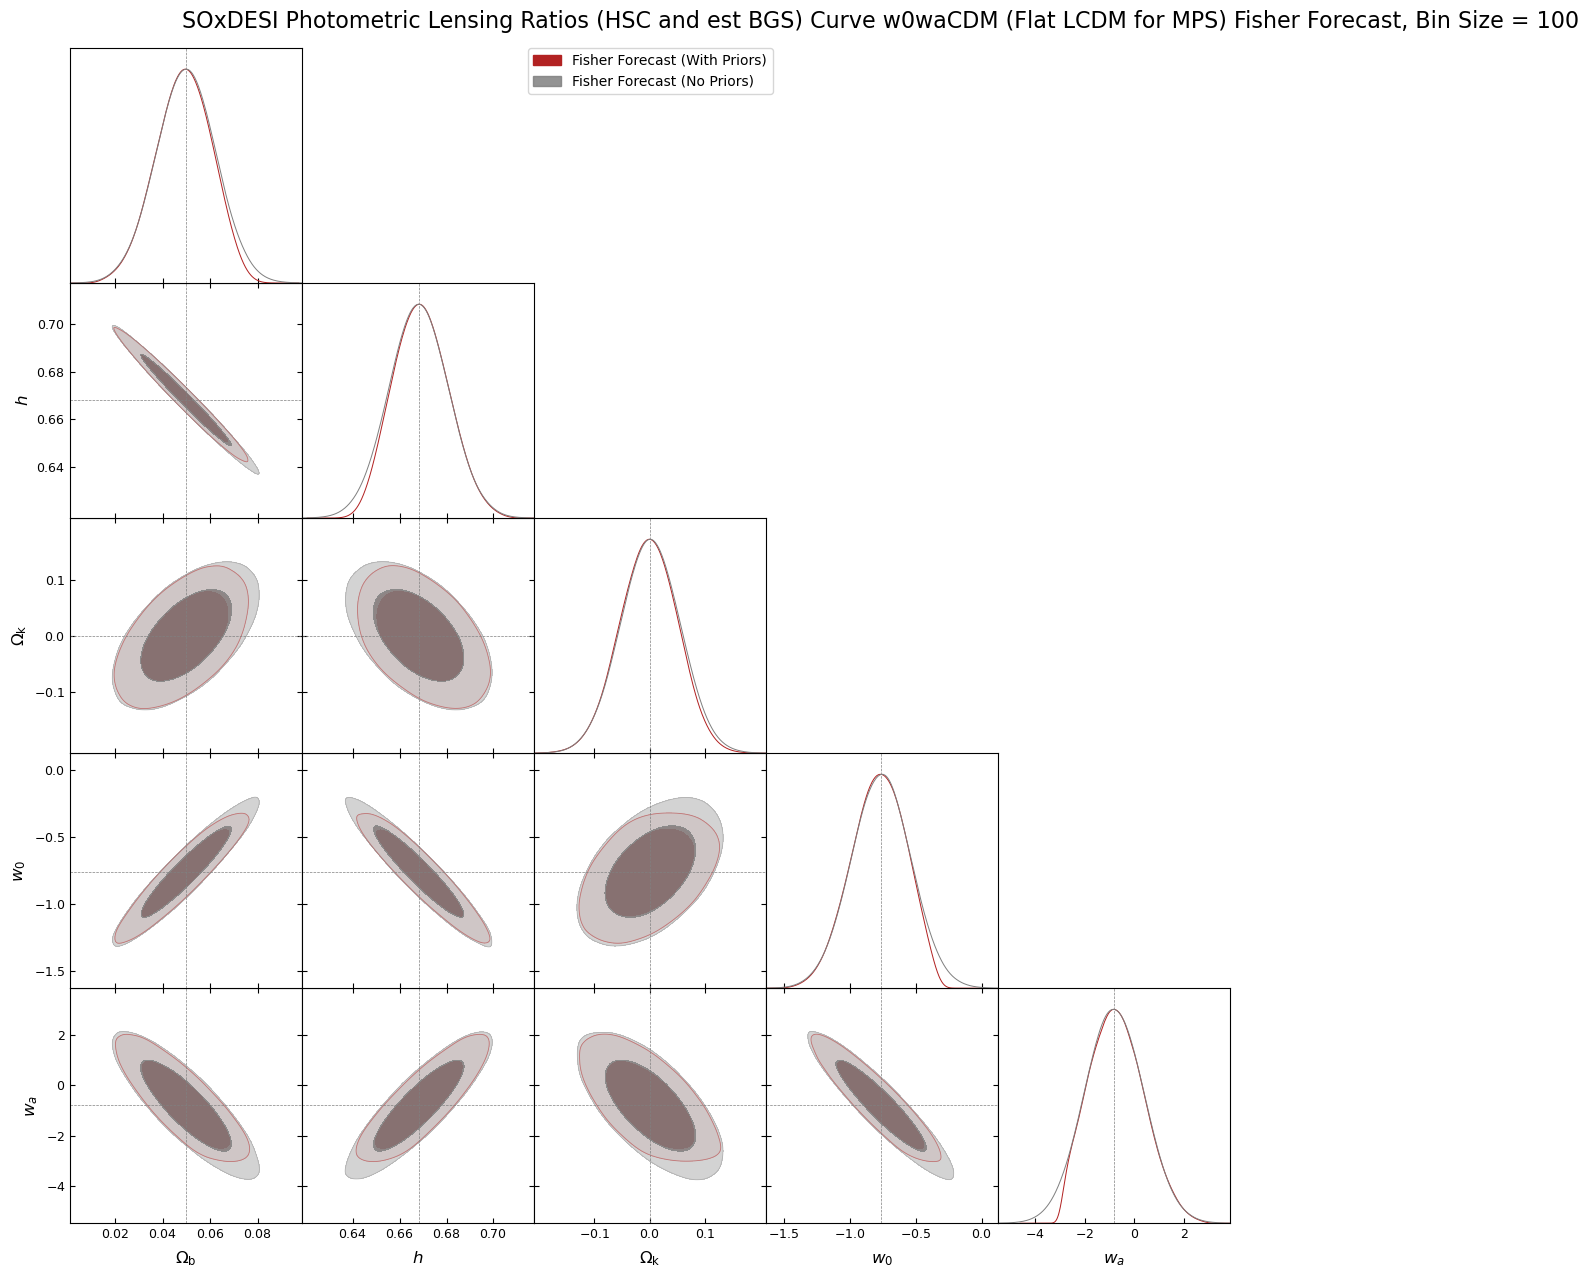

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.049^{+0.013}_{-0.011}$ | $\Omega_{b} = 0.049^{+0.022}_{-0.024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.013$ | $\Omega_{b} = 0.050^{+0.025}_{-0.025}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.669^{+0.011}_{-0.013}$ | $h = 0.669^{+0.024}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.013$ | $h = 0.668^{+0.025}_{-0.025}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.002\pm 0.052$ | $\Omega_k = 0.00^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.054$ | $\Omega_k = 0.00^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.23}_{-0.19}$ | $w_0 = -0.78^{+0.39}_{-0.40}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.76\pm 0.23$ | $w_0 = -0.76^{+0.44}_{-0.44}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.7^{+1.0}_{-1.2}$ | $w_a = -0.7^{+2.0}_{-2.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 1.2$ | $w_a = -0.8^{+2.3}_{-2.4}$ |
| --- | --- | --- | --- |

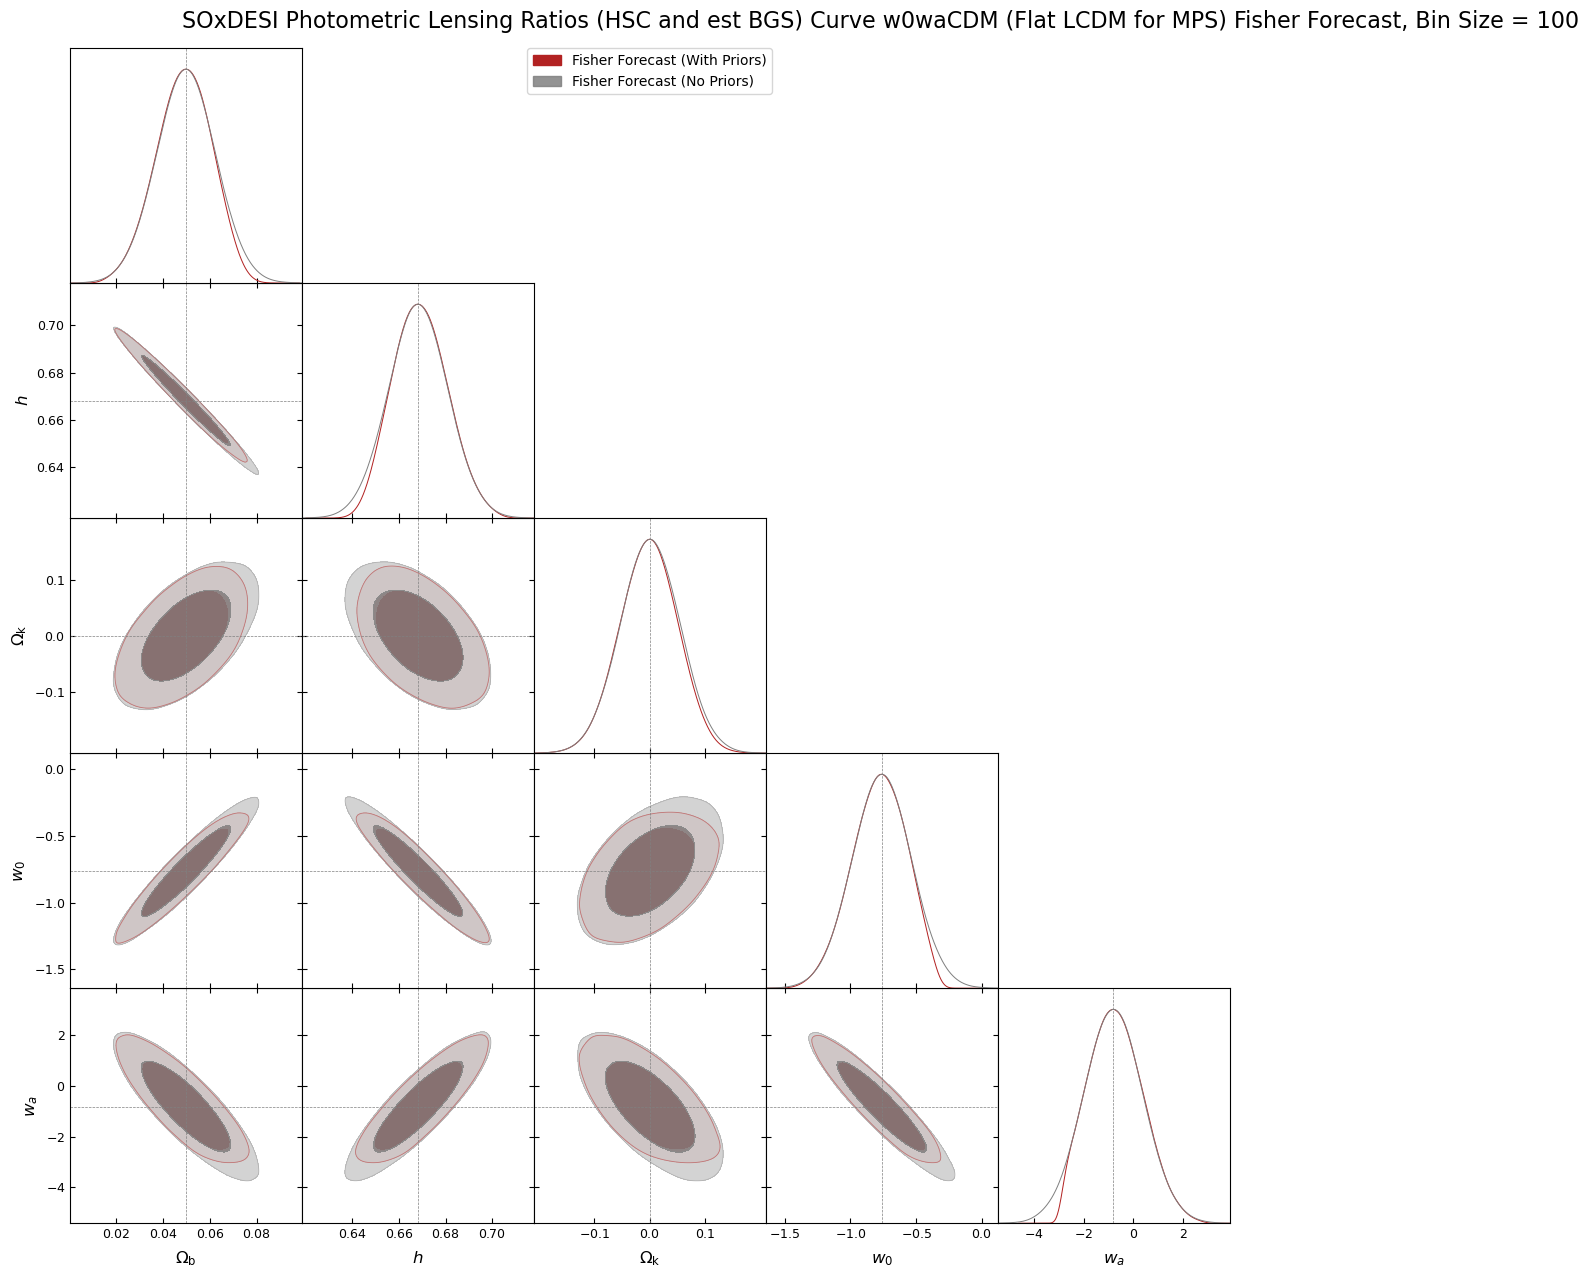

total_time:  0:01:01.745584


In [19]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.050\pm 0.011$ | $\Omega_{b} = 0.050^{+0.021}_{-0.021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.011$ | $\Omega_{b} = 0.050^{+0.021}_{-0.021}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.668\pm 0.023$ | $h = 0.668^{+0.046}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.023$ | $h = 0.668^{+0.046}_{-0.046}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.001\pm 0.026$ | $\Omega_k = 0.001^{+0.051}_{-0.051}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.026$ | $\Omega_k = 0.001^{+0.051}_{-0.051}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.097$ | $w_0 = -0.76^{+0.19}_{-0.19}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.098$ | $w_0 = -0.76^{+0.19}_{-0.19}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.80\pm 0.66$ | $w_a = -0.8^{+1.3}_{-1.3}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.66$ | $w_a = -0.8^{+1.3}_{-1.3}$ |
| --- | --- | --- | --- |

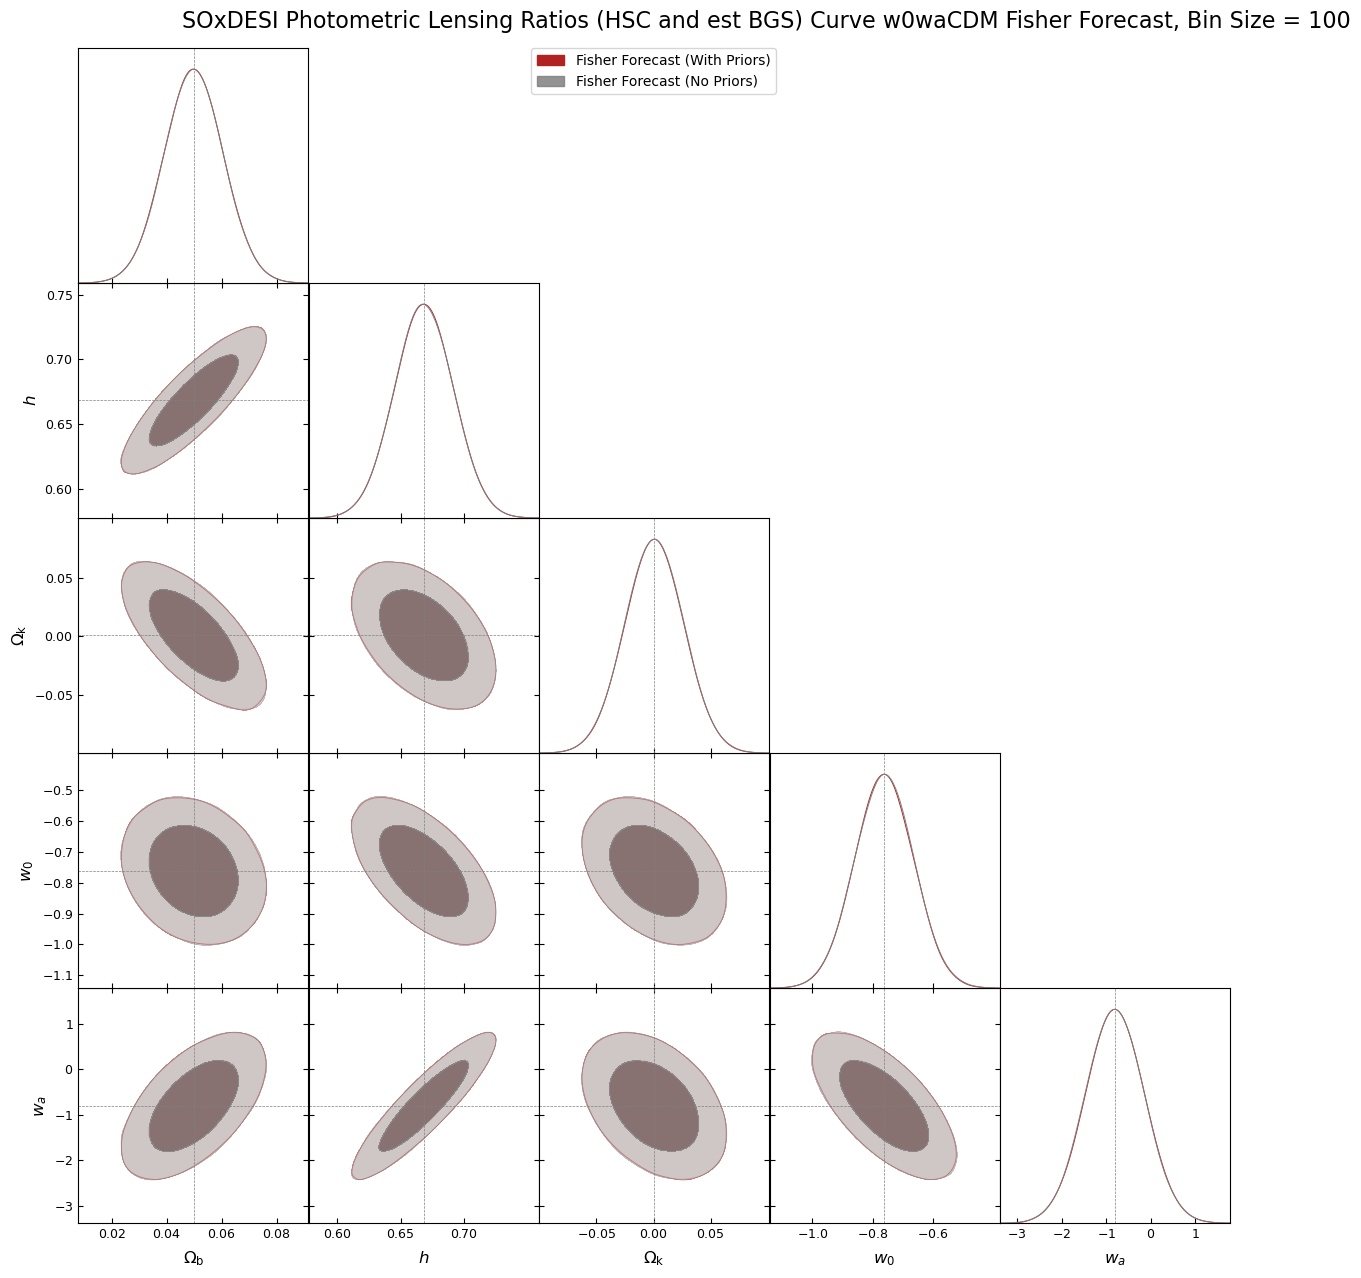

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.050\pm 0.011$ | $\Omega_{b} = 0.050^{+0.021}_{-0.021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.011$ | $\Omega_{b} = 0.050^{+0.021}_{-0.021}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.668\pm 0.023$ | $h = 0.668^{+0.045}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.023$ | $h = 0.668^{+0.045}_{-0.046}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.001\pm 0.026$ | $\Omega_k = 0.001^{+0.051}_{-0.050}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.026$ | $\Omega_k = 0.001^{+0.051}_{-0.051}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.098$ | $w_0 = -0.76^{+0.19}_{-0.19}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.098$ | $w_0 = -0.76^{+0.19}_{-0.19}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.81\pm 0.66$ | $w_a = -0.8^{+1.3}_{-1.3}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.66$ | $w_a = -0.8^{+1.3}_{-1.3}$ |
| --- | --- | --- | --- |

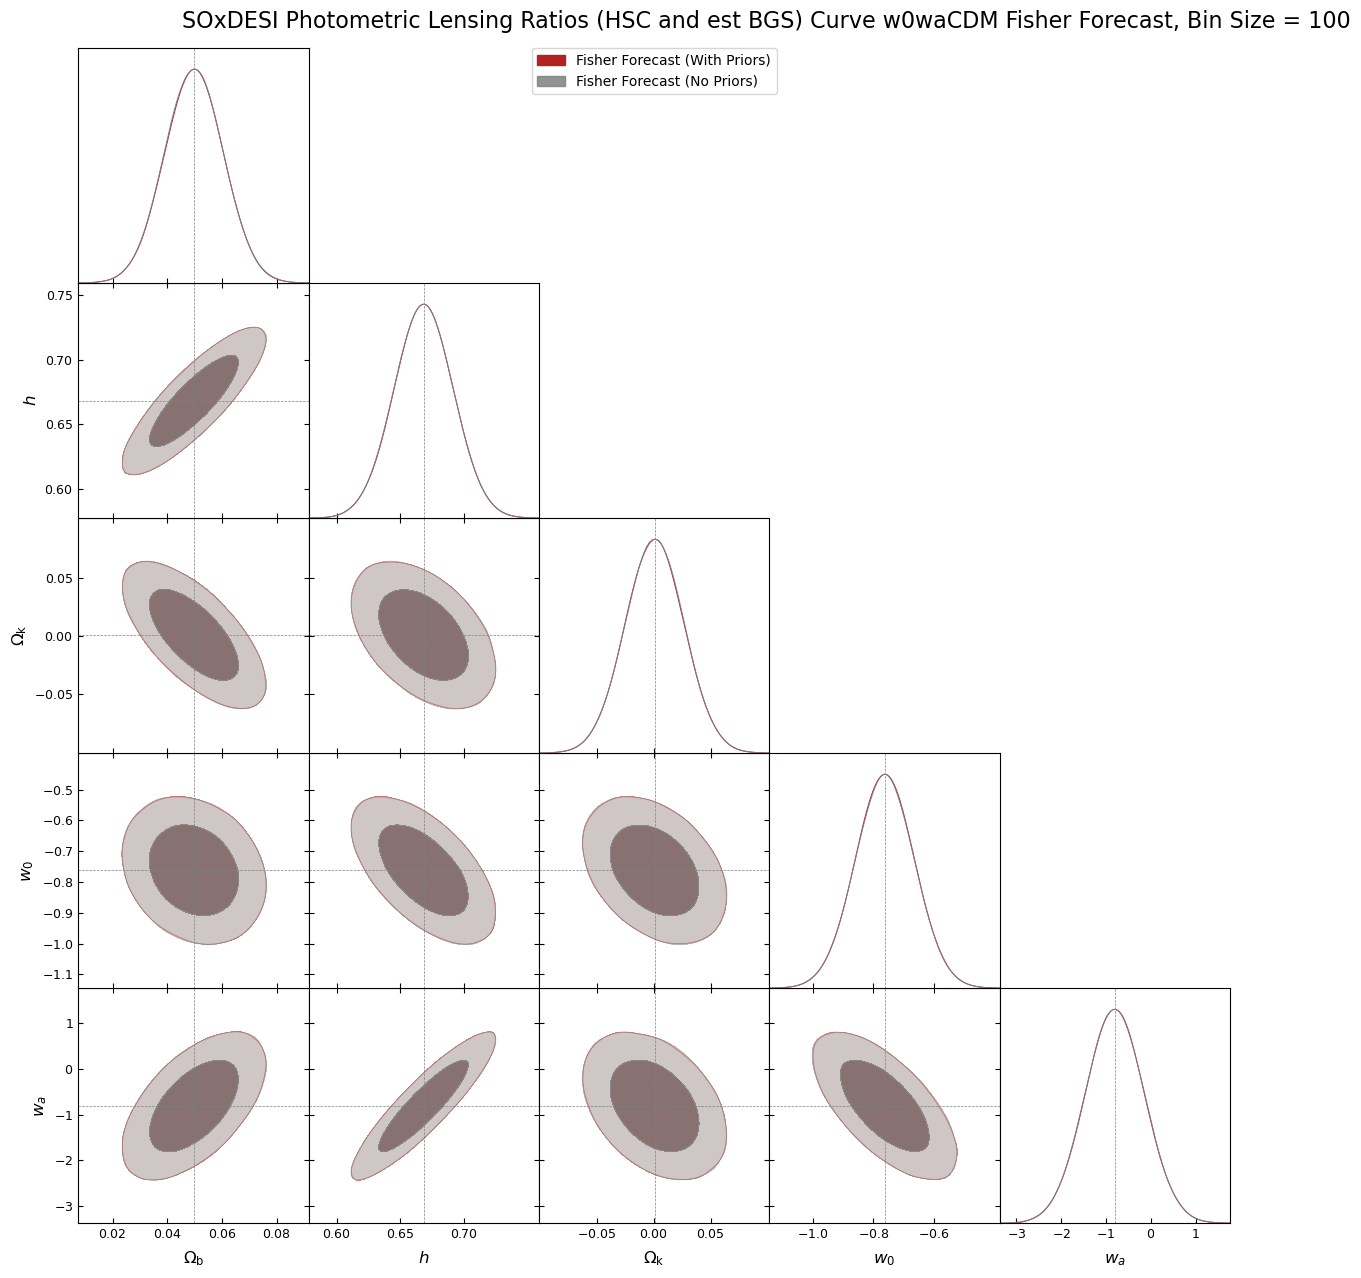

total_time:  0:01:31.307717


In [20]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.049^{+0.012}_{-0.011}$ | $\Omega_{b} = 0.049^{+0.022}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.012$ | $\Omega_{b} = 0.050^{+0.024}_{-0.024}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.669^{+0.011}_{-0.013}$ | $h = 0.669^{+0.023}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.012$ | $h = 0.668^{+0.024}_{-0.024}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.002\pm 0.051$ | $\Omega_k = -0.002^{+0.098}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.053$ | $\Omega_k = 0.00^{+0.10}_{-0.10}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.22}_{-0.19}$ | $w_0 = -0.78^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.76\pm 0.22$ | $w_0 = -0.76^{+0.43}_{-0.43}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.7^{+1.0}_{-1.2}$ | $w_a = -0.7^{+2.0}_{-2.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 1.2$ | $w_a = -0.8^{+2.3}_{-2.3}$ |
| --- | --- | --- | --- |

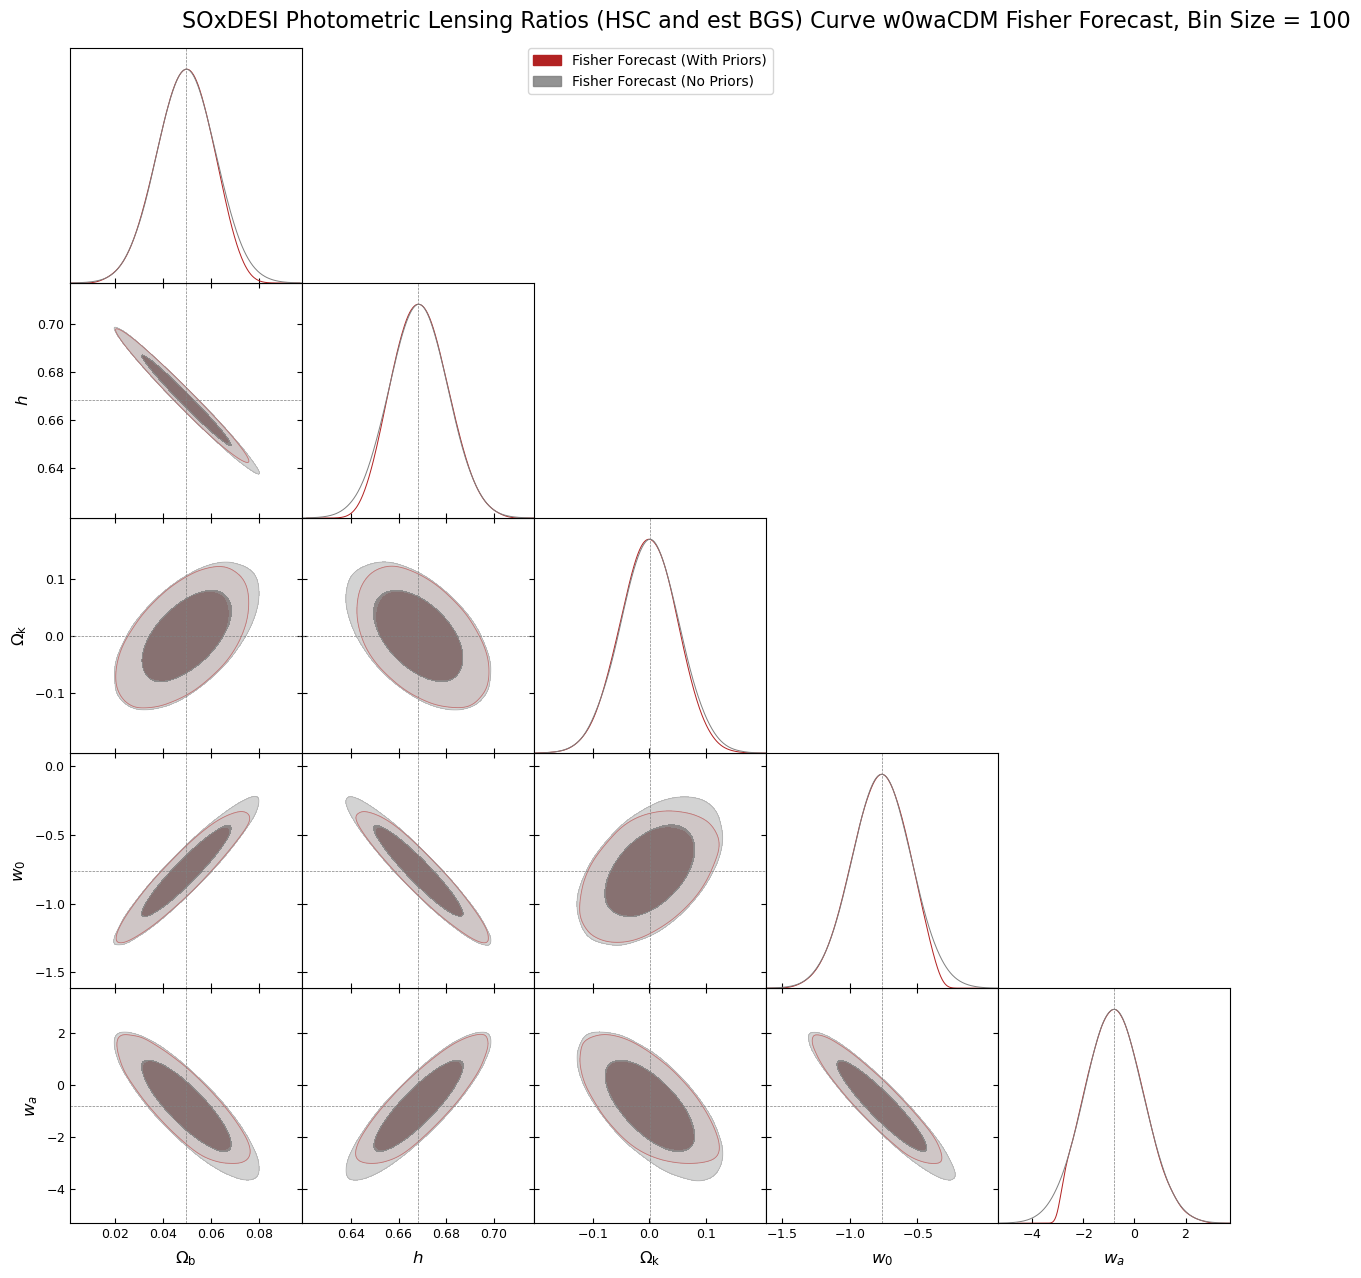

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.049^{+0.012}_{-0.011}$ | $\Omega_{b} = 0.049^{+0.022}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.012$ | $\Omega_{b} = 0.050^{+0.024}_{-0.024}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.669^{+0.011}_{-0.012}$ | $h = 0.669^{+0.023}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.012$ | $h = 0.668^{+0.024}_{-0.024}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.002\pm 0.051$ | $\Omega_k = -0.002^{+0.098}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.001\pm 0.052$ | $\Omega_k = 0.00^{+0.10}_{-0.10}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.22}_{-0.19}$ | $w_0 = -0.78^{+0.39}_{-0.39}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.76\pm 0.22$ | $w_0 = -0.76^{+0.43}_{-0.43}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.7^{+1.0}_{-1.2}$ | $w_a = -0.7^{+2.0}_{-2.0}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 1.2$ | $w_a = -0.8^{+2.3}_{-2.3}$ |
| --- | --- | --- | --- |

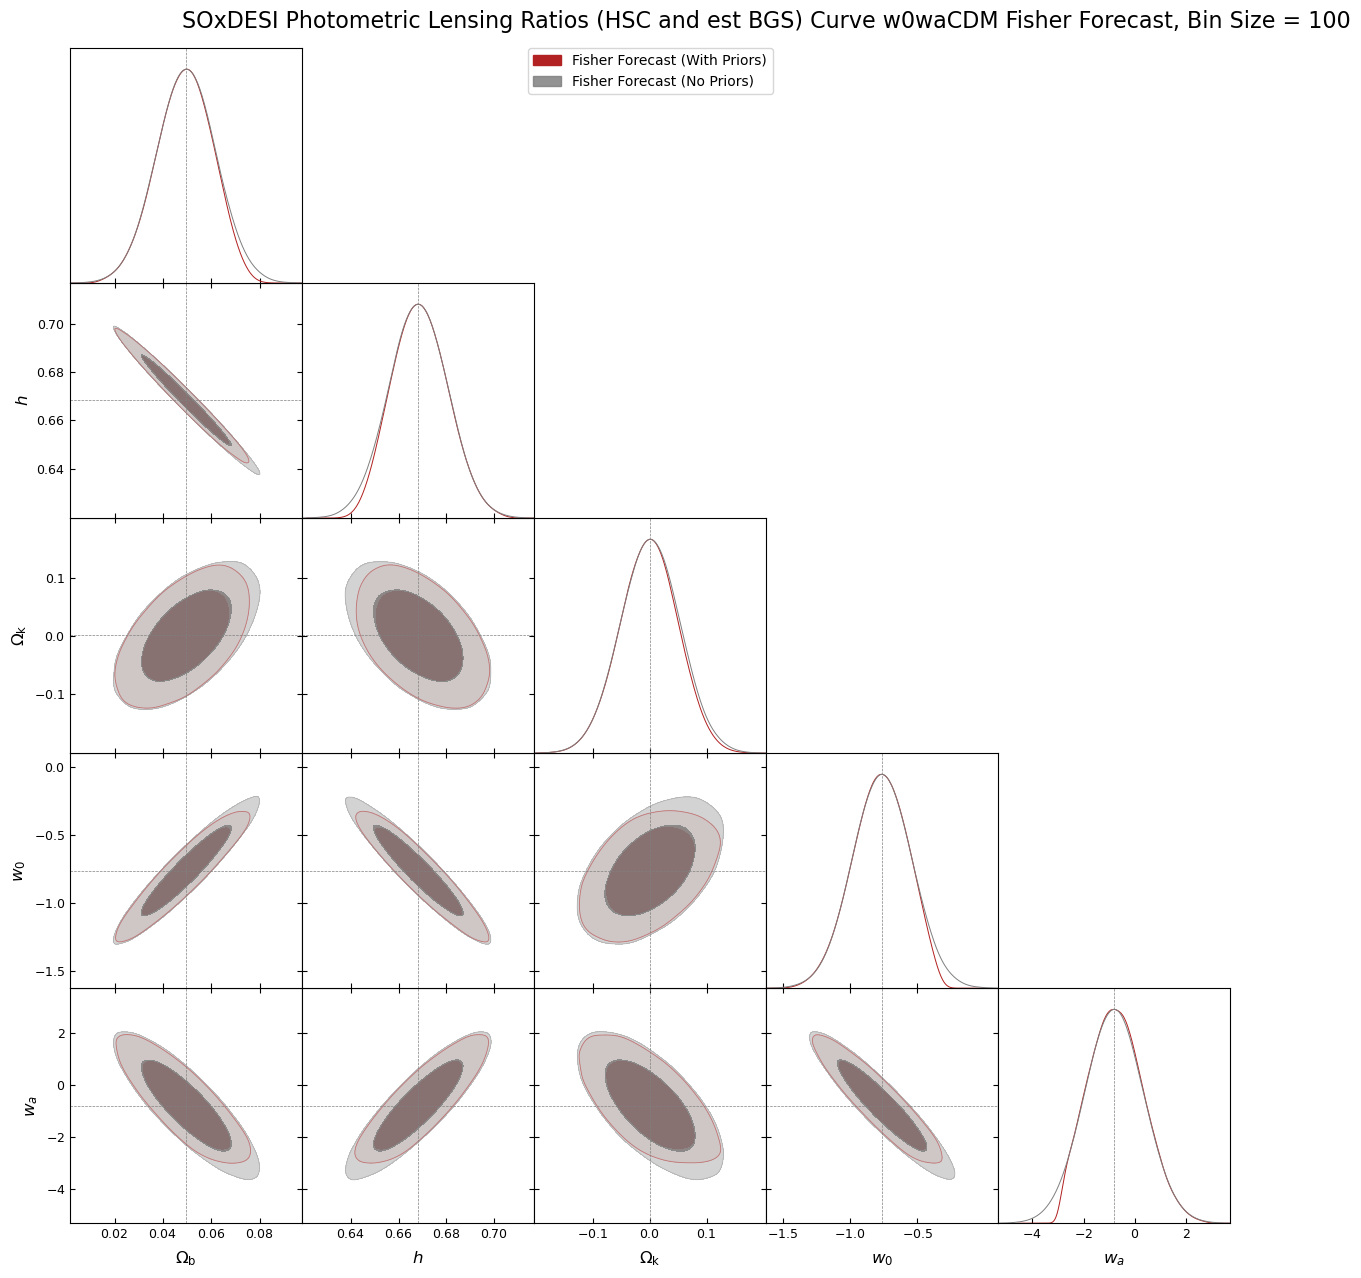

total_time:  0:01:02.034348


In [21]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    matter_power_cosmology=curved_w0waCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios Plus Primaries

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04974\pm 0.00028$ | $\Omega_{b} = 0.04974^{+0.00055}_{-0.00055}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04974\pm 0.00028$ | $\Omega_{b} = 0.04974^{+0.00055}_{-0.00055}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6682\pm 0.0014$ | $h = 0.6682^{+0.0027}_{-0.0027}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6682\pm 0.0014$ | $h = 0.6682^{+0.0027}_{-0.0027}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.055$ | $w_0 = -0.76^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.055$ | $w_0 = -0.76^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.81\pm 0.25$ | $w_a = -0.81^{+0.49}_{-0.49}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.25$ | $w_a = -0.81^{+0.49}_{-0.49}$ |
| --- | --- | --- | --- |

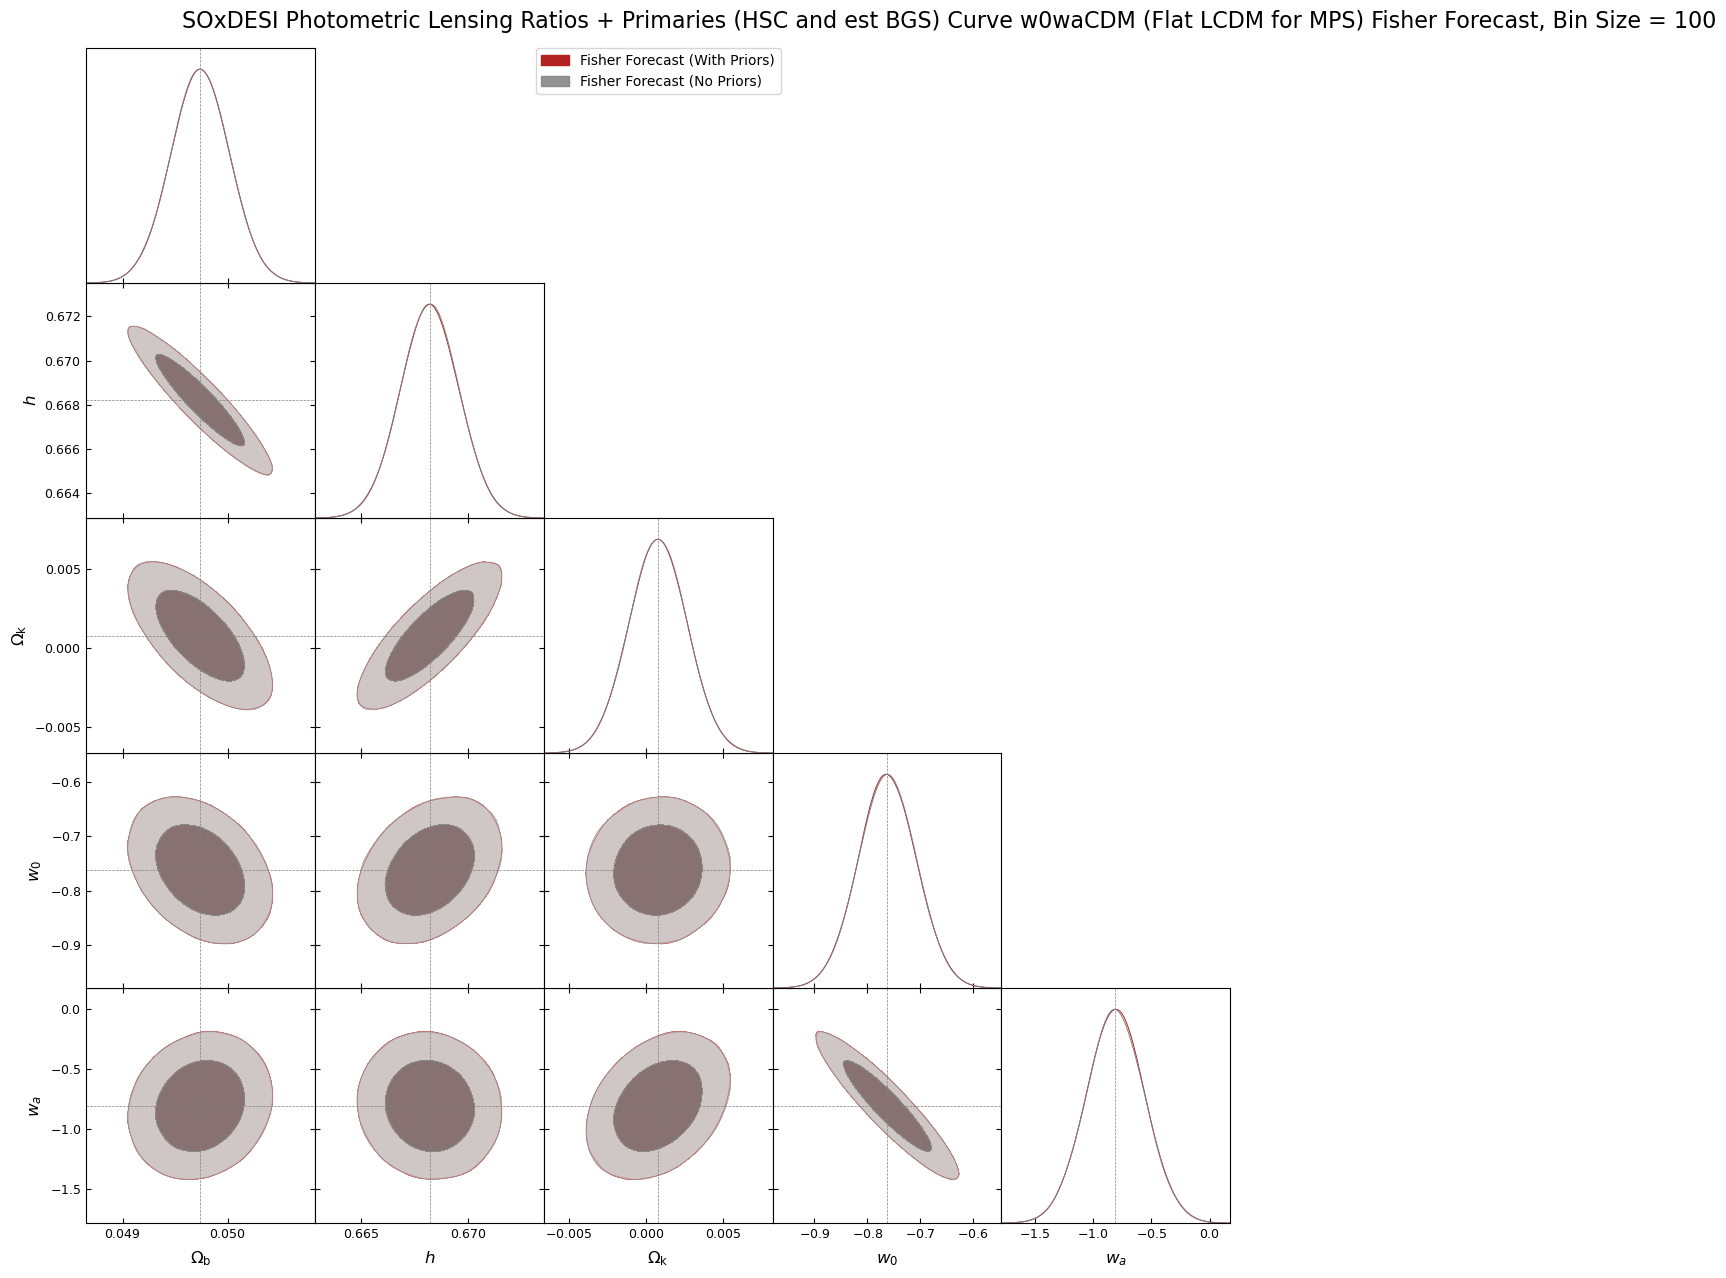

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04974\pm 0.00028$ | $\Omega_{b} = 0.04974^{+0.00055}_{-0.00055}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04974\pm 0.00028$ | $\Omega_{b} = 0.04974^{+0.00055}_{-0.00055}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6682\pm 0.0014$ | $h = 0.6682^{+0.0027}_{-0.0027}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6682\pm 0.0014$ | $h = 0.6682^{+0.0027}_{-0.0027}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.055$ | $w_0 = -0.76^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.055$ | $w_0 = -0.76^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.81\pm 0.25$ | $w_a = -0.81^{+0.49}_{-0.49}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.25$ | $w_a = -0.81^{+0.49}_{-0.49}$ |
| --- | --- | --- | --- |

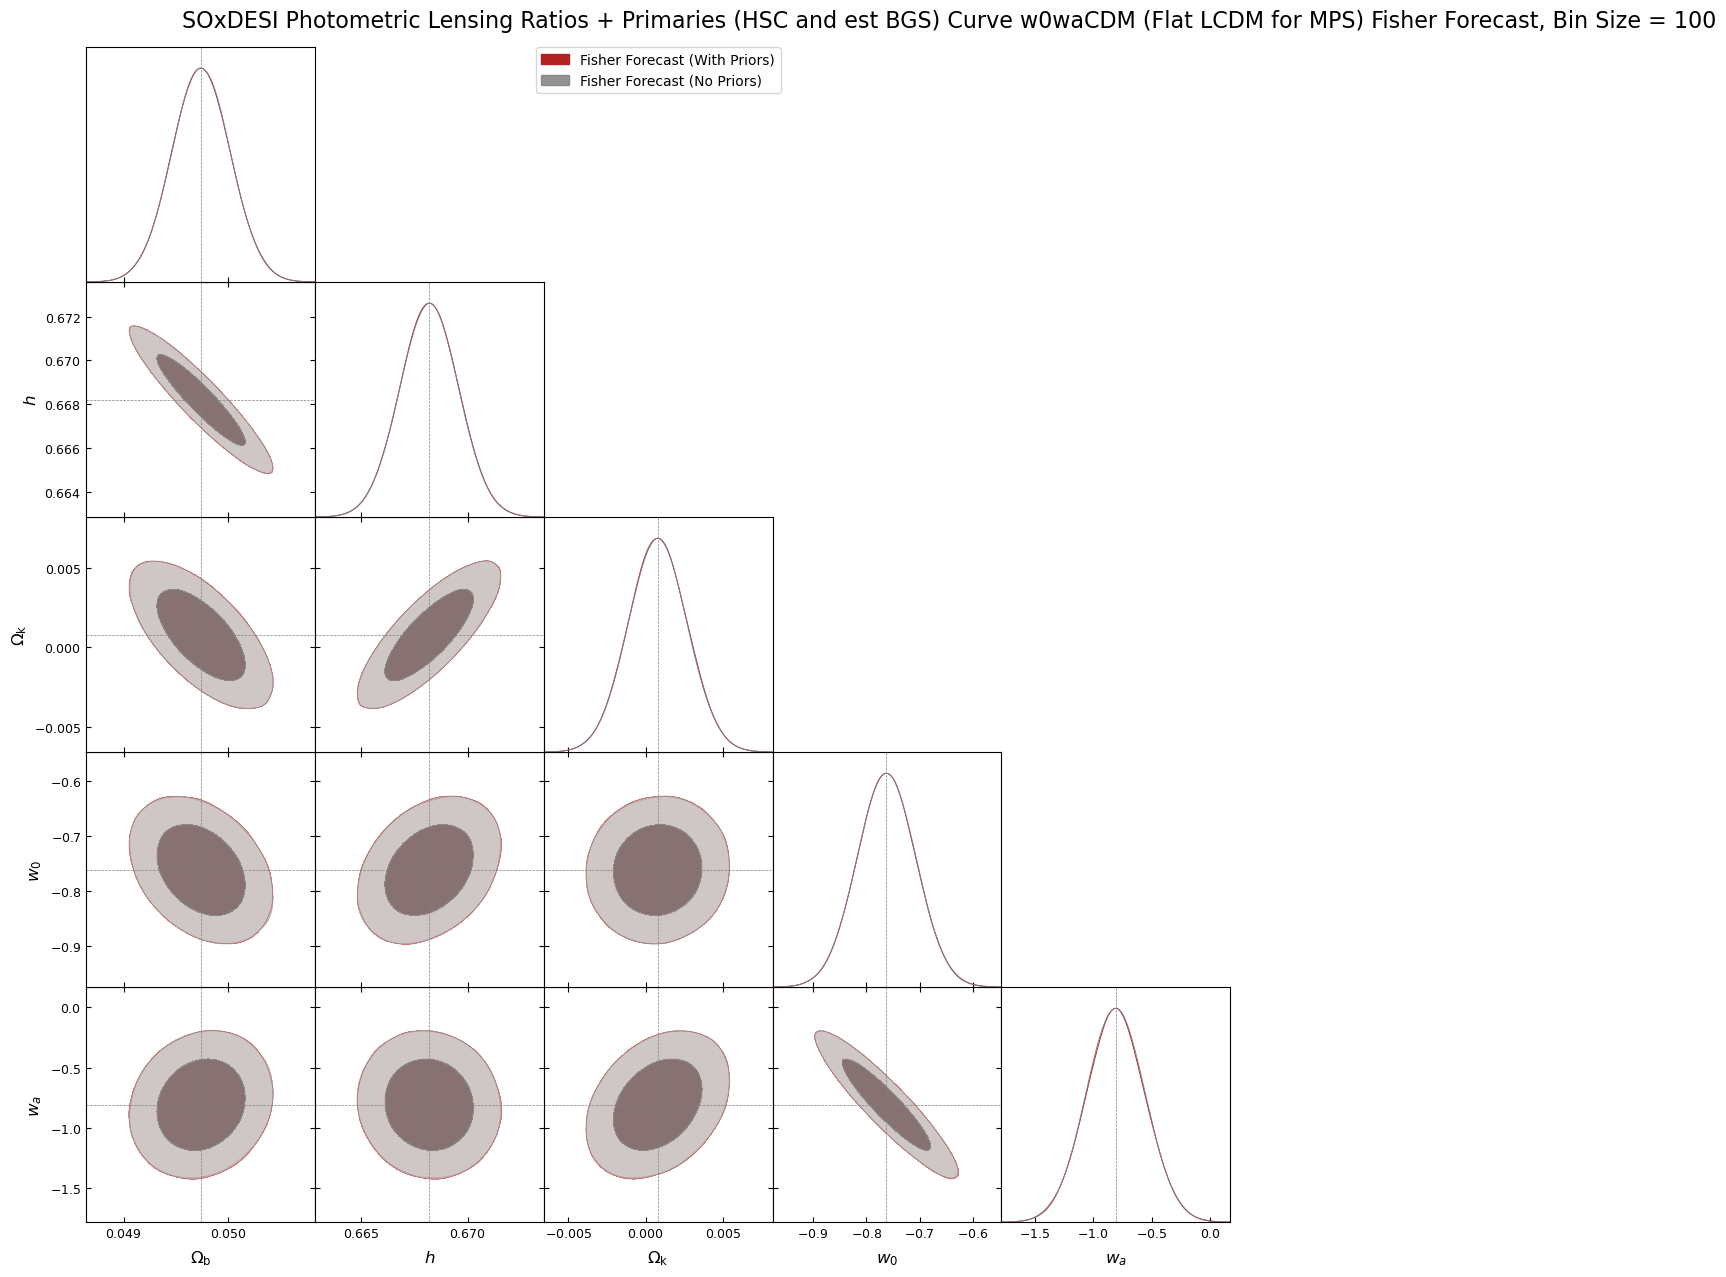

total_time:  0:07:03.148448


In [22]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    matter_power_cosmology=flat_LCDM_cosmology,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM (Flat LCDM for MPS) Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04974\pm 0.00045$ | $\Omega_{b} = 0.04974^{+0.00087}_{-0.00087}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04974\pm 0.00045$ | $\Omega_{b} = 0.04974^{+0.00088}_{-0.00088}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6682\pm 0.0023$ | $h = 0.6682^{+0.0045}_{-0.0045}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6682\pm 0.0023$ | $h = 0.6682^{+0.0045}_{-0.0045}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.041$ | $w_0 = -0.762^{+0.080}_{-0.080}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.041$ | $w_0 = -0.762^{+0.080}_{-0.081}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.81\pm 0.16$ | $w_a = -0.81^{+0.32}_{-0.31}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.16$ | $w_a = -0.81^{+0.32}_{-0.32}$ |
| --- | --- | --- | --- |

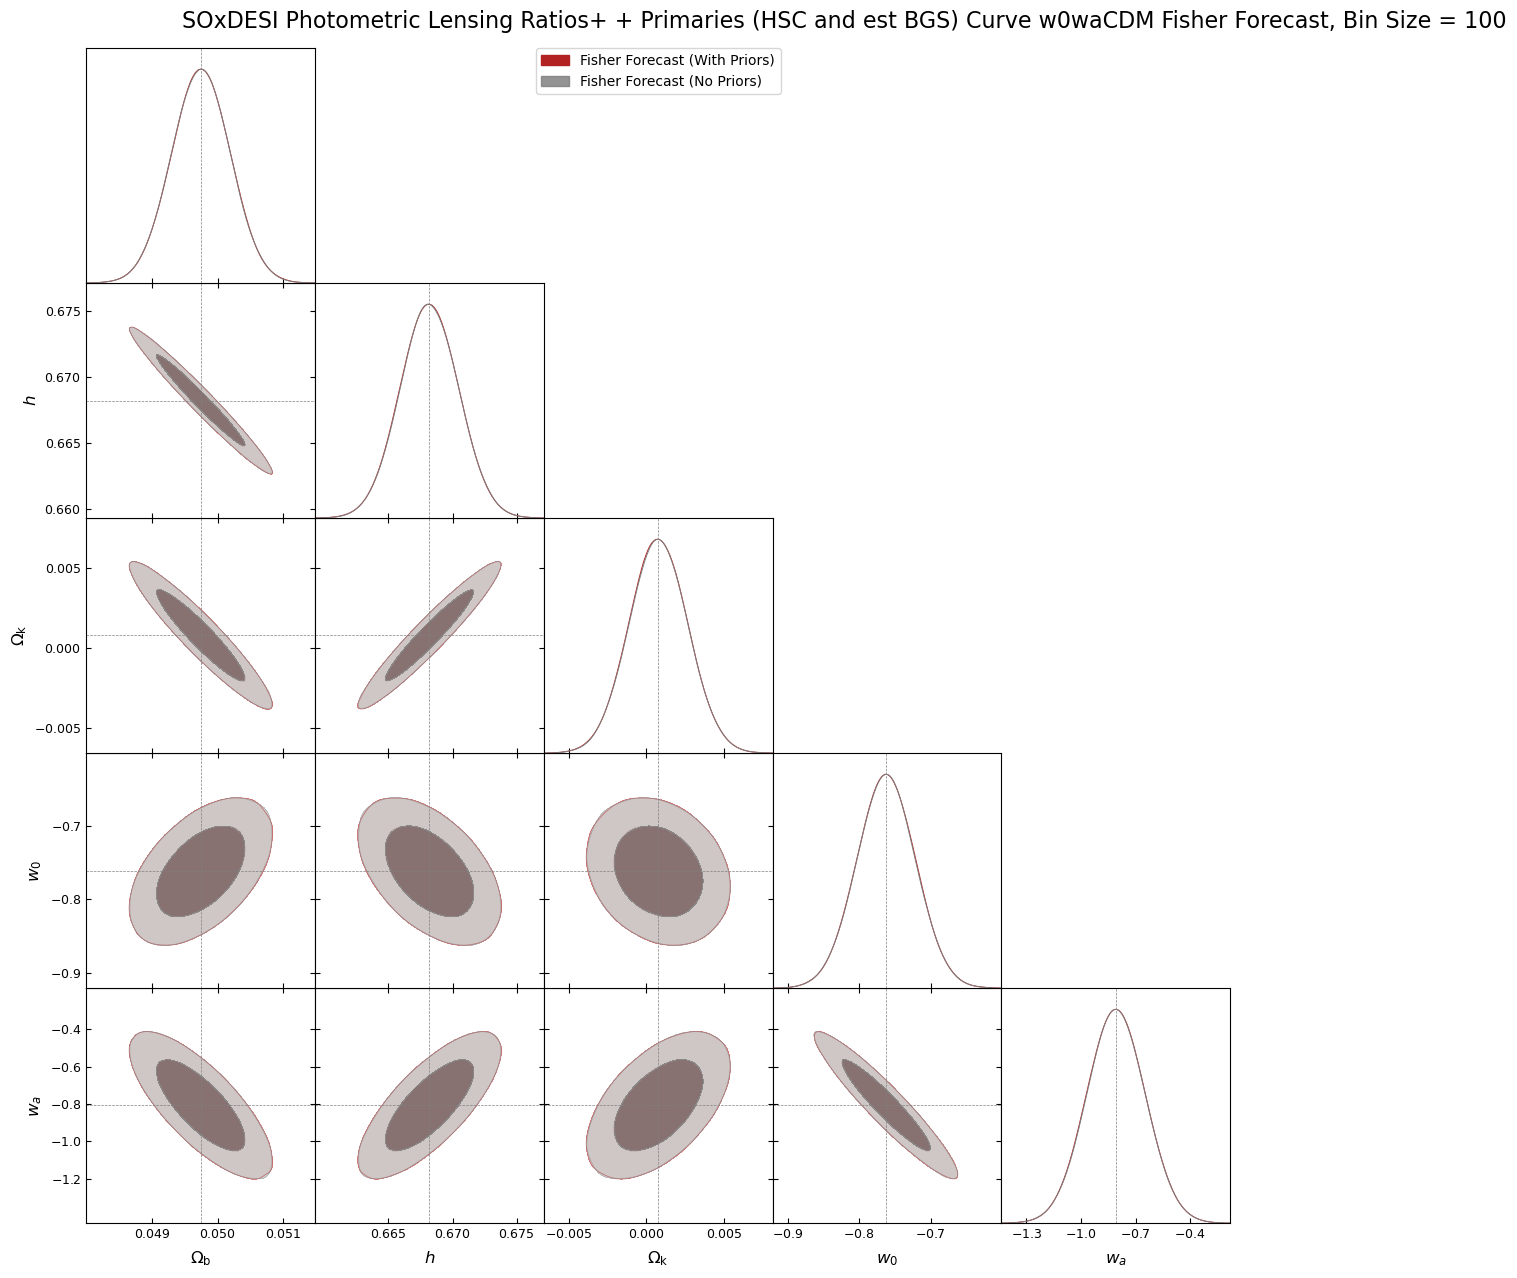

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04974\pm 0.00045$ | $\Omega_{b} = 0.04974^{+0.00087}_{-0.00087}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04974\pm 0.00045$ | $\Omega_{b} = 0.04974^{+0.00087}_{-0.00087}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6682\pm 0.0023$ | $h = 0.6682^{+0.0045}_{-0.0045}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6682\pm 0.0023$ | $h = 0.6682^{+0.0045}_{-0.0044}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0019$ | $\Omega_k = 0.0008^{+0.0037}_{-0.0037}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.762\pm 0.041$ | $w_0 = -0.762^{+0.080}_{-0.080}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.762\pm 0.041$ | $w_0 = -0.762^{+0.080}_{-0.080}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.81\pm 0.16$ | $w_a = -0.81^{+0.31}_{-0.32}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.81\pm 0.16$ | $w_a = -0.81^{+0.32}_{-0.31}$ |
| --- | --- | --- | --- |

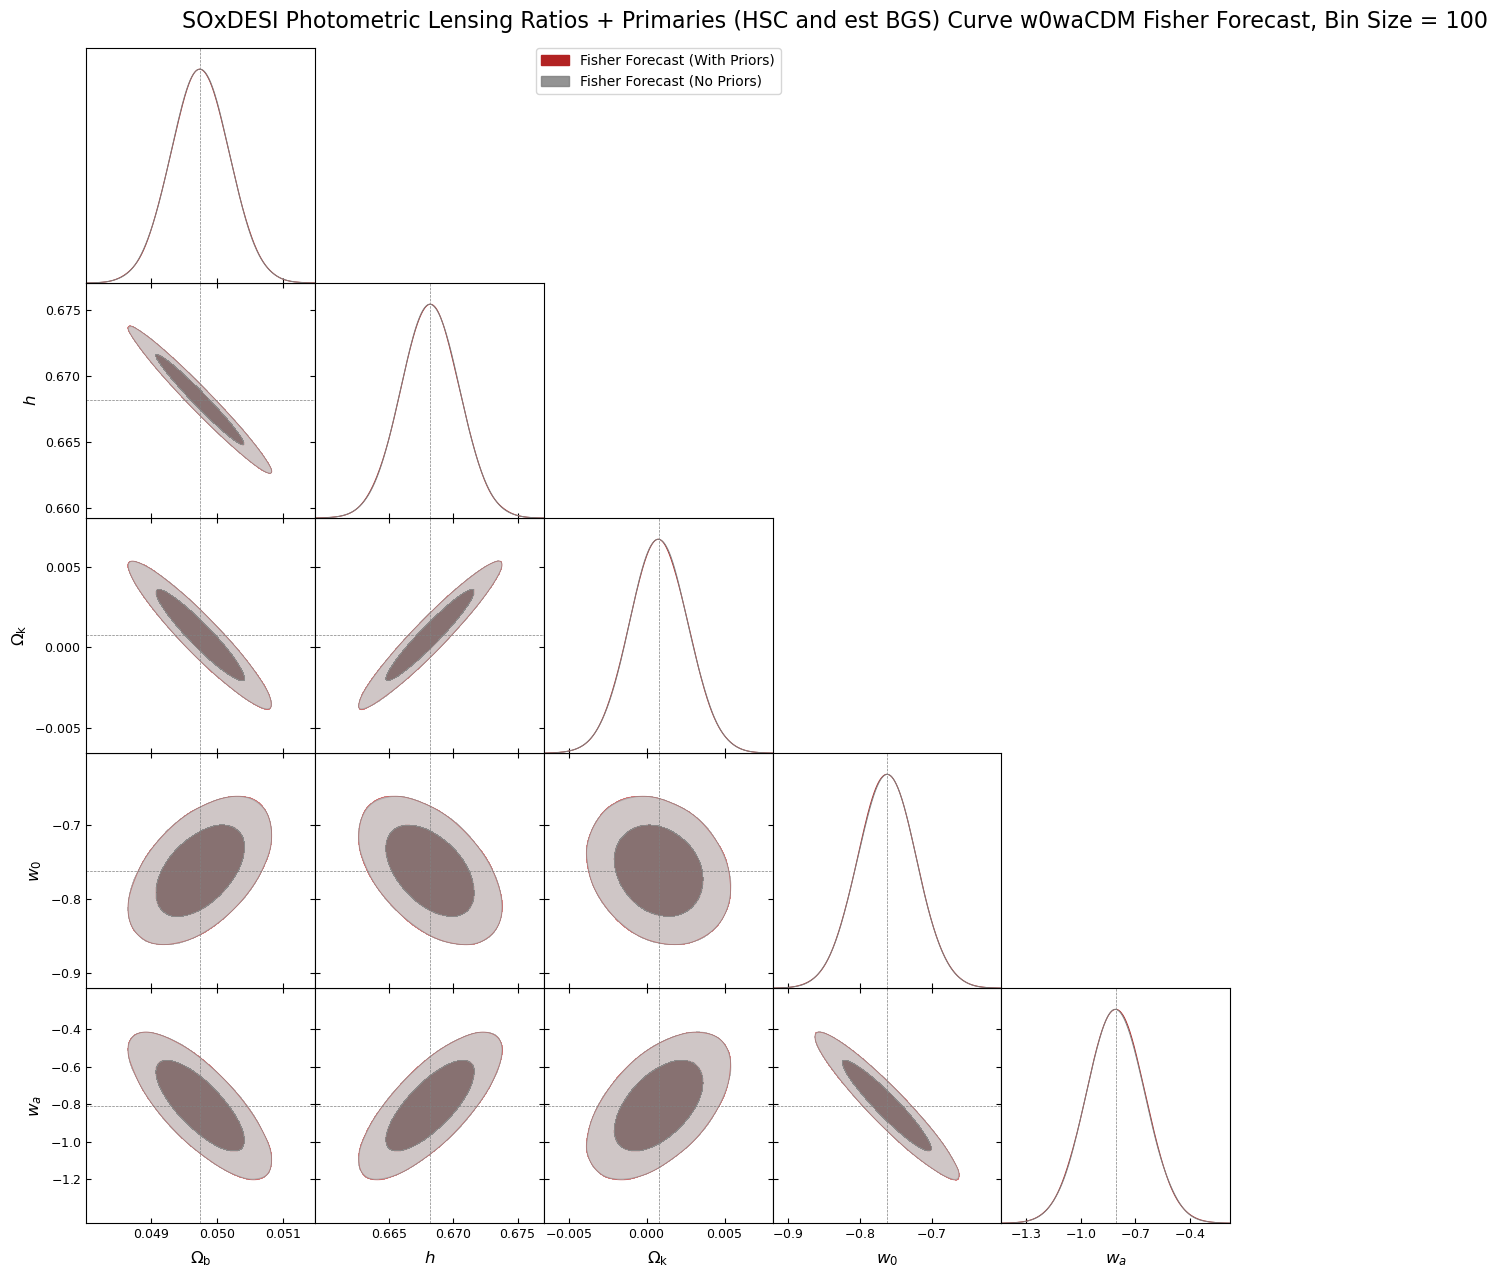

total_time:  0:07:35.981414


In [23]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    matter_power_cosmology=None,
    lens_data=bgs_combined_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
)

# list of all parameters being analyzed
params_to_sample = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_b', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios+ + Primaries (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios + Primaries (HSC and est BGS) Curve w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)